In [ ]:
# ============================================================
# CELL 0 — RAW DATA LOADING + DAILY/WEEKLY PREPROCESSING
# Corrected version
# - Robustly accepts data_pttk.csv or data_pttk*.zip in /content
# - Parses MM/DD/YYYY HH:MM:SS dates correctly
# - Creates daily-category and weekly-category datasets
# - Converts is_holiday into holiday_rate after aggregation
# ============================================================

import os
import glob
import zipfile
import pandas as pd
import numpy as np

CONTENT_DIR = "/content"
RAW_CSV_PATH = os.path.join(CONTENT_DIR, "data_pttk.csv")


def ensure_raw_csv():
    """Find data_pttk.csv or extract the first data_pttk*.zip uploaded to Colab."""
    if os.path.exists(RAW_CSV_PATH):
        return RAW_CSV_PATH

    csv_candidates = sorted(glob.glob(os.path.join(CONTENT_DIR, "data_pttk*.csv")))
    if csv_candidates:
        print(f"[INFO] Using uploaded CSV: {csv_candidates[0]}")
        return csv_candidates[0]

    zip_candidates = sorted(glob.glob(os.path.join(CONTENT_DIR, "data_pttk*.zip")))
    if zip_candidates:
        zip_path = zip_candidates[0]
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(CONTENT_DIR)
        print(f"[INFO] Extracted ZIP: {zip_path}")

        if os.path.exists(RAW_CSV_PATH):
            return RAW_CSV_PATH

        csv_candidates = sorted(glob.glob(os.path.join(CONTENT_DIR, "data_pttk*.csv")))
        if csv_candidates:
            return csv_candidates[0]

    raise FileNotFoundError(
        "Cannot find data_pttk.csv or data_pttk*.zip in /content. "
        "Please upload the raw dataset first."
    )


# 1. LOAD RAW DATA
file_name = ensure_raw_csv()
df = pd.read_csv(file_name)
print(f"[INFO] Raw dataset loaded: {file_name}")
print(f"[INFO] Raw shape: {df.shape}")

# 2. DATE PARSING — dataset uses MM/DD/YYYY HH:MM:SS
# Use strict format first, then fallback to mixed parsing if needed.
df["transaction_date"] = pd.to_datetime(
    df["transaction_date"],
    format="%m/%d/%Y %H:%M:%S",
    errors="coerce"
)

if df["transaction_date"].isna().mean() > 0.01:
    df["transaction_date"] = pd.to_datetime(
        df["transaction_date"],
        format="mixed",
        dayfirst=False,
        errors="coerce"
    )

invalid_dates = int(df["transaction_date"].isna().sum())
if invalid_dates > 0:
    print(f"[WARNING] Dropping {invalid_dates:,} rows with invalid transaction_date.")
    df = df.dropna(subset=["transaction_date"]).copy()

# 3. BASIC TYPE CLEANING
numeric_cols_raw = [
    "quantity", "unit_price", "discount_applied", "product_rating",
    "product_stock", "total_returned_items", "is_holiday"
]
for col in numeric_cols_raw:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Fill missing values after conversion.
df = df.ffill().bfill()

# 4. TEMPORAL FEATURES
# date_only is kept as datetime64 so later .dt operations work correctly.
df["date_only"] = df["transaction_date"].dt.normalize()
df["month"] = df["transaction_date"].dt.month
df["day_of_week"] = df["transaction_date"].dt.dayofweek

# Use weekend derived from the actual calendar, not the simulated raw field.
df["is_weekend_derived"] = df["transaction_date"].dt.dayofweek.isin([5, 6]).astype(int)

# 5. EXPORT CLEANED RAW-LEVEL DATA FOR INVENTORY + RECOMMENDATION
cleaned_path = os.path.join(CONTENT_DIR, "cleaned_retail_data.csv")
df.to_csv(cleaned_path, index=False)

# 6. DAILY-CATEGORY AGGREGATION
# is_holiday becomes holiday_rate after aggregation.
category_daily_sales = df.groupby(["date_only", "product_category"], as_index=False).agg({
    "quantity": "sum",
    "unit_price": "mean",
    "discount_applied": "mean",
    "product_rating": "mean",
    "product_stock": "mean",
    "is_holiday": "mean",
    "is_weekend_derived": "first",
    "month": "first",
    "day_of_week": "first",
    "total_returned_items": "sum"
})

category_daily_sales["holiday_rate"] = category_daily_sales["is_holiday"]
category_daily_sales["is_weekend"] = category_daily_sales["is_weekend_derived"]

# Export both names so later cells remain safe.
category_daily_sales.to_csv(os.path.join(CONTENT_DIR, "category_daily_sales.csv"), index=False)
category_daily_sales.to_csv(os.path.join(CONTENT_DIR, "category_daily_sales_final.csv"), index=False)

# 7. WEEKLY-CATEGORY AGGREGATION — main statistical + forecasting unit
weekly_source = category_daily_sales.copy()
weekly_source["date_only"] = pd.to_datetime(weekly_source["date_only"], errors="coerce")
weekly_source["year_week"] = weekly_source["date_only"].dt.to_period("W").dt.to_timestamp()

category_weekly_sales = weekly_source.groupby(["year_week", "product_category"], as_index=False).agg({
    "quantity": "sum",
    "unit_price": "mean",
    "discount_applied": "mean",
    "product_rating": "mean",
    "product_stock": "mean",
    "is_holiday": "mean",
    "holiday_rate": "mean",
    "is_weekend": "mean",
    "month": "first",
    "day_of_week": "first",
    "total_returned_items": "sum"
}).rename(columns={"is_weekend": "weekend_rate"})

category_weekly_sales.to_csv(os.path.join(CONTENT_DIR, "category_weekly_sales.csv"), index=False)
category_weekly_sales.to_csv(os.path.join(CONTENT_DIR, "category_weekly_sales_final.csv"), index=False)

print("--- PREPROCESSING COMPLETED ---")
print(f"Invalid transaction_date rows after parsing: {invalid_dates:,}")
print(f"Daily-category shape: {category_daily_sales.shape}")
print(f"Weekly-category shape: {category_weekly_sales.shape}")
print("\nDaily-category preview:")
print(category_daily_sales.head())
print("\nWeekly-category preview:")
print(category_weekly_sales.head())

[INFO] Raw dataset loaded: /content/data_pttk.csv
[INFO] Raw shape: (1000000, 92)
--- PREPROCESSING COMPLETED ---
Invalid transaction_date rows after parsing: 0
Daily-category shape: (3655, 14)
Weekly-category shape: (525, 13)

Daily-category preview:
   date_only product_category  quantity  unit_price  discount_applied  \
0 2020-01-01         Clothing      1437  485.100140          0.253719   
1 2020-01-01      Electronics      1396  486.908754          0.241592   
2 2020-01-01        Furniture      1341  532.974291          0.248582   
3 2020-01-01        Groceries      1375  511.510448          0.253134   
4 2020-01-01             Toys      1382  510.819504          0.262128   

   product_rating  product_stock  is_holiday  is_weekend_derived  month  \
0        2.985965      47.561404    0.491228                   0      1   
1        2.910035      49.685121    0.477509                   0      1   
2        3.000373      50.026119    0.574627                   0      1   
3        

Model Features Outlier Statistics:
             Feature  Total Outliers  Percentage (%)  Lower Bound  Upper Bound   Min Value   Max Value
            quantity              22            0.60      1115.50      1623.50 1076.000000 1705.000000
          unit_price              19            0.52       453.30       546.93  431.614234  565.218053
    discount_applied              37            1.01         0.23         0.27    0.215600    0.282428
      product_rating              29            0.79         2.81         3.19    2.726000    3.243774
       product_stock              23            0.63        44.66        54.38   43.748092   56.168000
          is_holiday              33            0.90         0.42         0.58    0.376426    0.605578
  is_weekend_derived               0            0.00        -1.50         2.50    0.000000    1.000000
total_returned_items              25            0.68       987.50      1471.50  959.000000 1588.000000


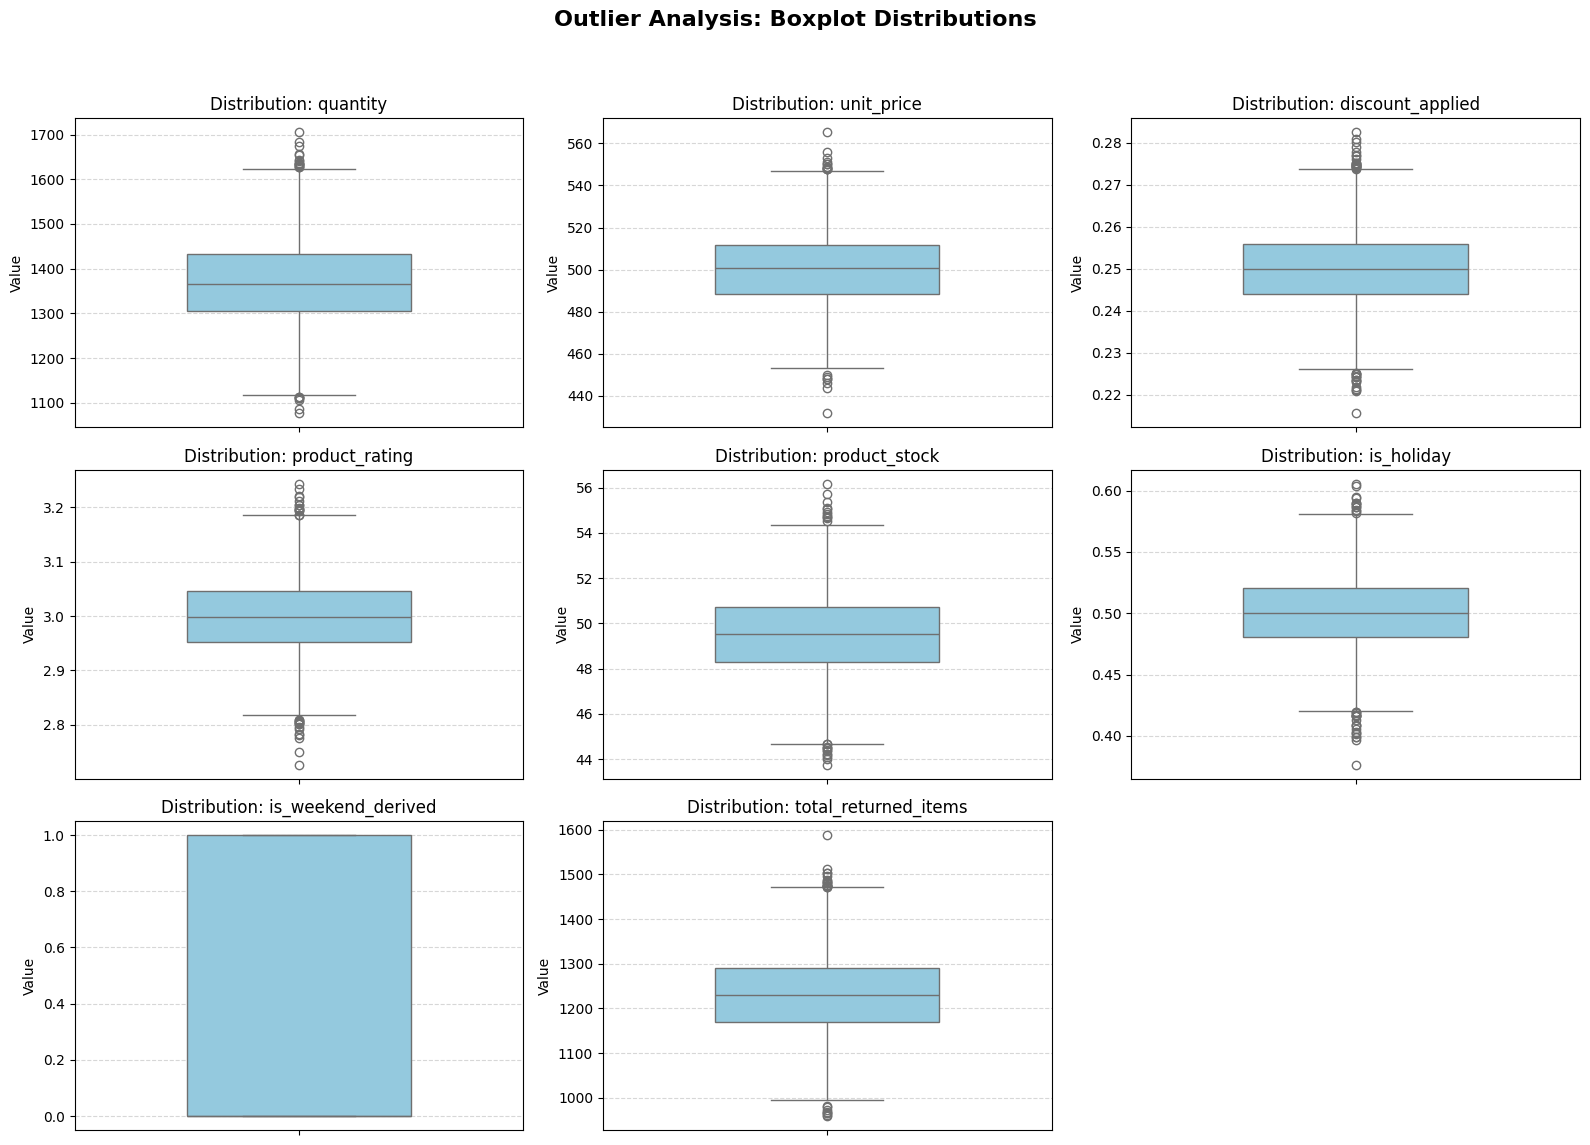

In [ ]:
# Import pandas to read files, process tabular data, and export CSV results.
import pandas as pd
# Import Seaborn to create clear and readable statistical charts.
import seaborn as sns
# Import Matplotlib to create charts for EDA and reporting.
import matplotlib.pyplot as plt

# 1. Load the processed dataset
# Ensure the file path is correct for your environment
# Read the CSV file into a DataFrame to start data processing.
df_model = pd.read_csv('/content/category_daily_sales.csv')

# 2. Define the features for outlier analysis
# Assign the calculated result to a variable for use in later steps.
features_to_check = [
    'quantity', 'unit_price', 'discount_applied', 'product_rating',
    'product_stock', 'is_holiday', 'is_weekend_derived', 'total_returned_items'
]

# 3. Calculate Outlier Statistics using the IQR (Interquartile Range) Method
# Assign the calculated result to a variable for use in later steps.
outlier_summary = []

# Loop through each item, category, or week for step-by-step processing or forecasting.
for col in features_to_check:
    # Assign the calculated result to a variable for use in later steps.
    q1 = df_model[col].quantile(0.25)
    # Assign the calculated result to a variable for use in later steps.
    q3 = df_model[col].quantile(0.75)
    # Assign the calculated result to a variable for use in later steps.
    iqr = q3 - q1

    # Assign the calculated result to a variable for use in later steps.
    lower_bound = q1 - 1.5 * iqr
    # Assign the calculated result to a variable for use in later steps.
    upper_bound = q3 + 1.5 * iqr

    # Identify outliers
    # Assign the calculated result to a variable for use in later steps.
    outliers = df_model[(df_model[col] < lower_bound) | (df_model[col] > upper_bound)]

    # Append a new result to the list for aggregation after the loop.
    outlier_summary.append({
        'Feature': col,
        'Total Outliers': len(outliers),
        'Percentage (%)': round(len(outliers) / len(df_model) * 100, 2),
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2),
        'Min Value': df_model[col].min(),
        'Max Value': df_model[col].max()
    })

# Display summary table
# Create a new DataFrame to store intermediate results or output tables.
summary_df = pd.DataFrame(outlier_summary)
# Print information to monitor progress and verify the result.
print("Model Features Outlier Statistics:")
# Print information to monitor progress and verify the result.
print(summary_df.to_string(index=False))

# 4. Data Visualization with Boxplots
# Configure or draw a chart to visualize the data or model results.
plt.figure(figsize=(16, 12))
# Configure or draw a chart to visualize the data or model results.
plt.suptitle('Outlier Analysis: Boxplot Distributions', fontsize=16, fontweight='bold')

# Loop through each item, category, or week for step-by-step processing or forecasting.
for i, col in enumerate(features_to_check):
    # Configure or draw a chart to visualize the data or model results.
    plt.subplot(3, 3, i + 1)
    # Configure or draw a chart to visualize the data or model results.
    sns.boxplot(y=df_model[col], color='skyblue', width=0.5)
    # Configure or draw a chart to visualize the data or model results.
    plt.title(f'Distribution: {col}', fontsize=12)
    # Configure or draw a chart to visualize the data or model results.
    plt.ylabel('Value')
    # Configure or draw a chart to visualize the data or model results.
    plt.grid(axis='y', linestyle='--', alpha=0.5)

# Configure or draw a chart to visualize the data or model results.
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# Display the chart in the notebook for visual inspection.
plt.show()

In [ ]:
# Import pandas to read files, process tabular data, and export CSV results.
import pandas as pd
# Import NumPy for numerical operations, arrays, and metrics.
import numpy as np

# ============================================================
# PREPROCESSING - REPORT-SAFE VERSION
# ============================================================
# Key correction:
# - Keep 'quantity' in ORIGINAL units because it is the forecasting target.
# - Do NOT MinMax-scale the target before SARIMAX/LightGBM/Hybrid.
# - Model-specific scalers are fitted later using TRAIN data only.

# Assign the calculated result to a variable for use in later steps.
file_path = '/content/category_daily_sales.csv'
# Read the CSV file into a DataFrame to start data processing.
df_model = pd.read_csv(file_path)

# Define constants or configuration values used multiple times in this cell.
TARGET_COL = 'quantity'

# Continuous columns where extreme values can be capped.
# quantity is clipped for extreme outlier control but NOT scaled.
# Assign the calculated result to a variable for use in later steps.
features_to_clip = [
    'quantity', 'unit_price', 'discount_applied', 'product_rating',
    'product_stock', 'total_returned_items'
]

# Print information to monitor progress and verify the result.
print("--- STARTING DATA PREPROCESSING (NO TARGET SCALING) ---")

# 1. Basic data validation
# Assign the calculated result to a variable for use in later steps.
required_cols = ['date_only', 'product_category', TARGET_COL]
# Assign the calculated result to a variable for use in later steps.
missing_required = [c for c in required_cols if c not in df_model.columns]
# Check a condition to choose the appropriate processing branch.
if missing_required:
    # Stop execution and raise a clear error to avoid using incorrect results.
    raise ValueError(f"Missing required columns: {missing_required}")

# Convert the date column to datetime so week, month, and year can be extracted correctly.
df_model['date_only'] = pd.to_datetime(df_model['date_only'], errors='coerce')

# 2. Missing value handling
# Sort the data, which is especially important for preserving chronological order.
df_model = df_model.sort_values(['product_category', 'date_only'])
# Assign the calculated result to a variable for use in later steps.
df_model = df_model.ffill().bfill()

# 3. Outlier handling via IQR clipping
# Assign the calculated result to a variable for use in later steps.
clip_summary = []

# Loop through each item, category, or week for step-by-step processing or forecasting.
for col in features_to_clip:
    # Check a condition to choose the appropriate processing branch.
    if col not in df_model.columns:
        # Print information to monitor progress and verify the result.
        print(f"Warning: Column '{col}' not found. Skipped.")
        continue

    # Assign the calculated result to a variable for use in later steps.
    q1 = df_model[col].quantile(0.25)
    # Assign the calculated result to a variable for use in later steps.
    q3 = df_model[col].quantile(0.75)
    # Assign the calculated result to a variable for use in later steps.
    iqr = q3 - q1

    # Assign the calculated result to a variable for use in later steps.
    lower_bound = q1 - 1.5 * iqr
    # Assign the calculated result to a variable for use in later steps.
    upper_bound = q3 + 1.5 * iqr

    # Assign the calculated result to a variable for use in later steps.
    before_outliers = ((df_model[col] < lower_bound) | (df_model[col] > upper_bound)).sum()
    # Create or update a DataFrame column for feature engineering or modeling.
    df_model[col] = df_model[col].clip(lower_bound, upper_bound)

    # Append a new result to the list for aggregation after the loop.
    clip_summary.append({
        'Feature': col,
        'Lower_Bound': round(lower_bound, 4),
        'Upper_Bound': round(upper_bound, 4),
        'Clipped_Values': int(before_outliers)
    })

# Print information to monitor progress and verify the result.
print("1. Missing values handled with forward/backward fill.")
# Print information to monitor progress and verify the result.
print("2. IQR outlier clipping completed.")
# Print information to monitor progress and verify the result.
print("3. Target 'quantity' is kept in original demand units.")

# Create a new DataFrame to store intermediate results or output tables.
clip_summary_df = pd.DataFrame(clip_summary)
# Print information to monitor progress and verify the result.
print("\n[CLIPPING SUMMARY]")
# Print information to monitor progress and verify the result.
print(clip_summary_df.to_string(index=False))

# 4. Export processed but unscaled dataset
# Assign the calculated result to a variable for use in later steps.
output_file = '/content/category_daily_sales_final.csv'
# Export the result table to a CSV file for the report, inventory, or recommendation module.
df_model.to_csv(output_file, index=False)

# 5. Create the weekly-category dataset used by statistical analysis and forecasting
weekly_model = df_model.copy()
weekly_model['date_only'] = pd.to_datetime(weekly_model['date_only'], errors='coerce')
weekly_model = weekly_model.dropna(subset=['date_only']).copy()
weekly_model['year_week'] = weekly_model['date_only'].dt.to_period('W').dt.to_timestamp()

if 'holiday_rate' not in weekly_model.columns and 'is_holiday' in weekly_model.columns:
    weekly_model['holiday_rate'] = weekly_model['is_holiday']
if 'is_weekend' not in weekly_model.columns and 'is_weekend_derived' in weekly_model.columns:
    weekly_model['is_weekend'] = weekly_model['is_weekend_derived']

weekly_agg_dict = {
    'quantity': 'sum',
    'unit_price': 'mean',
    'discount_applied': 'mean',
    'product_rating': 'mean',
    'product_stock': 'mean',
    'is_holiday': 'mean',
    'holiday_rate': 'mean',
    'is_weekend': 'mean',
    'month': 'first',
    'day_of_week': 'first',
    'total_returned_items': 'sum'
}
weekly_agg_dict = {k: v for k, v in weekly_agg_dict.items() if k in weekly_model.columns}

category_weekly_sales_final = (
    weekly_model
    .groupby(['year_week', 'product_category'], as_index=False)
    .agg(weekly_agg_dict)
    .rename(columns={'is_weekend': 'weekend_rate'})
    .sort_values(['year_week', 'product_category'])
)

category_weekly_sales_final.to_csv('/content/category_weekly_sales_final.csv', index=False)

# Print information to monitor progress and verify the result.
print("-" * 60)
# Print information to monitor progress and verify the result.
print("--- PREPROCESSING SUCCESSFUL ---")
# Print information to monitor progress and verify the result.
print(f"Daily dataset saved to: {output_file}")
print("Weekly dataset saved to: /content/category_weekly_sales_final.csv")
# Print information to monitor progress and verify the result.
print(f"Rows: {len(df_model):,} | Columns: {len(df_model.columns)}")
# Print information to monitor progress and verify the result.
print("-" * 60)

# Print information to monitor progress and verify the result.
print("\n[NUMERIC RANGE CHECK AFTER PREPROCESSING]")
# Assign the calculated result to a variable for use in later steps.
numeric_cols = [c for c in features_to_clip if c in df_model.columns]
# Aggregate data by group using operations such as sum, mean, or standard deviation.
print(df_model[numeric_cols].agg(['min', 'max', 'mean']).transpose().round(4))

--- STARTING DATA PREPROCESSING (NO TARGET SCALING) ---
1. Missing values handled with forward/backward fill.
2. IQR outlier clipping completed.
3. Target 'quantity' is kept in original demand units.

[CLIPPING SUMMARY]
             Feature  Lower_Bound  Upper_Bound  Clipped_Values
            quantity    1115.5000    1623.5000              22
          unit_price     453.3015     546.9282              19
    discount_applied       0.2260       0.2738              37
      product_rating       2.8114       3.1856              29
       product_stock      44.6628      54.3762              23
total_returned_items     987.5000    1471.5000              25
------------------------------------------------------------
--- PREPROCESSING SUCCESSFUL ---
Daily dataset saved to: /content/category_daily_sales_final.csv
Weekly dataset saved to: /content/category_weekly_sales_final.csv
Rows: 3,655 | Columns: 14
------------------------------------------------------------

[NUMERIC RANGE CHECK AFTER 

In [ ]:
# ============================================================
# STATISTICAL ANALYSIS — WEEKLY-CATEGORY DATASET
# Corrected version
# Why weekly-category?
# - Forecasting models predict weekly demand by product category.
# - Therefore, descriptive statistics, correlation, chi-square, ANOVA, and OLS
#   should use the same analytical unit as the forecasting models.
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, f_oneway
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# =========================
# LOAD WEEKLY-CATEGORY DATA
# =========================
try:
    df_stat = pd.read_csv('/content/category_weekly_sales_final.csv')
except FileNotFoundError:
    # Fallback: build weekly data from daily data if Cell 2 was not run.
    daily = pd.read_csv('/content/category_daily_sales_final.csv')
    daily['date_only'] = pd.to_datetime(daily['date_only'], errors='coerce')
    daily['year_week'] = daily['date_only'].dt.to_period('W').dt.to_timestamp()
    if 'holiday_rate' not in daily.columns:
        daily['holiday_rate'] = daily['is_holiday']
    if 'is_weekend' not in daily.columns and 'is_weekend_derived' in daily.columns:
        daily['is_weekend'] = daily['is_weekend_derived']
    df_stat = daily.groupby(['year_week', 'product_category'], as_index=False).agg({
        'quantity': 'sum',
        'unit_price': 'mean',
        'discount_applied': 'mean',
        'product_rating': 'mean',
        'product_stock': 'mean',
        'is_holiday': 'mean',
        'holiday_rate': 'mean',
        'is_weekend': 'mean',
        'month': 'first',
        'day_of_week': 'first',
        'total_returned_items': 'sum'
    }).rename(columns={'is_weekend': 'weekend_rate'})
    df_stat.to_csv('/content/category_weekly_sales_final.csv', index=False)

if 'year_week' in df_stat.columns:
    df_stat['year_week'] = pd.to_datetime(df_stat['year_week'], errors='coerce')

if 'holiday_rate' not in df_stat.columns and 'is_holiday' in df_stat.columns:
    df_stat['holiday_rate'] = df_stat['is_holiday']
if 'weekend_rate' not in df_stat.columns:
    if 'is_weekend' in df_stat.columns:
        df_stat['weekend_rate'] = df_stat['is_weekend']
    elif 'is_weekend_derived' in df_stat.columns:
        df_stat['weekend_rate'] = df_stat['is_weekend_derived']

# =========================
# DESCRIPTIVE STATISTICS
# =========================
numeric_cols = [
    'quantity', 'unit_price', 'discount_applied', 'product_rating',
    'product_stock', 'holiday_rate', 'weekend_rate', 'month',
    'day_of_week', 'total_returned_items'
]
numeric_cols = [c for c in numeric_cols if c in df_stat.columns]

# Drop constant columns for correlation/regression safety, but keep them visible in descriptive stats.
desc = df_stat[numeric_cols].describe().T
if {'mean', 'std'}.issubset(desc.columns):
    desc['CV'] = desc['std'] / desc['mean'].replace(0, np.nan)
desc.to_csv('/content/weekly_descriptive_statistics.csv')
print('\n[DESCRIPTIVE STATISTICS — WEEKLY-CATEGORY]')
print(desc.round(4))

# =========================
# CORRELATION ANALYSIS
# =========================
valid_corr_cols = [c for c in numeric_cols if df_stat[c].nunique(dropna=True) > 1]
constant_cols = [c for c in numeric_cols if c not in valid_corr_cols]
if constant_cols:
    print(f"\n[WARNING] Constant columns removed from correlation: {constant_cols}")

corr_matrix = df_stat[valid_corr_cols].corr(method='pearson')
corr_matrix.to_csv('/content/weekly_correlation_matrix.csv')

if 'quantity' in corr_matrix.columns:
    target_corr = corr_matrix['quantity'].sort_values(ascending=False).reset_index()
    target_corr.columns = ['Feature', 'Pearson_r_with_Quantity']
    target_corr.to_csv('/content/weekly_correlation_with_quantity.csv', index=False)
    print('\n[CORRELATION WITH WEEKLY QUANTITY]')
    print(target_corr.round(4))

# =========================
# CHI-SQUARE TESTS
# =========================
chi_results = []
# Demand bins: Low / Medium / High weekly demand.
df_stat['demand_bin'] = pd.qcut(
    df_stat['quantity'],
    q=3,
    labels=['Low', 'Medium', 'High'],
    duplicates='drop'
)

# Product category vs demand level.
if df_stat['demand_bin'].nunique(dropna=True) > 1:
    contingency = pd.crosstab(df_stat['product_category'], df_stat['demand_bin'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    chi_results.append({
        'Test': 'Product Category vs Weekly Demand Bin',
        'Chi2': chi2,
        'p_value': p,
        'dof': dof,
        'Conclusion': 'Significant' if p < 0.05 else 'Not significant'
    })

# Holiday exposure bin vs demand level.
if 'holiday_rate' in df_stat.columns and df_stat['holiday_rate'].nunique(dropna=True) > 1:
    df_stat['holiday_exposure_bin'] = pd.qcut(
        df_stat['holiday_rate'],
        q=2,
        labels=['Low Holiday Exposure', 'High Holiday Exposure'],
        duplicates='drop'
    )
    if df_stat['holiday_exposure_bin'].nunique(dropna=True) > 1:
        contingency = pd.crosstab(df_stat['holiday_exposure_bin'], df_stat['demand_bin'])
        chi2, p, dof, expected = chi2_contingency(contingency)
        chi_results.append({
            'Test': 'Holiday Exposure Bin vs Weekly Demand Bin',
            'Chi2': chi2,
            'p_value': p,
            'dof': dof,
            'Conclusion': 'Significant' if p < 0.05 else 'Not significant'
        })

# Weekend exposure bin vs demand level.
if 'weekend_rate' in df_stat.columns and df_stat['weekend_rate'].nunique(dropna=True) > 1:
    df_stat['weekend_exposure_bin'] = pd.qcut(
        df_stat['weekend_rate'],
        q=2,
        labels=['Low Weekend Exposure', 'High Weekend Exposure'],
        duplicates='drop'
    )
    if df_stat['weekend_exposure_bin'].nunique(dropna=True) > 1:
        contingency = pd.crosstab(df_stat['weekend_exposure_bin'], df_stat['demand_bin'])
        chi2, p, dof, expected = chi2_contingency(contingency)
        chi_results.append({
            'Test': 'Weekend Exposure Bin vs Weekly Demand Bin',
            'Chi2': chi2,
            'p_value': p,
            'dof': dof,
            'Conclusion': 'Significant' if p < 0.05 else 'Not significant'
        })

chi_df = pd.DataFrame(chi_results)
chi_df.to_csv('/content/weekly_chi_square_results.csv', index=False)
print('\n[CHI-SQUARE RESULTS]')
print(chi_df.round(4) if not chi_df.empty else 'No valid chi-square test could be computed.')

# =========================
# ANOVA + TUKEY HSD
# =========================
groups = [
    g['quantity'].dropna().values
    for _, g in df_stat.groupby('product_category')
    if len(g['quantity'].dropna()) > 1
]

anova_records = []
if len(groups) >= 2:
    f_stat, p_val = f_oneway(*groups)
    anova_records.append({
        'Test': 'One-way ANOVA: Weekly Quantity by Product Category',
        'F_statistic': f_stat,
        'p_value': p_val,
        'Conclusion': 'Reject H0' if p_val < 0.05 else 'Fail to reject H0'
    })
    tukey = pairwise_tukeyhsd(
        endog=df_stat['quantity'],
        groups=df_stat['product_category'],
        alpha=0.05
    )
    tukey_df = pd.DataFrame(
        data=tukey._results_table.data[1:],
        columns=tukey._results_table.data[0]
    )
    tukey_df.to_csv('/content/weekly_tukey_hsd_results.csv', index=False)
else:
    tukey_df = pd.DataFrame()

anova_df = pd.DataFrame(anova_records)
anova_df.to_csv('/content/weekly_anova_results.csv', index=False)
print('\n[ANOVA RESULTS]')
print(anova_df.round(4) if not anova_df.empty else 'Not enough groups for ANOVA.')
print('\n[TUKEY HSD RESULTS]')
print(tukey_df.head(20) if not tukey_df.empty else 'Tukey HSD not computed.')

# =========================
# OLS REGRESSION
# =========================
predictor_cols = [
    'unit_price', 'discount_applied', 'product_rating', 'product_stock',
    'holiday_rate', 'weekend_rate', 'total_returned_items'
]
predictor_cols = [c for c in predictor_cols if c in df_stat.columns]
predictor_cols = [c for c in predictor_cols if df_stat[c].nunique(dropna=True) > 1]

ols_data = df_stat[['quantity'] + predictor_cols].dropna().copy()
X = sm.add_constant(ols_data[predictor_cols])
y = ols_data['quantity']
ols_model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 1})

ols_results = pd.DataFrame({
    'Predictor': ols_model.params.index,
    'Coefficient': ols_model.params.values,
    'Std_Error': ols_model.bse.values,
    'T_statistic': ols_model.tvalues.values,
    'p_value': ols_model.pvalues.values
})
ols_results['R_squared'] = ols_model.rsquared
ols_results['Adj_R_squared'] = ols_model.rsquared_adj
ols_results['N'] = int(ols_model.nobs)
ols_results.to_csv('/content/weekly_ols_regression_results.csv', index=False)

print('\n[OLS REGRESSION RESULTS — WEEKLY QUANTITY]')
print(ols_results.round(4))
print('\n[FILES EXPORTED]')
print('- weekly_descriptive_statistics.csv')
print('- weekly_correlation_matrix.csv')
print('- weekly_correlation_with_quantity.csv')
print('- weekly_chi_square_results.csv')
print('- weekly_anova_results.csv')
print('- weekly_tukey_hsd_results.csv')
print('- weekly_ols_regression_results.csv')


[DESCRIPTIVE STATISTICS — WEEKLY-CATEGORY]
                      count       mean       std        min        25%  \
quantity              525.0  9528.3486  438.2102  6531.0000  9388.0000   
unit_price            525.0   500.1975    6.5067   474.5613   495.7306   
discount_applied      525.0     0.2499    0.0034     0.2395     0.2477   
product_rating        525.0     2.9990    0.0267     2.8989     2.9812   
product_stock         525.0    49.5143    0.6825    47.5323    49.0046   
holiday_rate          525.0     0.5003    0.0116     0.4654     0.4925   
weekend_rate          525.0     0.2841    0.0300     0.0000     0.2857   
month                 525.0     6.4762    3.4484     1.0000     3.0000   
day_of_week           525.0     0.0190    0.1944     0.0000     0.0000   
total_returned_items  525.0  8567.5571  393.5022  5848.0000  8448.0000   

                            50%        75%         max       CV  
quantity              9574.0000  9748.0000  10322.0000   0.0460  
unit_pric

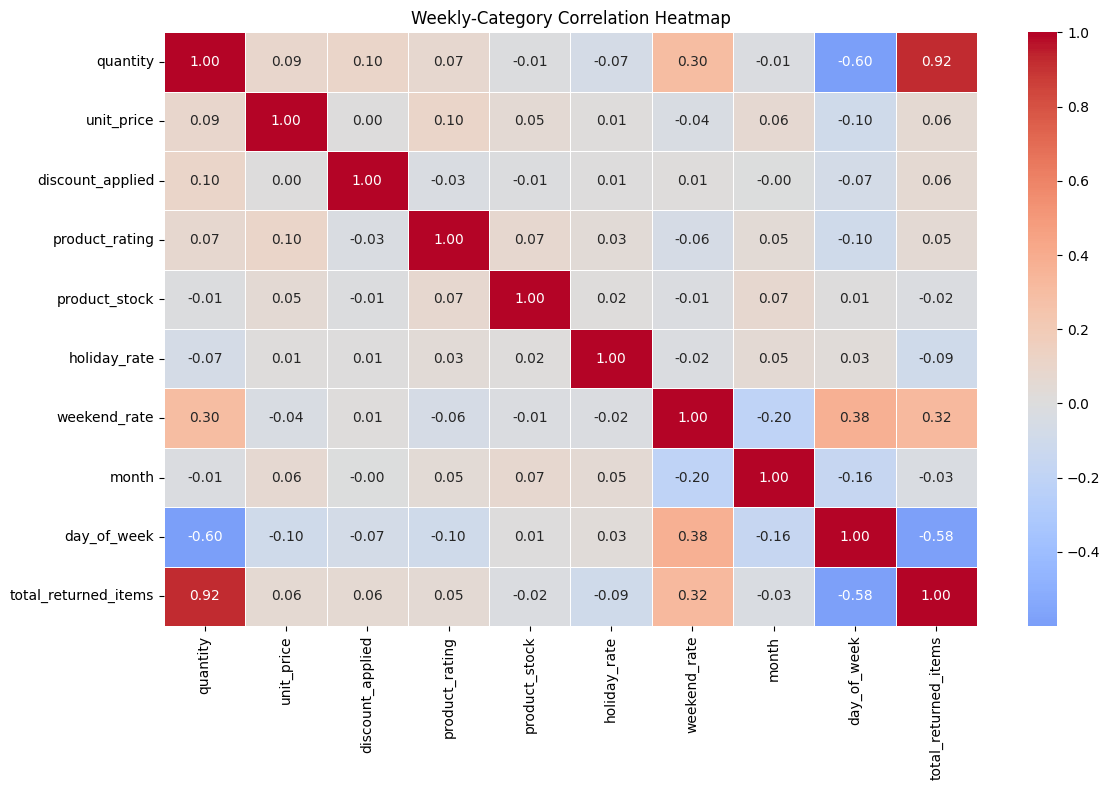

[INFO] Saved: weekly_correlation_matrix.csv and weekly_correlation_heatmap.png


In [ ]:
# ============================================================
# WEEKLY CORRELATION HEATMAP
# Corrected version
# - Uses weekly-category dataset, same unit as forecasting models
# - Uses holiday_rate and weekend_rate instead of ambiguous binary names
# - Removes constant columns before correlation to avoid NaN values
# ============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cat_df = pd.read_csv('/content/category_weekly_sales_final.csv')

if 'holiday_rate' not in cat_df.columns and 'is_holiday' in cat_df.columns:
    cat_df['holiday_rate'] = cat_df['is_holiday']
if 'weekend_rate' not in cat_df.columns:
    if 'is_weekend' in cat_df.columns:
        cat_df['weekend_rate'] = cat_df['is_weekend']
    elif 'is_weekend_derived' in cat_df.columns:
        cat_df['weekend_rate'] = cat_df['is_weekend_derived']

cols = [
    'quantity', 'unit_price', 'discount_applied', 'product_rating',
    'product_stock', 'holiday_rate', 'weekend_rate', 'month',
    'day_of_week', 'total_returned_items'
]
cols = [c for c in cols if c in cat_df.columns]

constant_cols = [c for c in cols if cat_df[c].nunique(dropna=True) <= 1]
if constant_cols:
    print(f"[WARNING] Constant columns removed from correlation heatmap: {constant_cols}")

valid_cols = [c for c in cols if c not in constant_cols]
corr_matrix = cat_df[valid_cols].corr(method='pearson')
corr_matrix.to_csv('/content/weekly_correlation_matrix.csv')

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Weekly-Category Correlation Heatmap')
plt.tight_layout()
plt.savefig('/content/weekly_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print('[INFO] Saved: weekly_correlation_matrix.csv and weekly_correlation_heatmap.png')


========== CATEGORY: CLOTHING ==========
ADF p-value: 0.0000 | differencing order d = 0


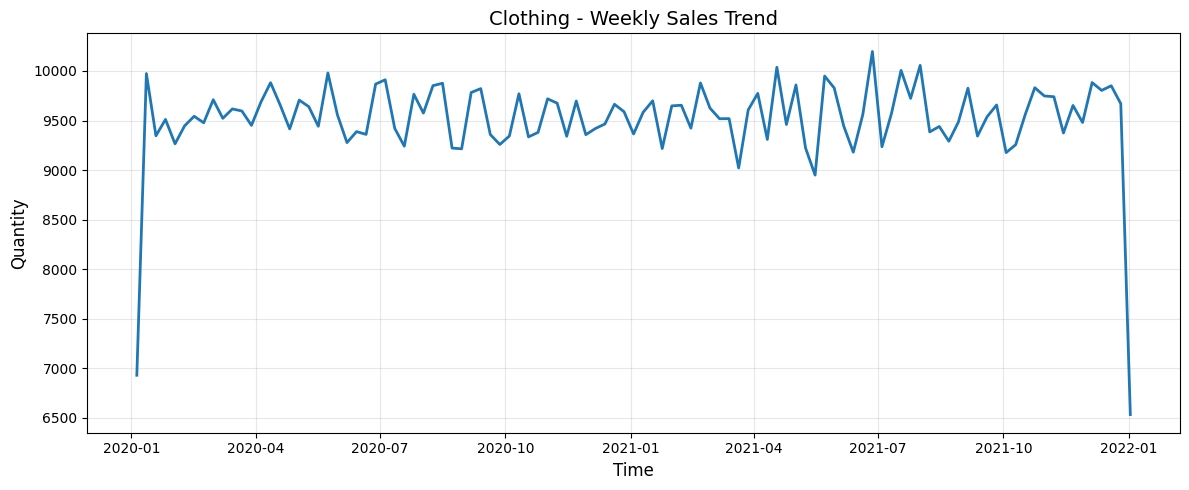

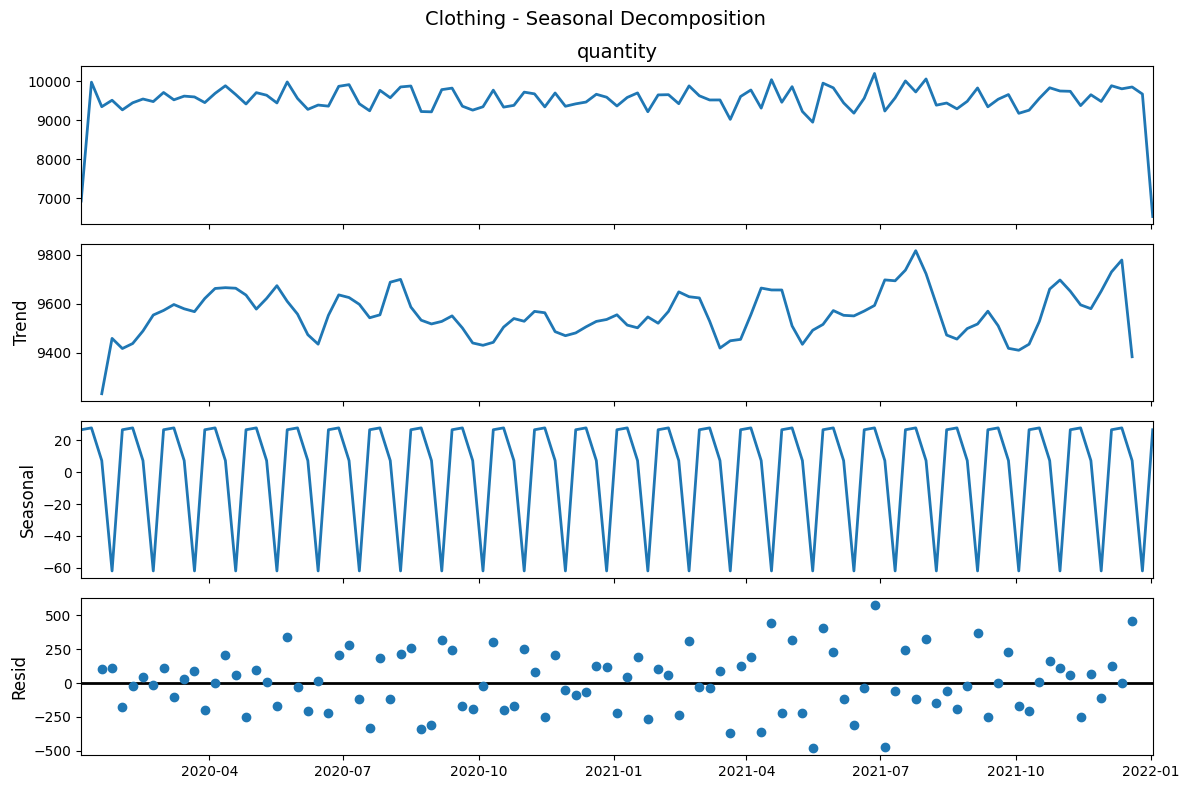

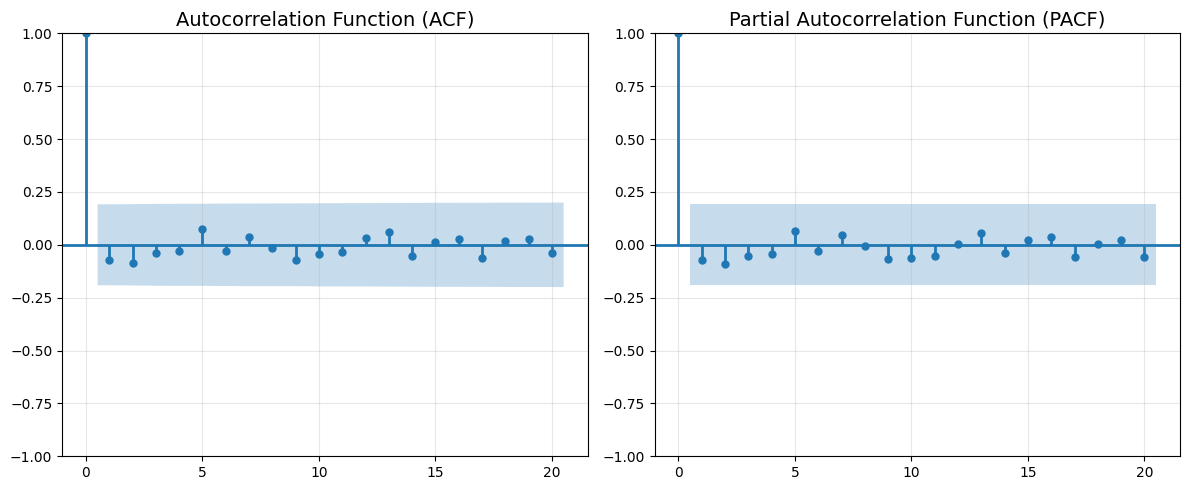


========== CATEGORY: ELECTRONICS ==========
ADF p-value: 0.0000 | differencing order d = 0


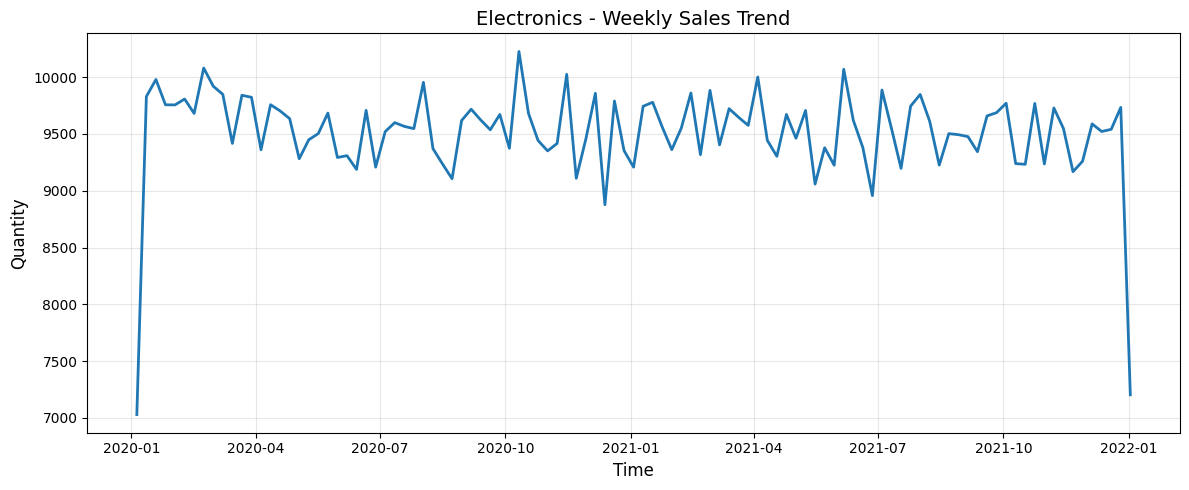

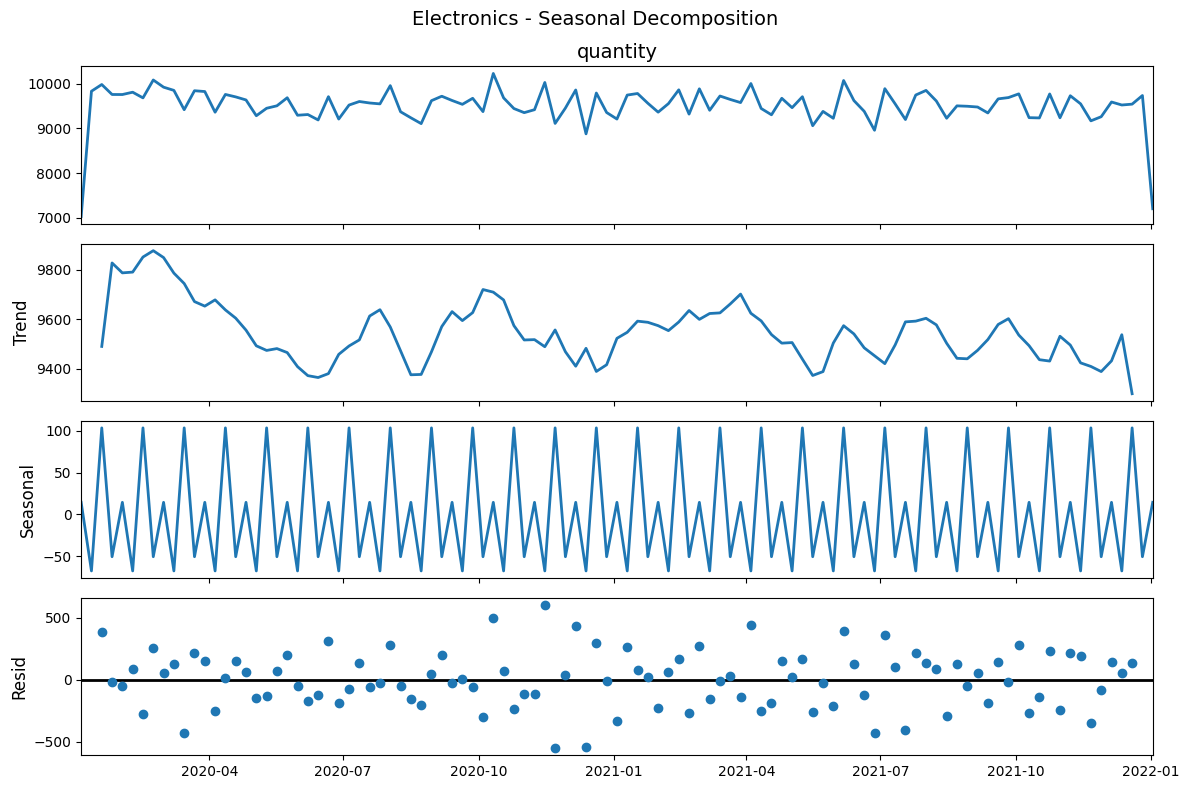

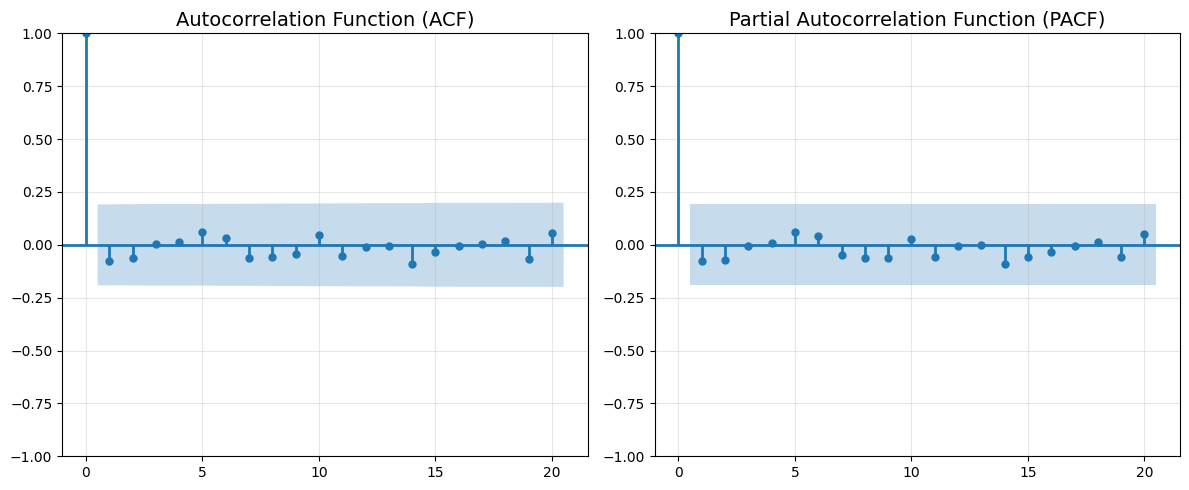


========== CATEGORY: FURNITURE ==========
ADF p-value: 0.0000 | differencing order d = 0


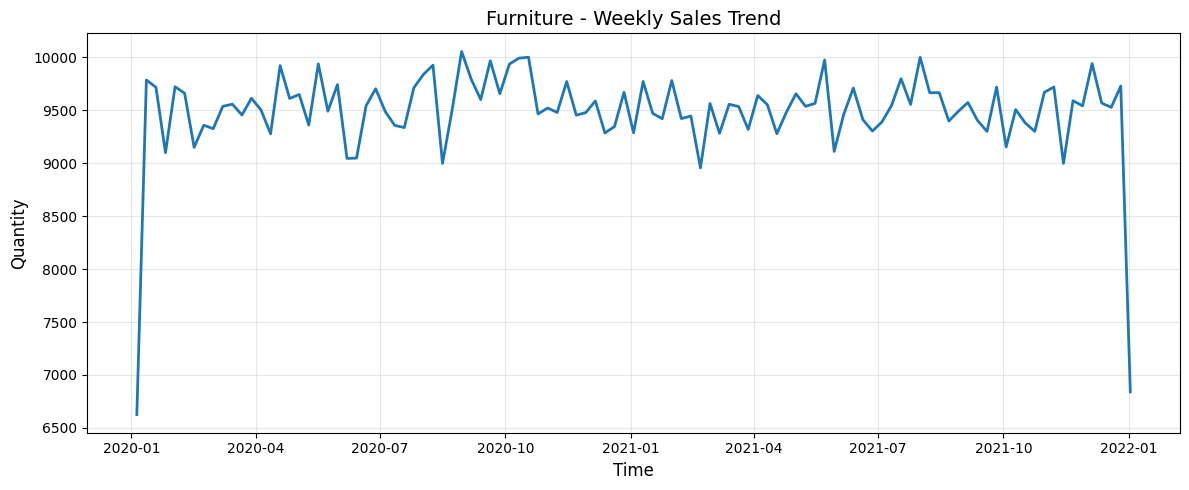

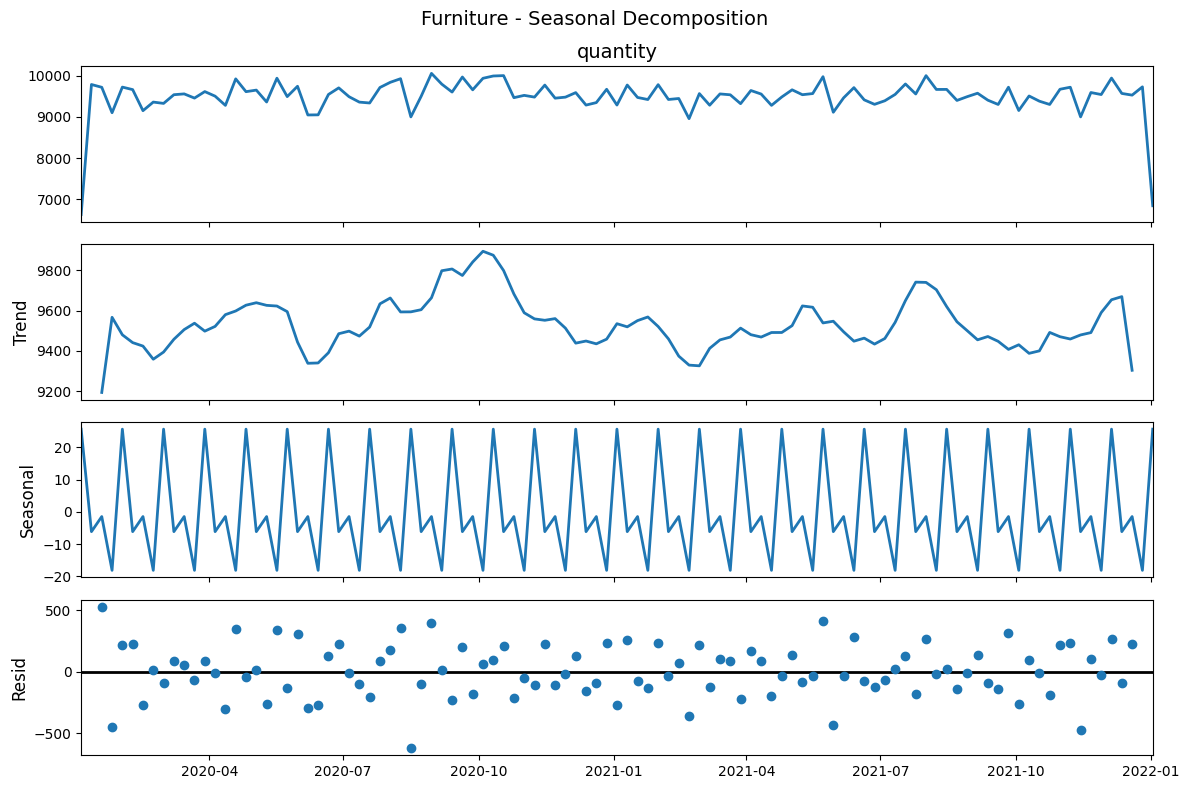

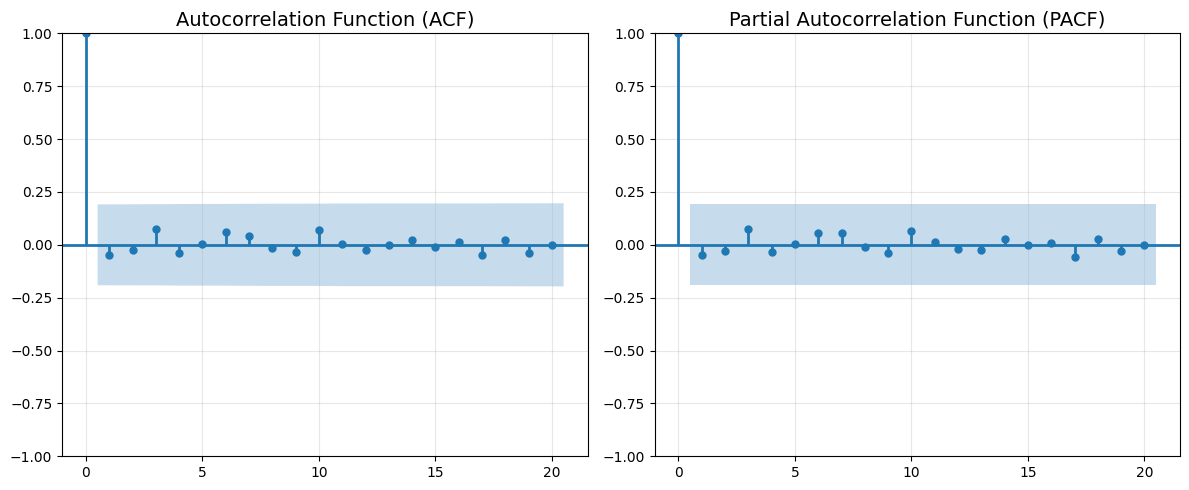


========== CATEGORY: GROCERIES ==========
ADF p-value: 0.0000 | differencing order d = 0


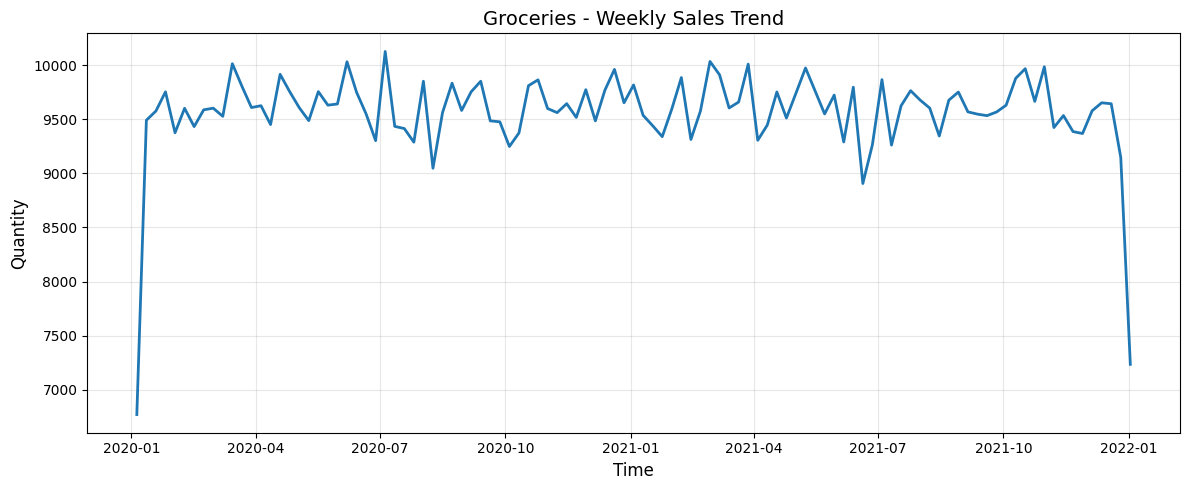

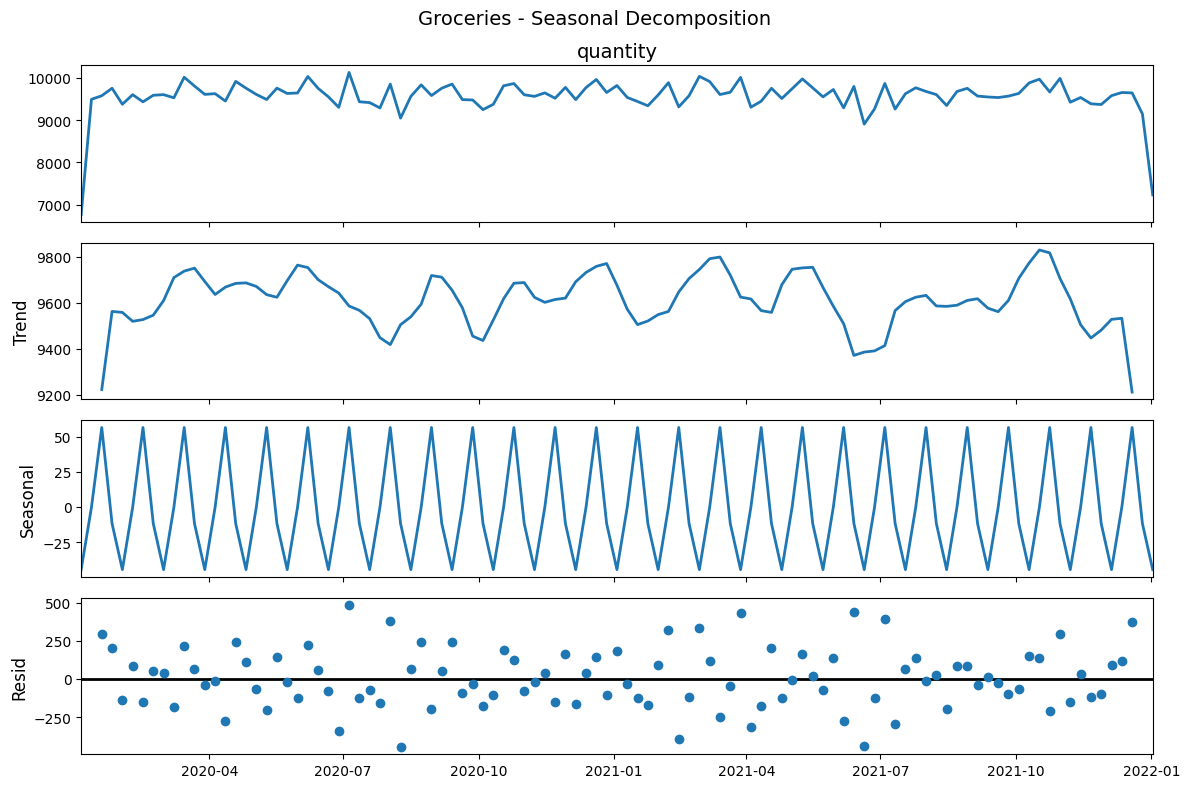

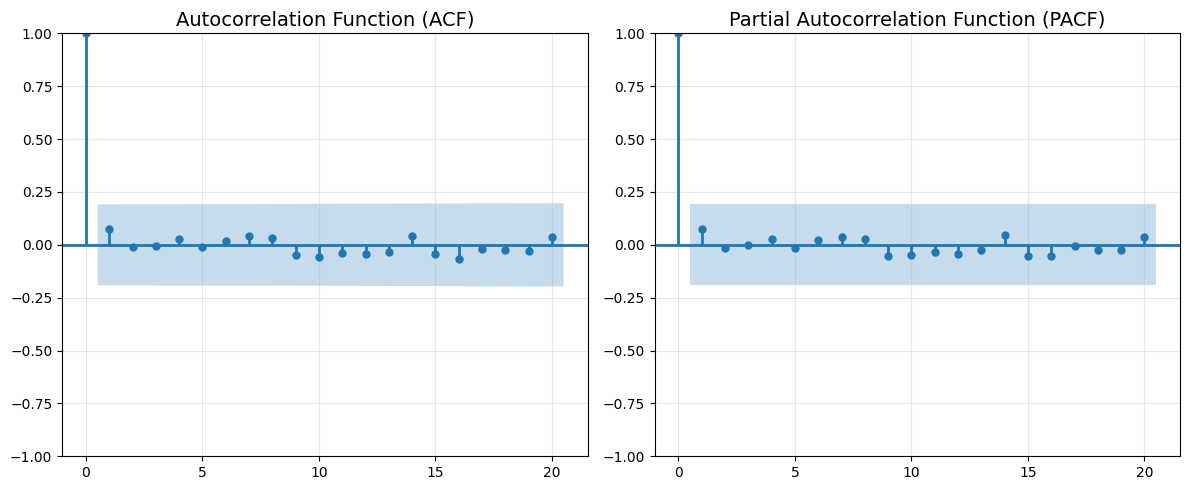


========== CATEGORY: TOYS ==========
ADF p-value: 0.0000 | differencing order d = 0


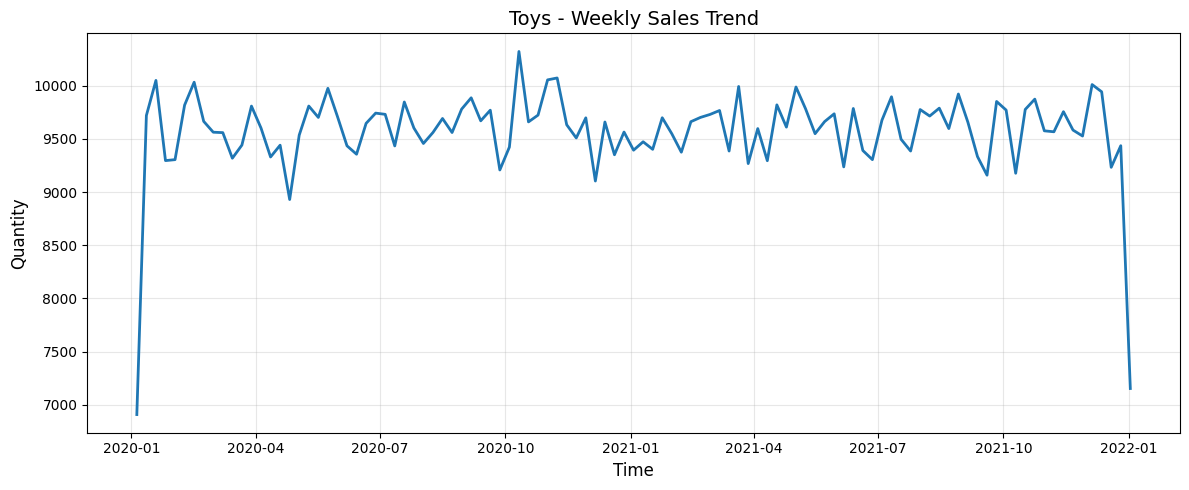

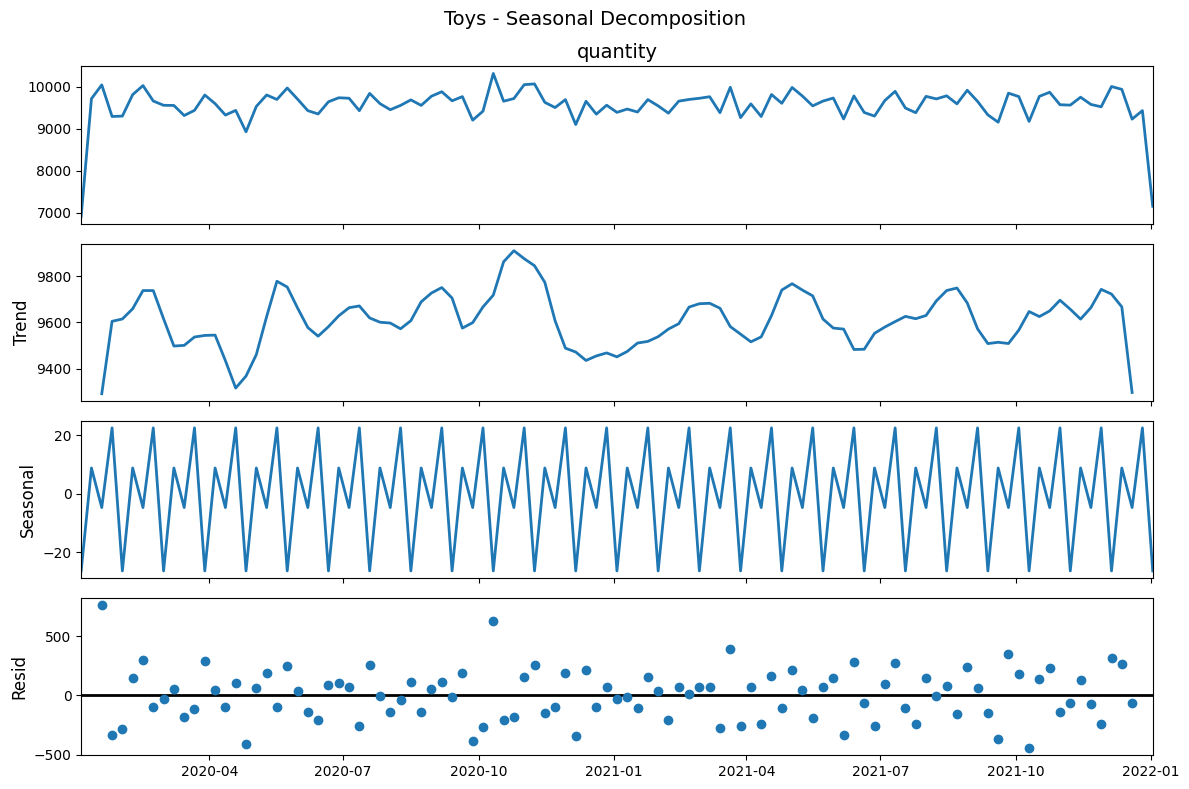

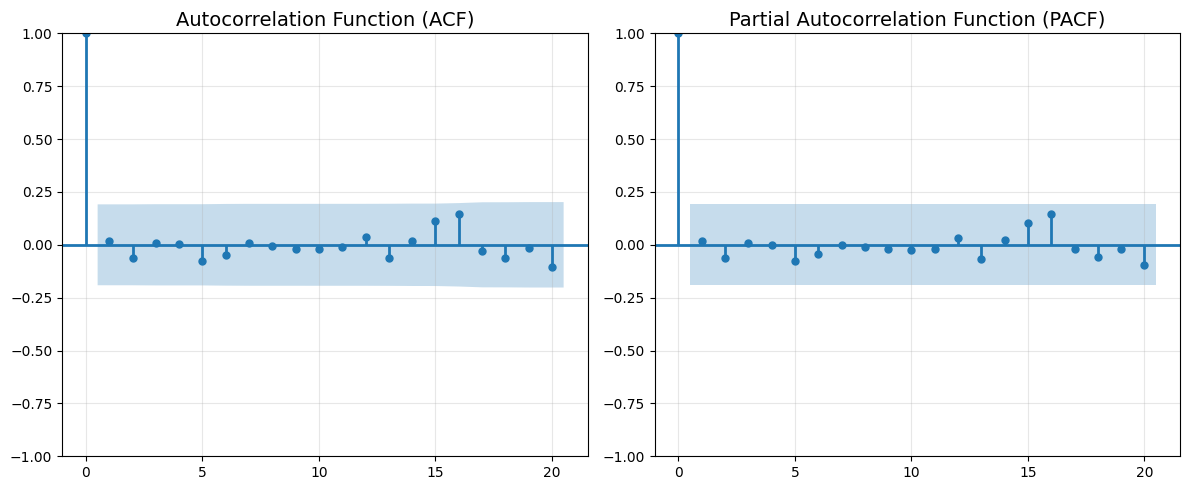

In [ ]:
# Import pandas to read files, process tabular data, and export CSV results.
import pandas as pd
# Import NumPy for numerical operations, arrays, and metrics.
import numpy as np
# Import Matplotlib to create charts for EDA and reporting.
import matplotlib.pyplot as plt
# Import statistical functions or models from statsmodels for tests and SARIMAX.
from statsmodels.tsa.stattools import adfuller
# Import statistical functions or models from statsmodels for tests and SARIMAX.
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# Import statistical functions or models from statsmodels for tests and SARIMAX.
from statsmodels.tsa.seasonal import seasonal_decompose

# =========================
# GLOBAL PLOT STYLE (CONSISTENT)
# =========================
# Configure or draw a chart to visualize the data or model results.
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 2,
    'grid.alpha': 0.3
})

# Define the `analyze_category_params` function to reuse logic and avoid duplicated code.
def analyze_category_params(category_name):
    # Print information to monitor progress and verify the result.
    print(f"\n========== CATEGORY: {category_name.upper()} ==========")

    # =========================
    # LOAD DATA
    # =========================
    # Read the CSV file into a DataFrame to start data processing.
    df = pd.read_csv('/content/category_daily_sales_final.csv')
    # Convert the date column to datetime so week, month, and year can be extracted correctly.
    df['date_only'] = pd.to_datetime(df['date_only'])

    # Weekly aggregation
    # Group data by category, product, or time to aggregate demand.
    df_weekly = df[df['product_category'] == category_name].groupby(
        # Assign the calculated result to a variable for use in later steps.
        pd.Grouper(key='date_only', freq='W')
    )['quantity'].sum().reset_index()

    # Assign the calculated result to a variable for use in later steps.
    series = df_weekly.set_index('date_only')['quantity']

    # =========================
    # ADF TEST (STATIONARITY)
    # =========================
    # Drop missing rows created by lag or rolling features so the model receives valid inputs.
    p_value = adfuller(series.dropna())[1]
    # Assign the calculated result to a variable for use in later steps.
    d = 0 if p_value < 0.05 else 1

    # Print information to monitor progress and verify the result.
    print(f"ADF p-value: {p_value:.4f} | differencing order d = {d}")

    # =========================
    # 1. TIME SERIES PLOT
    # =========================
    # Configure or draw a chart to visualize the data or model results.
    plt.figure()
    # Configure or draw a chart to visualize the data or model results.
    plt.plot(series, color='#1f77b4')
    # Configure or draw a chart to visualize the data or model results.
    plt.title(f'{category_name} - Weekly Sales Trend')
    # Configure or draw a chart to visualize the data or model results.
    plt.xlabel('Time')
    # Configure or draw a chart to visualize the data or model results.
    plt.ylabel('Quantity')
    # Configure or draw a chart to visualize the data or model results.
    plt.grid(True)
    # Configure or draw a chart to visualize the data or model results.
    plt.tight_layout()
    # Display the chart in the notebook for visual inspection.
    plt.show()

    # =========================
    # 2. SEASONAL DECOMPOSITION
    # =========================
    # Assign the calculated result to a variable for use in later steps.
    decomposition = seasonal_decompose(series, model='additive', period=4)

    # Assign the calculated result to a variable for use in later steps.
    fig = decomposition.plot()
    fig.set_size_inches(12, 8)
    # Assign the calculated result to a variable for use in later steps.
    fig.suptitle(f'{category_name} - Seasonal Decomposition', fontsize=14)
    # Configure or draw a chart to visualize the data or model results.
    plt.tight_layout()
    # Display the chart in the notebook for visual inspection.
    plt.show()

    # =========================
    # 3. ACF & PACF PLOTS
    # =========================
    # Drop missing rows created by lag or rolling features so the model receives valid inputs.
    data_diff = series.diff(d).dropna() if d > 0 else series

    # Configure or draw a chart to visualize the data or model results.
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # ACF
    # Call the function to perform the predefined processing or calculation step.
    plot_acf(
        data_diff,
        # Assign the calculated result to a variable for use in later steps.
        ax=axes[0],
        # Assign the calculated result to a variable for use in later steps.
        lags=20,
        # Assign the calculated result to a variable for use in later steps.
        alpha=0.05
    )
    axes[0].set_title('Autocorrelation Function (ACF)')
    axes[0].grid(True)

    # PACF
    # Call the function to perform the predefined processing or calculation step.
    plot_pacf(
        data_diff,
        # Assign the calculated result to a variable for use in later steps.
        ax=axes[1],
        # Assign the calculated result to a variable for use in later steps.
        lags=20,
        # Assign the calculated result to a variable for use in later steps.
        alpha=0.05,
        # Assign the calculated result to a variable for use in later steps.
        method='ywm'
    )
    axes[1].set_title('Partial Autocorrelation Function (PACF)')
    axes[1].grid(True)

    # Configure or draw a chart to visualize the data or model results.
    plt.tight_layout()
    # Display the chart in the notebook for visual inspection.
    plt.show()


# =========================
# RUN FOR ALL CATEGORIES
# =========================
# Assign the calculated result to a variable for use in later steps.
categories = ['Clothing', 'Electronics', 'Furniture', 'Groceries', 'Toys']

# Loop through each item, category, or week for step-by-step processing or forecasting.
for cat in categories:
    # Call the function to perform the predefined processing or calculation step.
    analyze_category_params(cat)


 CATEGORY: Clothing

[AUTO PARAMETERS]
ARIMA   : (2,0,3)
ARIMAX  : (2,0,3)
SARIMA  : (3,0,3)(0,1,0,4)
SARIMAX : (2,0,3)(0,1,0,4)

Winner: SARIMA_A | RMSE: 700.83


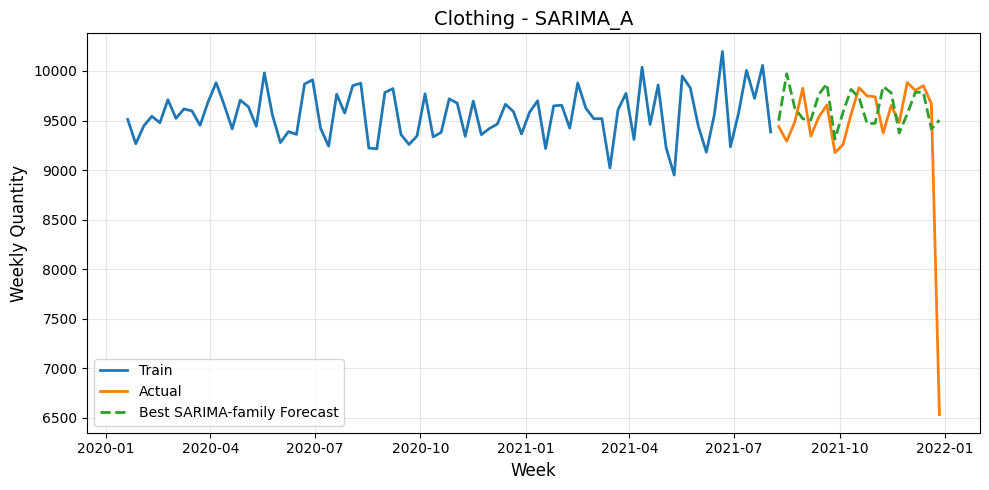


 CATEGORY: Electronics

[AUTO PARAMETERS]
ARIMA   : (1,0,3)
ARIMAX  : (1,0,3)
SARIMA  : (1,0,3)(0,1,0,4)
SARIMAX : (2,0,3)(0,1,0,4)

Winner: SARIMA_M | RMSE: 529.60


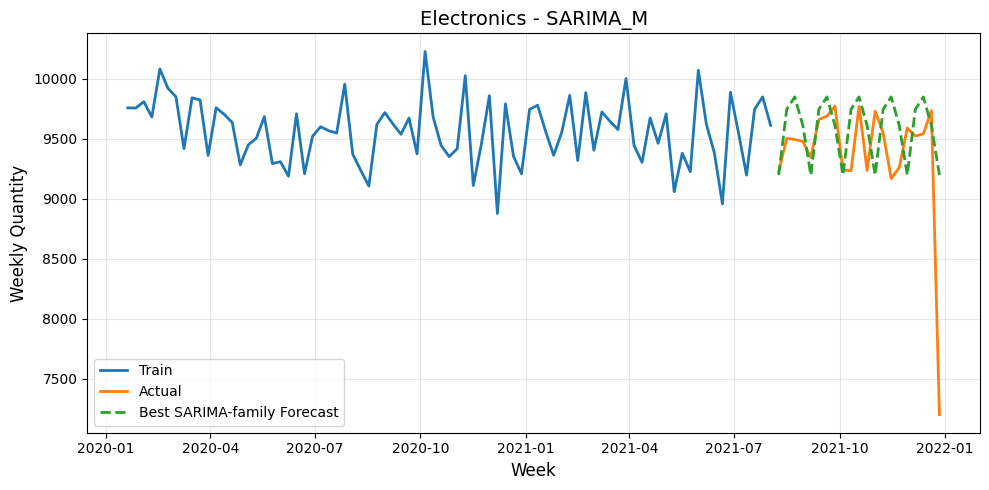


 CATEGORY: Furniture

[AUTO PARAMETERS]
ARIMA   : (1,0,3)
ARIMAX  : (1,0,3)
SARIMA  : (2,0,3)(0,1,0,4)
SARIMAX : (0,0,3)(0,1,0,4)

Winner: ARIMAX_A | RMSE: 622.20


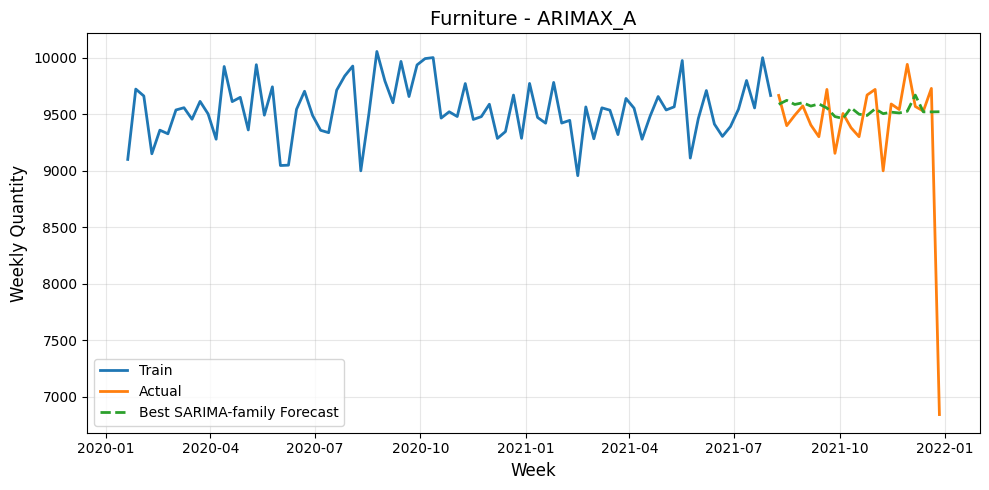


 CATEGORY: Groceries

[AUTO PARAMETERS]
ARIMA   : (1,0,3)
ARIMAX  : (2,0,3)
SARIMA  : (0,0,3)(0,1,0,4)
SARIMAX : (0,0,3)(0,1,0,4)

Winner: SARIMAX_M | RMSE: 527.01


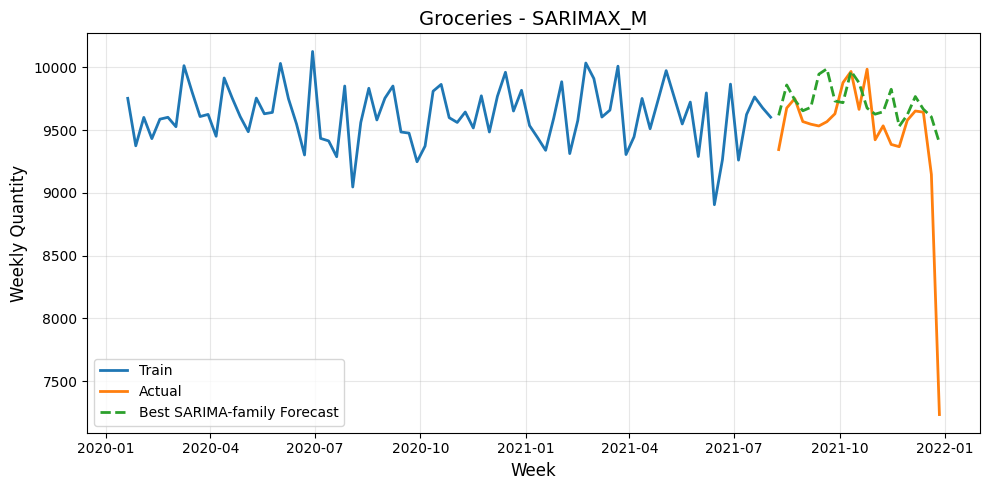


 CATEGORY: Toys

[AUTO PARAMETERS]
ARIMA   : (1,0,3)
ARIMAX  : (1,0,3)
SARIMA  : (0,0,3)(0,1,0,4)
SARIMAX : (0,0,3)(0,1,0,4)

Winner: SARIMA_A | RMSE: 570.40


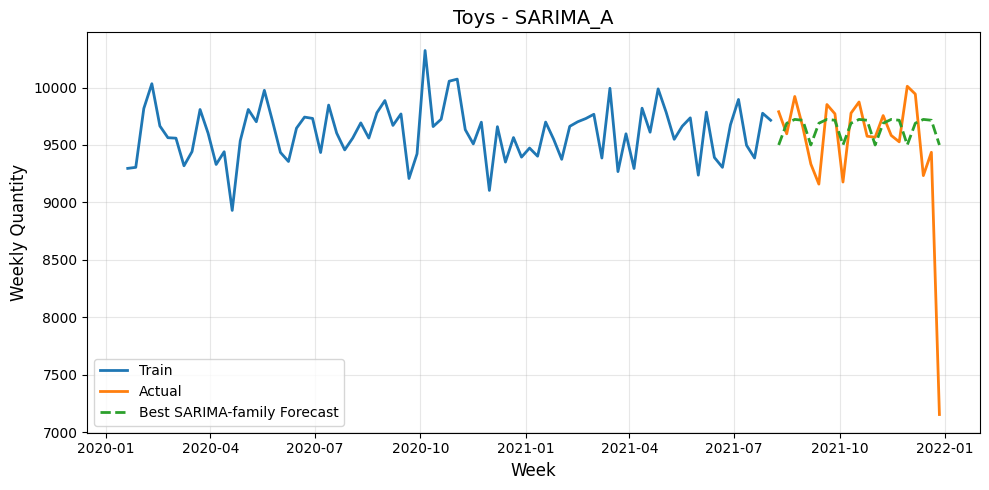


===== FINAL RMSE + MAE + sMAPE TABLE (SARIMA family) =====
   Category  ARIMA_M_RMSE  ARIMA_M_MAE  ARIMA_M_sMAPE  ARIMA_A_RMSE  ARIMA_A_MAE  ARIMA_A_sMAPE  ARIMAX_M_RMSE  ARIMAX_M_MAE  ARIMAX_M_sMAPE  ARIMAX_A_RMSE  ARIMAX_A_MAE  ARIMAX_A_sMAPE  SARIMA_M_RMSE  SARIMA_M_MAE  SARIMA_M_sMAPE  SARIMA_A_RMSE  SARIMA_A_MAE  SARIMA_A_sMAPE  SARIMAX_M_RMSE  SARIMAX_M_MAE  SARIMAX_M_sMAPE  SARIMAX_A_RMSE  SARIMAX_A_MAE  SARIMAX_A_sMAPE    Winner
   Clothing       9459.59      9435.00          200.0        713.41       320.06           3.63        9099.36       8966.62          174.71         739.82        357.49            4.01         847.07        488.52            5.34         700.83        356.67            4.01          844.39         476.64             5.21          700.87         391.36             4.36  SARIMA_A
Electronics       9392.39      9377.76          200.0        543.52       274.27           3.05        8927.51       8852.64          172.87         553.24        272.17       

In [ ]:
# =========================================
# ARIMA / ARIMAX / SARIMA / SARIMAX
# REPORT-SAFE VERSION
# Fixes:
# - rolling features use shift(1) to avoid target leakage
# - exogenous scaler is fitted on train data only
# - adds sMAPE and SARIMAX residual diagnostics
# =========================================

# Import pandas to read files, process tabular data, and export CSV results.
import pandas as pd
# Import NumPy for numerical operations, arrays, and metrics.
import numpy as np
# Import Matplotlib to create charts for EDA and reporting.
import matplotlib.pyplot as plt
# Import statistical functions or models from statsmodels for tests and SARIMAX.
from statsmodels.tsa.statespace.sarimax import SARIMAX
# Import statistical functions or models from statsmodels for tests and SARIMAX.
from statsmodels.stats.diagnostic import acorr_ljungbox
# Import scikit-learn tools for splitting, scaling, evaluation, or modeling.
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Import scikit-learn tools for splitting, scaling, evaluation, or modeling.
from sklearn.preprocessing import StandardScaler
# Hide non-critical warnings to keep the notebook output cleaner.
import warnings

# Hide non-critical warnings to keep the notebook output cleaner.
warnings.filterwarnings("ignore")

# Define the `rmse` function to reuse logic and avoid duplicated code.
def rmse(y_true, y_pred):
    # Return the final result so the calling code can use it.
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Define the `smape` function to reuse logic and avoid duplicated code.
def smape(y_true, y_pred):
    # Assign the calculated result to a variable for use in later steps.
    y_true = np.asarray(y_true, dtype=float)
    # Assign the calculated result to a variable for use in later steps.
    y_pred = np.asarray(y_pred, dtype=float)
    # Return the final result so the calling code can use it.
    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    )

# =========================================
# 1. LOAD + WEEKLY AGGREGATION
# =========================================
# Read the CSV file into a DataFrame to start data processing.
df = pd.read_csv('/content/category_daily_sales_final.csv')
# Convert the date column to datetime so week, month, and year can be extracted correctly.
df['date_only'] = pd.to_datetime(df['date_only'])
# Extract time components such as week, month, year, or day from the datetime column.
df['year_week'] = df['date_only'].dt.to_period('W').dt.to_timestamp()

# Group data by category, product, or time to aggregate demand.
df_weekly = df.groupby(
    ['year_week', 'product_category'],
    # Assign the calculated result to a variable for use in later steps.
    as_index=False
).agg({
    'quantity': 'sum',
    'unit_price': 'mean',
    'discount_applied': 'mean',
    'is_holiday': 'mean',  # FIX: holiday rate; sum/>0 becomes almost always constant
}).sort_values('year_week')

# =========================================
# 2. FEATURE ENGINEERING
# =========================================
# Define the `create_features` function to reuse logic and avoid duplicated code.
def create_features(df):
    # Create a copy of the DataFrame so modifications do not affect the original data.
    df = df.copy()

    # Lag features only use past information
    # Loop through each item, category, or week for step-by-step processing or forecasting.
    for lag in [1, 2, 3]:
        # Shift historical data to create lag features and avoid target leakage.
        df[f'price_lag{lag}'] = df['unit_price'].shift(lag)
        # Shift historical data to create lag features and avoid target leakage.
        df[f'discount_lag{lag}'] = df['discount_applied'].shift(lag)

    # CRITICAL FIX: shift(1) prevents the current target from entering its own predictors
    # Shift historical data to create lag features and avoid target leakage.
    df['rolling_mean_3'] = df['quantity'].shift(1).rolling(3).mean()
    # Shift historical data to create lag features and avoid target leakage.
    df['rolling_std_3']  = df['quantity'].shift(1).rolling(3).std()

    # Convert data types so columns have the correct format for modeling or calculations.
    df['holiday_flag'] = df['is_holiday'].astype(float)  # FIX: keep holiday rate, avoid constant binary flag
    # Return the final result so the calling code can use it.
    return df

# =========================================
# 3. MANUAL PARAMETERS
# =========================================
# Assign the calculated result to a variable for use in later steps.
manual_params = {
    'Clothing':    {'order': (0, 0, 0), 'seasonal': (0, 1, 0, 4)},
    'Electronics': {'order': (0, 0, 0), 'seasonal': (0, 1, 0, 4)},
    'Furniture':  {'order': (0, 0, 0), 'seasonal': (0, 1, 0, 4)},
    'Groceries':  {'order': (0, 0, 0), 'seasonal': (0, 1, 0, 4)},
    'Toys':       {'order': (0, 0, 0), 'seasonal': (0, 1, 0, 4)}
}

# =========================================
# 4. AUTO SEARCH p,q
# =========================================
# Define the `find_best_pq` function to reuse logic and avoid duplicated code.
def find_best_pq(y, exog, d, D, s):
    # Assign the calculated result to a variable for use in later steps.
    best_aic = np.inf
    # Assign the calculated result to a variable for use in later steps.
    best_pq = (0, 0)
    # Assign the calculated result to a variable for use in later steps.
    seasonal = (1, D, 1, s) if s > 0 else (0, 0, 0, 0)

    # Loop through each item, category, or week for step-by-step processing or forecasting.
    for p in range(4):
        # Loop through each item, category, or week for step-by-step processing or forecasting.
        for q in range(4):
            # Start a try block for code that may raise an exception.
            try:
                # Initialize the SARIMAX model to learn trend, autocorrelation, and exogenous effects.
                model = SARIMAX(
                    y,
                    # Assign the calculated result to a variable for use in later steps.
                    exog=exog,
                    # Assign the calculated result to a variable for use in later steps.
                    order=(p, d, q),
                    # Assign the calculated result to a variable for use in later steps.
                    seasonal_order=seasonal,
                    # Assign the calculated result to a variable for use in later steps.
                    enforce_stationarity=False,
                    # Assign the calculated result to a variable for use in later steps.
                    enforce_invertibility=False
                ).fit(disp=False)

                # Check a condition to choose the appropriate processing branch.
                if model.aic < best_aic:
                    # Assign the calculated result to a variable for use in later steps.
                    best_aic = model.aic
                    # Assign the calculated result to a variable for use in later steps.
                    best_pq = (p, q)
            # Handle errors when a file, variable, or model does not exist or a previous step has not run.
            except Exception:
                continue

    # Return the final result so the calling code can use it.
    return best_pq

# =========================================
# 5. MAIN LOOP
# =========================================
# Assign the calculated result to a variable for use in later steps.
results_sarima = []
# Assign the calculated result to a variable for use in later steps.
sarima_test_data = {}
# Assign the calculated result to a variable for use in later steps.
sarima_diagnostics = []

# Define constants or configuration values used multiple times in this cell.
EXOG_COLS_SARIMA = [
    'price_lag1', 'price_lag2', 'price_lag3',
    'discount_lag1', 'discount_lag2', 'discount_lag3',
    'holiday_flag',
    'rolling_mean_3', 'rolling_std_3'
]

# Loop through each item, category, or week for step-by-step processing or forecasting.
for cat in manual_params.keys():
    # Print information to monitor progress and verify the result.
    print("\n==============================")
    # Print information to monitor progress and verify the result.
    print(f" CATEGORY: {cat}")
    # Print information to monitor progress and verify the result.
    print("==============================")

    # Create a copy of the DataFrame so modifications do not affect the original data.
    df_cat = df_weekly[df_weekly['product_category'] == cat].copy()
    # Drop missing rows created by lag or rolling features so the model receives valid inputs.
    df_cat = create_features(df_cat).dropna()
    # Assign the calculated result to a variable for use in later steps.
    df_cat = df_cat.set_index('year_week').sort_index()

    # Assign the calculated result to a variable for use in later steps.
    y = df_cat['quantity']
    # Assign the calculated result to a variable for use in later steps.
    exog = df_cat[EXOG_COLS_SARIMA]

    # Assign the calculated result to a variable for use in later steps.
    split = int(len(y) * 0.8)

    # Assign the calculated result to a variable for use in later steps.
    y_train = y.iloc[:split]
    # Assign the calculated result to a variable for use in later steps.
    y_test  = y.iloc[split:]

    # Assign the calculated result to a variable for use in later steps.
    exog_train_raw = exog.iloc[:split]
    # Assign the calculated result to a variable for use in later steps.
    exog_test_raw  = exog.iloc[split:]

    # CRITICAL FIX: fit scaler on train only
    # Initialize a scaler to normalize features and make model training more stable.
    scaler = StandardScaler()
    # Create a new DataFrame to store intermediate results or output tables.
    exog_train = pd.DataFrame(
        # Fit the scaler on the training data and then transform the training data.
        scaler.fit_transform(exog_train_raw),
        # Assign the calculated result to a variable for use in later steps.
        index=exog_train_raw.index,
        # Assign the calculated result to a variable for use in later steps.
        columns=exog_train_raw.columns
    )
    # Create a new DataFrame to store intermediate results or output tables.
    exog_test = pd.DataFrame(
        # Transform validation, test, or future data using the scaler fitted on the training data.
        scaler.transform(exog_test_raw),
        # Assign the calculated result to a variable for use in later steps.
        index=exog_test_raw.index,
        # Assign the calculated result to a variable for use in later steps.
        columns=exog_test_raw.columns
    )

    # Assign the calculated result to a variable for use in later steps.
    p_m, d_m, q_m = manual_params[cat]['order']
    # Assign the calculated result to a variable for use in later steps.
    P_m, D_m, Q_m, s_m = manual_params[cat]['seasonal']

    # Assign the calculated result to a variable for use in later steps.
    pq_arima   = find_best_pq(y_train, None,       d_m, 0,   0)
    # Assign the calculated result to a variable for use in later steps.
    pq_arimax  = find_best_pq(y_train, exog_train, d_m, 0,   0)
    # Assign the calculated result to a variable for use in later steps.
    pq_sarima  = find_best_pq(y_train, None,       d_m, D_m, s_m)
    # Assign the calculated result to a variable for use in later steps.
    pq_sarimax = find_best_pq(y_train, exog_train, d_m, D_m, s_m)

    # Print information to monitor progress and verify the result.
    print("\n[AUTO PARAMETERS]")
    # Print information to monitor progress and verify the result.
    print("ARIMA   :", f"({pq_arima[0]},{d_m},{pq_arima[1]})")
    # Print information to monitor progress and verify the result.
    print("ARIMAX  :", f"({pq_arimax[0]},{d_m},{pq_arimax[1]})")
    # Print information to monitor progress and verify the result.
    print("SARIMA  :", f"({pq_sarima[0]},{d_m},{pq_sarima[1]})({P_m},{D_m},{Q_m},{s_m})")
    # Print information to monitor progress and verify the result.
    print("SARIMAX :", f"({pq_sarimax[0]},{d_m},{pq_sarimax[1]})({P_m},{D_m},{Q_m},{s_m})")

    # Assign the calculated result to a variable for use in later steps.
    models = {
        'ARIMA_M':   (None,       (p_m, d_m, q_m),                   (0, 0, 0, 0)),
        'ARIMA_A':   (None,       (pq_arima[0], d_m, pq_arima[1]),   (0, 0, 0, 0)),
        'ARIMAX_M':  (exog_train, (p_m, d_m, q_m),                   (0, 0, 0, 0)),
        'ARIMAX_A':  (exog_train, (pq_arimax[0], d_m, pq_arimax[1]), (0, 0, 0, 0)),
        'SARIMA_M':  (None,       (p_m, d_m, q_m),                   (P_m, D_m, Q_m, s_m)),
        'SARIMA_A':  (None,       (pq_sarima[0], d_m, pq_sarima[1]), (P_m, D_m, Q_m, s_m)),
        'SARIMAX_M': (exog_train, (p_m, d_m, q_m),                   (P_m, D_m, Q_m, s_m)),
        'SARIMAX_A': (exog_train, (pq_sarimax[0], d_m, pq_sarimax[1]), (P_m, D_m, Q_m, s_m))
    }

    # Calculate an evaluation metric for forecast error or model quality.
    best_rmse = np.inf
    # Assign the calculated result to a variable for use in later steps.
    best_name = None
    # Assign the calculated result to a variable for use in later steps.
    best_config = None
    # Assign the calculated result to a variable for use in later steps.
    best_forecast = None
    # Assign the calculated result to a variable for use in later steps.
    best_model_fit = None

    # Assign the calculated result to a variable for use in later steps.
    row = {'Category': cat}

    # Loop through each item, category, or week for step-by-step processing or forecasting.
    for name, (ex_train, order, seasonal) in models.items():
        # Start a try block for code that may raise an exception.
        try:
            # Initialize the SARIMAX model to learn trend, autocorrelation, and exogenous effects.
            model = SARIMAX(
                y_train,
                # Assign the calculated result to a variable for use in later steps.
                exog=ex_train,
                # Assign the calculated result to a variable for use in later steps.
                order=order,
                # Assign the calculated result to a variable for use in later steps.
                seasonal_order=seasonal,
                # Assign the calculated result to a variable for use in later steps.
                enforce_stationarity=False,
                # Assign the calculated result to a variable for use in later steps.
                enforce_invertibility=False
            ).fit(disp=False)

            # Use the trained model to generate forecasts or estimates.
            forecast = model.forecast(
                # Assign the calculated result to a variable for use in later steps.
                steps=len(y_test),
                # Assign the calculated result to a variable for use in later steps.
                exog=exog_test if ex_train is not None else None
            )

            # Calculate an evaluation metric for forecast error or model quality.
            model_rmse = rmse(y_test, forecast)
            # Calculate an evaluation metric for forecast error or model quality.
            model_mae  = mean_absolute_error(y_test, forecast)
            # Calculate an evaluation metric for forecast error or model quality.
            model_smape = smape(y_test, forecast)

            # Calculate an evaluation metric for forecast error or model quality.
            row[f'{name}_RMSE']  = round(model_rmse, 2)
            # Create or update a DataFrame column for feature engineering or modeling.
            row[f'{name}_MAE']   = round(model_mae, 2)
            # Calculate an evaluation metric for forecast error or model quality.
            row[f'{name}_sMAPE'] = round(model_smape, 2)

            # Check a condition to choose the appropriate processing branch.
            if model_rmse < best_rmse:
                # Calculate an evaluation metric for forecast error or model quality.
                best_rmse = model_rmse
                # Assign the calculated result to a variable for use in later steps.
                best_name = name
                # Assign the calculated result to a variable for use in later steps.
                best_config = (ex_train, order, seasonal)
                # Assign the calculated result to a variable for use in later steps.
                best_forecast = forecast
                # Assign the calculated result to a variable for use in later steps.
                best_model_fit = model

        # Handle errors when a file, variable, or model does not exist or a previous step has not run.
        except Exception:
            # Calculate an evaluation metric for forecast error or model quality.
            row[f'{name}_RMSE']  = np.nan
            # Create or update a DataFrame column for feature engineering or modeling.
            row[f'{name}_MAE']   = np.nan
            # Create or update a DataFrame column for feature engineering or modeling.
            row[f'{name}_sMAPE'] = np.nan

    # Create or update a DataFrame column for feature engineering or modeling.
    row['Winner'] = best_name
    # Append a new result to the list for aggregation after the loop.
    results_sarima.append(row)

    # Calculate an evaluation metric for forecast error or model quality.
    print(f"\nWinner: {best_name} | RMSE: {best_rmse:.2f}")

    # Residual diagnostic for the winning SARIMA-family model
    # Start a try block for code that may raise an exception.
    try:
        # Drop missing rows created by lag or rolling features so the model receives valid inputs.
        lb = acorr_ljungbox(best_model_fit.resid.dropna(), lags=[10], return_df=True)
        # Calculate the p-value for the linear relationship between forecast and actual demand.
        lb_pvalue = float(lb['lb_pvalue'].iloc[0])
    # Handle errors when a file, variable, or model does not exist or a previous step has not run.
    except Exception:
        # Calculate the p-value for the linear relationship between forecast and actual demand.
        lb_pvalue = np.nan

    # Append a new result to the list for aggregation after the loop.
    sarima_diagnostics.append({
        'Category': cat,
        'Best_Variant': best_name,
        # Calculate the p-value for the linear relationship between forecast and actual demand.
        'Ljung_Box_pvalue_lag10': round(lb_pvalue, 4) if pd.notna(lb_pvalue) else np.nan
    })

    # Create or update a DataFrame column for feature engineering or modeling.
    sarima_test_data[cat] = {
        'dates': y_test.index,
        'actual': y_test.values,
        'forecast': np.asarray(best_forecast)
    }

    # Configure or draw a chart to visualize the data or model results.
    plt.figure(figsize=(10, 5))
    # Configure or draw a chart to visualize the data or model results.
    plt.plot(y_train.index, y_train, label='Train')
    # Configure or draw a chart to visualize the data or model results.
    plt.plot(y_test.index, y_test, label='Actual')
    # Configure or draw a chart to visualize the data or model results.
    plt.plot(y_test.index, best_forecast, '--', label='Best SARIMA-family Forecast')
    # Configure or draw a chart to visualize the data or model results.
    plt.title(f"{cat} - {best_name}")
    # Configure or draw a chart to visualize the data or model results.
    plt.xlabel("Week")
    # Configure or draw a chart to visualize the data or model results.
    plt.ylabel("Weekly Quantity")
    # Configure or draw a chart to visualize the data or model results.
    plt.legend()
    # Configure or draw a chart to visualize the data or model results.
    plt.grid()
    # Configure or draw a chart to visualize the data or model results.
    plt.tight_layout()
    # Save the chart as an image for the report or presentation slides.
    plt.savefig(f"{cat}_sarima_family_forecast.png", dpi=300, bbox_inches='tight')
    # Display the chart in the notebook for visual inspection.
    plt.show()

# =========================================
# 6. FINAL TABLE
# =========================================
# Create a new DataFrame to store intermediate results or output tables.
df_result_sarima = pd.DataFrame(results_sarima)

# Calculate an evaluation metric for forecast error or model quality.
print("\n===== FINAL RMSE + MAE + sMAPE TABLE (SARIMA family) =====")
# Print information to monitor progress and verify the result.
print(df_result_sarima.to_string(index=False))

# Assign the calculated result to a variable for use in later steps.
sarima_summary = []
# Loop through each item, category, or week for step-by-step processing or forecasting.
for row in results_sarima:
    # Assign the calculated result to a variable for use in later steps.
    cat = row['Category']
    # Assign the calculated result to a variable for use in later steps.
    best_var = row['Winner']
    # Append a new result to the list for aggregation after the loop.
    sarima_summary.append({
        'Category': cat,
        'Best_Variant': best_var,
        # Calculate an evaluation metric for forecast error or model quality.
        'SARIMA_fam_RMSE':  row.get(f'{best_var}_RMSE',  np.nan),
        'SARIMA_fam_MAE':   row.get(f'{best_var}_MAE',   np.nan),
        'SARIMA_fam_sMAPE': row.get(f'{best_var}_sMAPE', np.nan)
    })

# Create a new DataFrame to store intermediate results or output tables.
df_sarima_summary = pd.DataFrame(sarima_summary)
# Create a new DataFrame to store intermediate results or output tables.
df_sarima_diagnostics = pd.DataFrame(sarima_diagnostics)

# Export the result table to a CSV file for the report, inventory, or recommendation module.
df_result_sarima.to_csv('sarima_family_all_results.csv', index=False)
# Export the result table to a CSV file for the report, inventory, or recommendation module.
df_sarima_summary.to_csv('sarima_family_summary.csv', index=False)
# Export the result table to a CSV file for the report, inventory, or recommendation module.
df_sarima_diagnostics.to_csv('sarima_residual_diagnostics.csv', index=False)

# Print information to monitor progress and verify the result.
print("\n[SARIMA FAMILY SUMMARY]")
# Print information to monitor progress and verify the result.
print(df_sarima_summary.to_string(index=False))

# Print information to monitor progress and verify the result.
print("\n[RESIDUAL DIAGNOSTIC - LJUNG-BOX]")
# Print information to monitor progress and verify the result.
print(df_sarima_diagnostics.to_string(index=False))


===== Clothing =====
Train RMSE: 234.05 | MAE: 195.64
Val   RMSE: 304.27 | MAE: 246.28
Test  RMSE: 784.40 | MAE: 364.52 | sMAPE: 4.18%
Naive Test RMSE: 820.08 | MA4 Test RMSE: 849.14


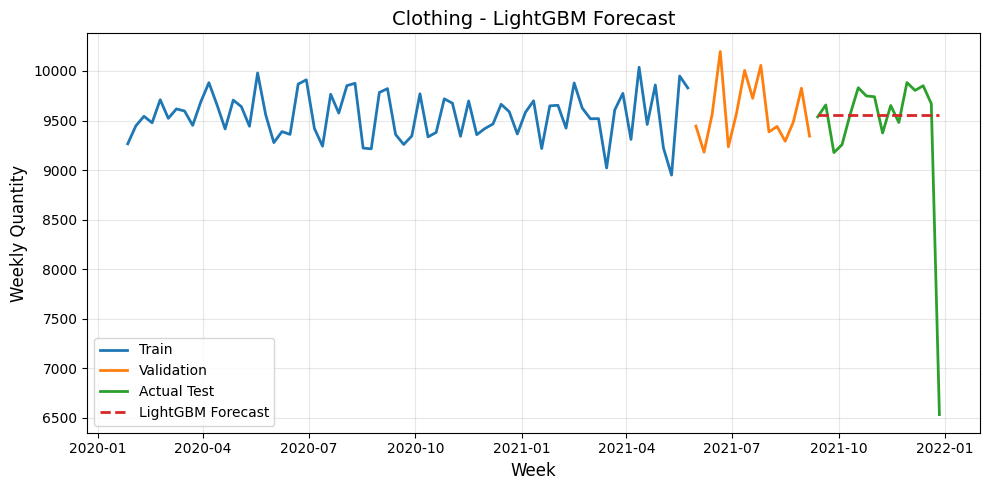


===== Electronics =====
Train RMSE: 263.91 | MAE: 217.03
Val   RMSE: 281.74 | MAE: 222.29
Test  RMSE: 626.84 | MAE: 319.25 | sMAPE: 3.57%
Naive Test RMSE: 704.73 | MA4 Test RMSE: 648.88


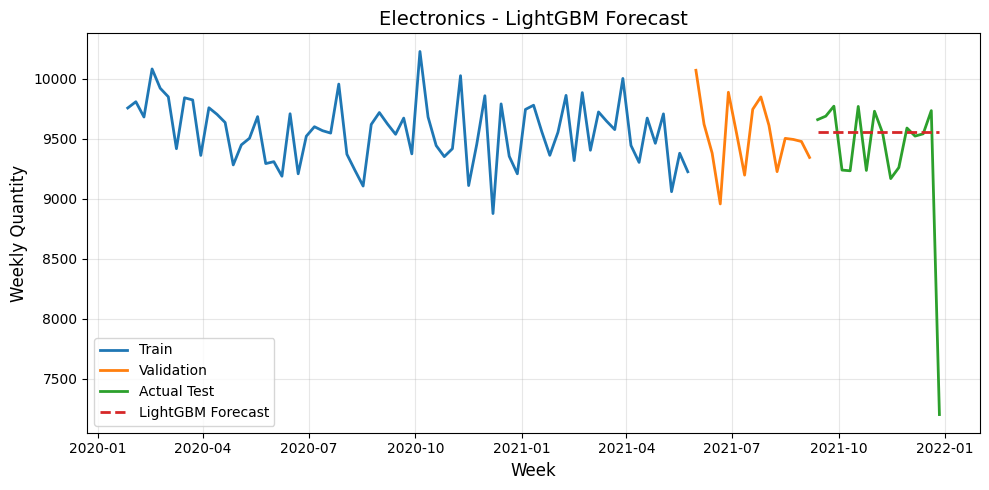


===== Furniture =====
Train RMSE: 249.54 | MAE: 193.15
Val   RMSE: 178.97 | MAE: 140.59
Test  RMSE: 715.09 | MAE: 342.31 | sMAPE: 3.89%
Naive Test RMSE: 804.40 | MA4 Test RMSE: 755.21


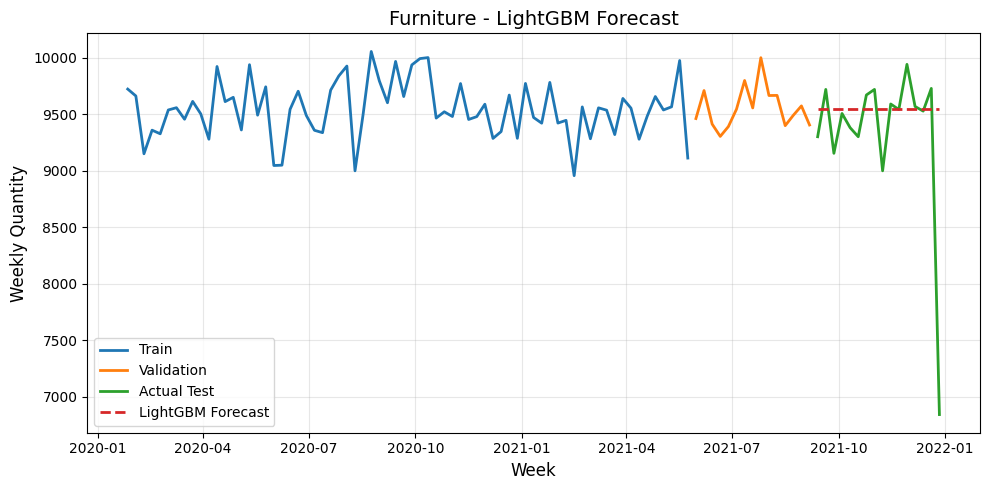


===== Groceries =====
Train RMSE: 216.59 | MAE: 174.81
Val   RMSE: 275.66 | MAE: 201.90
Test  RMSE: 637.42 | MAE: 308.19 | sMAPE: 3.43%
Naive Test RMSE: 534.45 | MA4 Test RMSE: 614.11


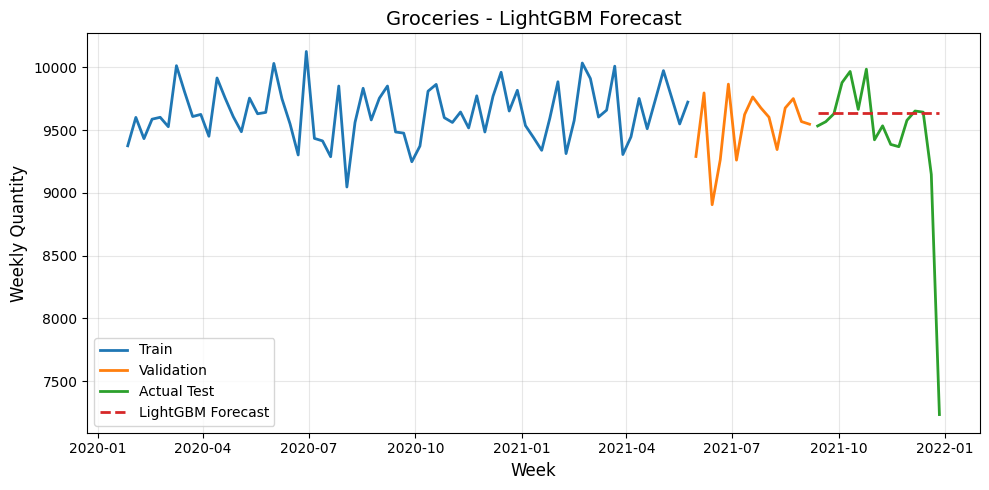


===== Toys =====
Train RMSE: 238.48 | MAE: 184.73
Val   RMSE: 217.50 | MAE: 190.18
Test  RMSE: 666.92 | MAE: 362.86 | sMAPE: 4.01%
Naive Test RMSE: 679.78 | MA4 Test RMSE: 685.26


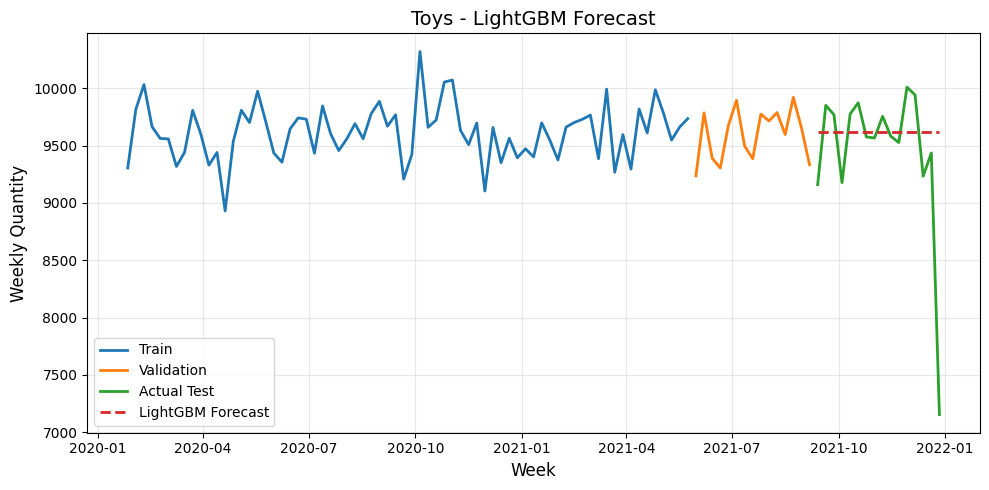


===== FINAL RESULTS (LightGBM + Baselines) =====
   Category  Train_RMSE  Train_MAE  Val_RMSE  Val_MAE  Test_RMSE  Test_MAE  Test_sMAPE  Naive_RMSE  Naive_MAE  MA4_RMSE  MA4_MAE
   Clothing      234.05     195.64    304.27   246.28     784.40    364.52        4.18      820.08     387.88    849.14   393.70
Electronics      263.91     217.03    281.74   222.29     626.84    319.25        3.57      704.73     394.94    648.88   374.50
  Furniture      249.54     193.15    178.97   140.59     715.09    342.31        3.89      804.40     458.31    755.21   375.19
  Groceries      216.59     174.81    275.66   201.90     637.42    308.19        3.43      534.45     288.12    614.11   340.83
       Toys      238.48     184.73    217.50   190.18     666.92    362.86        4.01      679.78     419.56    685.26   388.50


In [ ]:
# =========================================
# LIGHTGBM
# REPORT-SAFE VERSION
# Fixes:
# - rolling features use shift(1) to avoid target leakage
# - train/validation/test split is chronological
# - scaler is fitted on train only
# - adds Naive and Moving Average baselines
# - adds sMAPE
# =========================================

# Import pandas to read files, process tabular data, and export CSV results.
import pandas as pd
# Import NumPy for numerical operations, arrays, and metrics.
import numpy as np
# Import Matplotlib to create charts for EDA and reporting.
import matplotlib.pyplot as plt
# Import LightGBM to train a gradient-boosted decision-tree machine learning model.
import lightgbm as lgb
# Import scikit-learn tools for splitting, scaling, evaluation, or modeling.
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Import scikit-learn tools for splitting, scaling, evaluation, or modeling.
from sklearn.preprocessing import StandardScaler
# Hide non-critical warnings to keep the notebook output cleaner.
import warnings

# Hide non-critical warnings to keep the notebook output cleaner.
warnings.filterwarnings("ignore")

# Define the `rmse` function to reuse logic and avoid duplicated code.
def rmse(y_true, y_pred):
    # Return the final result so the calling code can use it.
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Define the `smape` function to reuse logic and avoid duplicated code.
def smape(y_true, y_pred):
    # Assign the calculated result to a variable for use in later steps.
    y_true = np.asarray(y_true, dtype=float)
    # Assign the calculated result to a variable for use in later steps.
    y_pred = np.asarray(y_pred, dtype=float)
    # Return the final result so the calling code can use it.
    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    )

# =========================================
# 1. LOAD DATA + WEEKLY AGGREGATION
# =========================================
# Read the CSV file into a DataFrame to start data processing.
df = pd.read_csv('/content/category_daily_sales_final.csv')
# Convert the date column to datetime so week, month, and year can be extracted correctly.
df['date_only'] = pd.to_datetime(df['date_only'])
# Extract time components such as week, month, year, or day from the datetime column.
df['year_week'] = df['date_only'].dt.to_period('W').dt.to_timestamp()

# Group data by category, product, or time to aggregate demand.
df_weekly = df.groupby(
    ['year_week', 'product_category'],
    # Assign the calculated result to a variable for use in later steps.
    as_index=False
).agg({
    'quantity': 'sum',
    'unit_price': 'mean',
    'discount_applied': 'mean',
    'product_rating': 'mean',
    'product_stock': 'mean',
    'is_holiday': 'mean',  # FIX: holiday rate; sum/>0 becomes almost always constant
    'is_weekend_derived': 'sum',
    'total_returned_items': 'sum'
}).sort_values('year_week')

# =========================================
# 2. FEATURE ENGINEERING
# =========================================
# Define the `create_features_lgb` function to reuse logic and avoid duplicated code.
def create_features_lgb(df):
    # Create a copy of the DataFrame so modifications do not affect the original data.
    df = df.copy()

    # Check a condition to choose the appropriate processing branch.
    if 'year_week' in df.columns:
        # Assign the calculated result to a variable for use in later steps.
        date_col = df['year_week']
    # Handle the remaining case when the previous conditions are not satisfied.
    else:
        # Assign the calculated result to a variable for use in later steps.
        date_col = df.index.to_series()

    # Loop through each item, category, or week for step-by-step processing or forecasting.
    for lag in [1, 2, 4]:
        # Shift historical data to create lag features and avoid target leakage.
        df[f'qty_lag{lag}'] = df['quantity'].shift(lag)
        # Shift historical data to create lag features and avoid target leakage.
        df[f'price_lag{lag}'] = df['unit_price'].shift(lag)
        # Shift historical data to create lag features and avoid target leakage.
        df[f'discount_lag{lag}'] = df['discount_applied'].shift(lag)

    # CRITICAL FIX: shift(1) prevents leakage
    # Shift historical data to create lag features and avoid target leakage.
    df['rolling_mean_4'] = df['quantity'].shift(1).rolling(4).mean()
    # Shift historical data to create lag features and avoid target leakage.
    df['rolling_std_4']  = df['quantity'].shift(1).rolling(4).std()

    # Convert data types so columns have the correct format for modeling or calculations.
    df['holiday_flag'] = df['is_holiday'].astype(float)  # FIX: keep holiday rate, avoid constant binary flag
    # Convert data types so columns have the correct format for modeling or calculations.
    df['weekend_flag'] = (df['is_weekend_derived'] > 0).astype(int)

    # Extract time components such as week, month, year, or day from the datetime column.
    df['week_of_year'] = date_col.dt.isocalendar().week.astype(int)
    # Extract time components such as week, month, year, or day from the datetime column.
    df['month'] = date_col.dt.month
    # Extract time components such as week, month, year, or day from the datetime column.
    df['quarter'] = date_col.dt.quarter

    # Return the final result so the calling code can use it.
    return df

# Define constants or configuration values used multiple times in this cell.
FEATURE_COLS = [
    'qty_lag1', 'qty_lag2', 'qty_lag4',
    'price_lag1', 'price_lag2',
    'discount_lag1',
    'rolling_mean_4', 'rolling_std_4',
    'holiday_flag', 'weekend_flag',
    'week_of_year', 'month', 'quarter',
    'product_rating', 'product_stock', 'total_returned_items'
]

# Assign the calculated result to a variable for use in later steps.
categories = ['Clothing', 'Electronics', 'Furniture', 'Groceries', 'Toys']

# =========================================
# 3. LIGHTGBM PARAMETERS
# =========================================
# Assign the calculated result to a variable for use in later steps.
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.03,
    'num_leaves': 15,
    'max_depth': 6,
    'min_child_samples': 30,
    'feature_fraction': 0.7,
    'bagging_fraction': 0.7,
    'bagging_freq': 5,
    'reg_alpha': 0.5,
    'reg_lambda': 2.0,
    'verbose': -1
}

# Assign the calculated result to a variable for use in later steps.
results_lgb = []
# Assign the calculated result to a variable for use in later steps.
lgb_test_data = {}

# =========================================
# 4. TRAIN + VALIDATE + TEST
# =========================================
# Loop through each item, category, or week for step-by-step processing or forecasting.
for cat in categories:
    # Print information to monitor progress and verify the result.
    print(f"\n===== {cat} =====")

    # Create a copy of the DataFrame so modifications do not affect the original data.
    df_cat = df_weekly[df_weekly['product_category'] == cat].copy()
    # Drop missing rows created by lag or rolling features so the model receives valid inputs.
    df_cat = create_features_lgb(df_cat).dropna()
    # Assign the calculated result to a variable for use in later steps.
    df_cat = df_cat.set_index('year_week').sort_index()

    # Define constants or configuration values used multiple times in this cell.
    X = df_cat[FEATURE_COLS]
    # Assign the calculated result to a variable for use in later steps.
    y = df_cat['quantity']

    # Assign the calculated result to a variable for use in later steps.
    n = len(y)
    # Assign the calculated result to a variable for use in later steps.
    train_end = int(n * 0.70)
    # Assign the calculated result to a variable for use in later steps.
    val_end   = int(n * 0.85)

    # Assign the calculated result to a variable for use in later steps.
    X_train, X_val, X_test = X.iloc[:train_end], X.iloc[train_end:val_end], X.iloc[val_end:]
    # Assign the calculated result to a variable for use in later steps.
    y_train, y_val, y_test = y.iloc[:train_end], y.iloc[train_end:val_end], y.iloc[val_end:]

    # Initialize a scaler to normalize features and make model training more stable.
    scaler = StandardScaler()
    # Fit the scaler on the training data and then transform the training data.
    X_train_sc = scaler.fit_transform(X_train)
    # Transform validation, test, or future data using the scaler fitted on the training data.
    X_val_sc   = scaler.transform(X_val)
    # Transform validation, test, or future data using the scaler fitted on the training data.
    X_test_sc  = scaler.transform(X_test)

    # Convert the data into the Dataset format optimized for LightGBM.
    train_set = lgb.Dataset(X_train_sc, label=y_train)
    # Convert the data into the Dataset format optimized for LightGBM.
    val_set   = lgb.Dataset(X_val_sc,   label=y_val)

    # Train the LightGBM model using the defined parameters and validation set.
    model = lgb.train(
        params,
        train_set,
        # Assign the calculated result to a variable for use in later steps.
        num_boost_round=500,
        # Assign the calculated result to a variable for use in later steps.
        valid_sets=[val_set],
        # Assign the calculated result to a variable for use in later steps.
        callbacks=[lgb.early_stopping(40, verbose=False)]
    )

    # Use the trained model to generate forecasts or estimates.
    train_pred = model.predict(X_train_sc)
    # Use the trained model to generate forecasts or estimates.
    val_pred   = model.predict(X_val_sc)
    # Use the trained model to generate forecasts or estimates.
    test_pred  = model.predict(X_test_sc)

    # Baselines on test horizon
    # Shift historical data to create lag features and avoid target leakage.
    naive_pred = df_cat['quantity'].shift(1).loc[y_test.index]
    # Shift historical data to create lag features and avoid target leakage.
    ma4_pred   = df_cat['quantity'].shift(1).rolling(4).mean().loc[y_test.index]

    # Assign the calculated result to a variable for use in later steps.
    baseline_mask = naive_pred.notna() & ma4_pred.notna()
    # Assign the calculated result to a variable for use in later steps.
    y_test_base = y_test.loc[baseline_mask]
    # Assign the calculated result to a variable for use in later steps.
    naive_pred = naive_pred.loc[baseline_mask]
    # Assign the calculated result to a variable for use in later steps.
    ma4_pred = ma4_pred.loc[baseline_mask]

    # Calculate an evaluation metric for forecast error or model quality.
    train_rmse = rmse(y_train, train_pred)
    # Calculate an evaluation metric for forecast error or model quality.
    val_rmse   = rmse(y_val,   val_pred)
    # Calculate an evaluation metric for forecast error or model quality.
    test_rmse  = rmse(y_test,  test_pred)

    # Calculate an evaluation metric for forecast error or model quality.
    train_mae = mean_absolute_error(y_train, train_pred)
    # Calculate an evaluation metric for forecast error or model quality.
    val_mae   = mean_absolute_error(y_val,   val_pred)
    # Calculate an evaluation metric for forecast error or model quality.
    test_mae  = mean_absolute_error(y_test,  test_pred)

    # Calculate an evaluation metric for forecast error or model quality.
    test_smape = smape(y_test, test_pred)

    # Calculate an evaluation metric for forecast error or model quality.
    naive_rmse = rmse(y_test_base, naive_pred)
    # Calculate an evaluation metric for forecast error or model quality.
    naive_mae  = mean_absolute_error(y_test_base, naive_pred)
    # Calculate an evaluation metric for forecast error or model quality.
    ma4_rmse   = rmse(y_test_base, ma4_pred)
    # Calculate an evaluation metric for forecast error or model quality.
    ma4_mae    = mean_absolute_error(y_test_base, ma4_pred)



    # Calculate an evaluation metric for forecast error or model quality.
    print(f"Train RMSE: {train_rmse:.2f} | MAE: {train_mae:.2f}")
    # Calculate an evaluation metric for forecast error or model quality.
    print(f"Val   RMSE: {val_rmse:.2f} | MAE: {val_mae:.2f}")
    # Calculate an evaluation metric for forecast error or model quality.
    print(f"Test  RMSE: {test_rmse:.2f} | MAE: {test_mae:.2f} | sMAPE: {test_smape:.2f}%")
    # Calculate an evaluation metric for forecast error or model quality.
    print(f"Naive Test RMSE: {naive_rmse:.2f} | MA4 Test RMSE: {ma4_rmse:.2f}")

    # Append a new result to the list for aggregation after the loop.
    results_lgb.append({
        'Category': cat,
        # Calculate an evaluation metric for forecast error or model quality.
        'Train_RMSE': round(train_rmse, 2),
        'Train_MAE':  round(train_mae, 2),
        # Calculate an evaluation metric for forecast error or model quality.
        'Val_RMSE':   round(val_rmse, 2),
        'Val_MAE':    round(val_mae, 2),
        # Calculate an evaluation metric for forecast error or model quality.
        'Test_RMSE':  round(test_rmse, 2),
        'Test_MAE':   round(test_mae, 2),
        # Calculate an evaluation metric for forecast error or model quality.
        'Test_sMAPE': round(test_smape, 2),
        # Calculate an evaluation metric for forecast error or model quality.
        'Naive_RMSE': round(naive_rmse, 2),
        'Naive_MAE':  round(naive_mae, 2),
        # Calculate an evaluation metric for forecast error or model quality.
        'MA4_RMSE':   round(ma4_rmse, 2),
        'MA4_MAE':    round(ma4_mae, 2),

    })

    # Create or update a DataFrame column for feature engineering or modeling.
    lgb_test_data[cat] = {
        'dates': y_test.index,
        'actual': y_test.values,
        'forecast': test_pred
    }

    # Configure or draw a chart to visualize the data or model results.
    plt.figure(figsize=(10, 5))
    # Configure or draw a chart to visualize the data or model results.
    plt.plot(y_train.index, y_train, label='Train')
    # Configure or draw a chart to visualize the data or model results.
    plt.plot(y_val.index, y_val, label='Validation')
    # Configure or draw a chart to visualize the data or model results.
    plt.plot(y_test.index, y_test, label='Actual Test')
    # Configure or draw a chart to visualize the data or model results.
    plt.plot(y_test.index, test_pred, linestyle='--', label='LightGBM Forecast')
    # Configure or draw a chart to visualize the data or model results.
    plt.title(f"{cat} - LightGBM Forecast")
    # Configure or draw a chart to visualize the data or model results.
    plt.xlabel("Week")
    # Configure or draw a chart to visualize the data or model results.
    plt.ylabel("Weekly Quantity")
    # Configure or draw a chart to visualize the data or model results.
    plt.legend()
    # Configure or draw a chart to visualize the data or model results.
    plt.grid()
    # Configure or draw a chart to visualize the data or model results.
    plt.tight_layout()
    # Save the chart as an image for the report or presentation slides.
    plt.savefig(f"{cat}_lightgbm_forecast.png", dpi=300, bbox_inches='tight')
    # Display the chart in the notebook for visual inspection.
    plt.show()

# =========================================
# 5. FINAL SUMMARY
# =========================================
# Create a new DataFrame to store intermediate results or output tables.
result_df_lgb = pd.DataFrame(results_lgb)
# Export the result table to a CSV file for the report, inventory, or recommendation module.
result_df_lgb.to_csv('lightgbm_results.csv', index=False)

# Print information to monitor progress and verify the result.
print("\n===== FINAL RESULTS (LightGBM + Baselines) =====")
# Print information to monitor progress and verify the result.
print(result_df_lgb.to_string(index=False))


===== Clothing =====
LSTM → RMSE: 806.05 | MAE: 361.03 | sMAPE: 4.14%


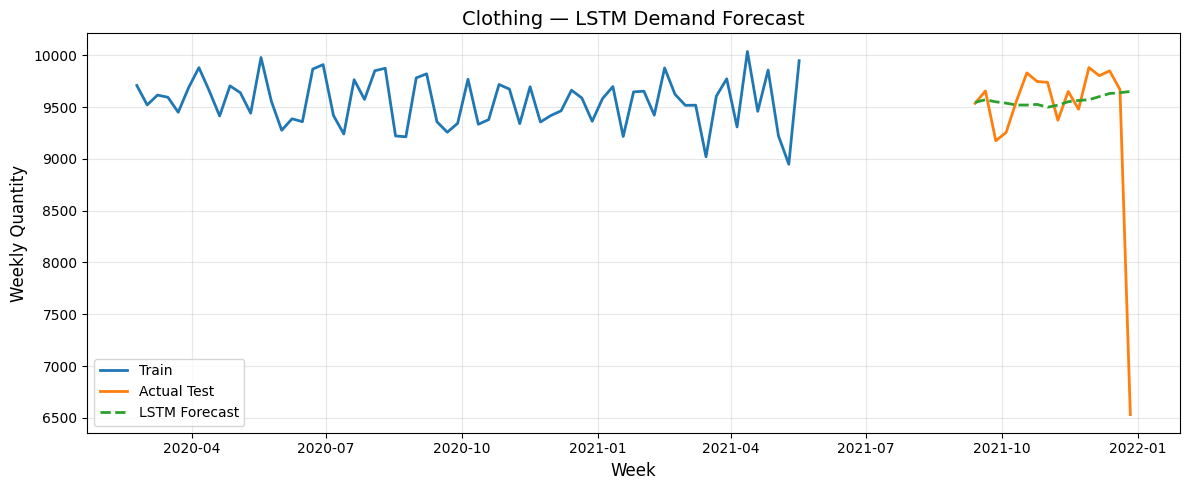


===== Electronics =====
LSTM → RMSE: 617.86 | MAE: 334.20 | sMAPE: 3.73%


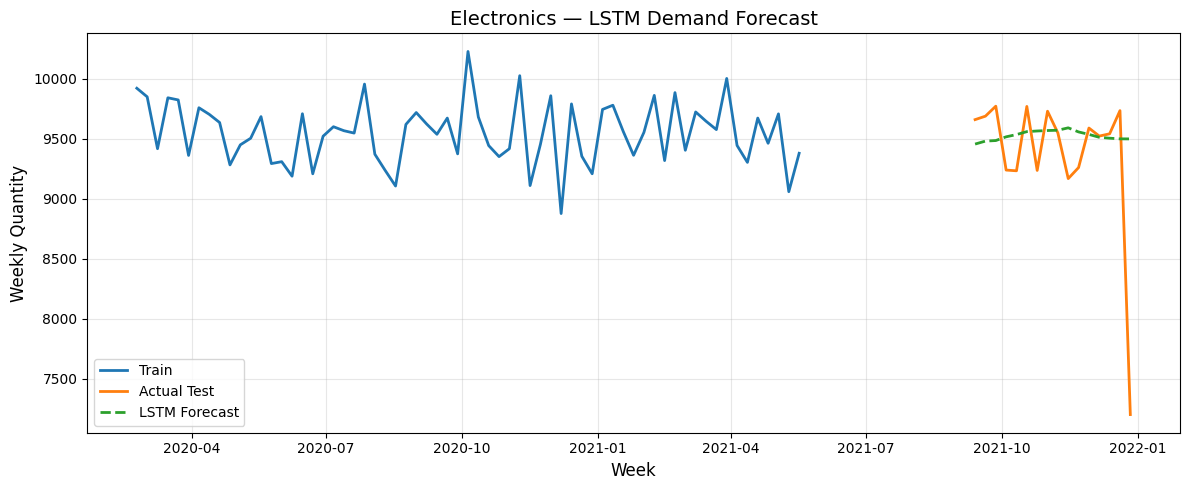


===== Furniture =====
LSTM → RMSE: 699.47 | MAE: 389.57 | sMAPE: 4.39%


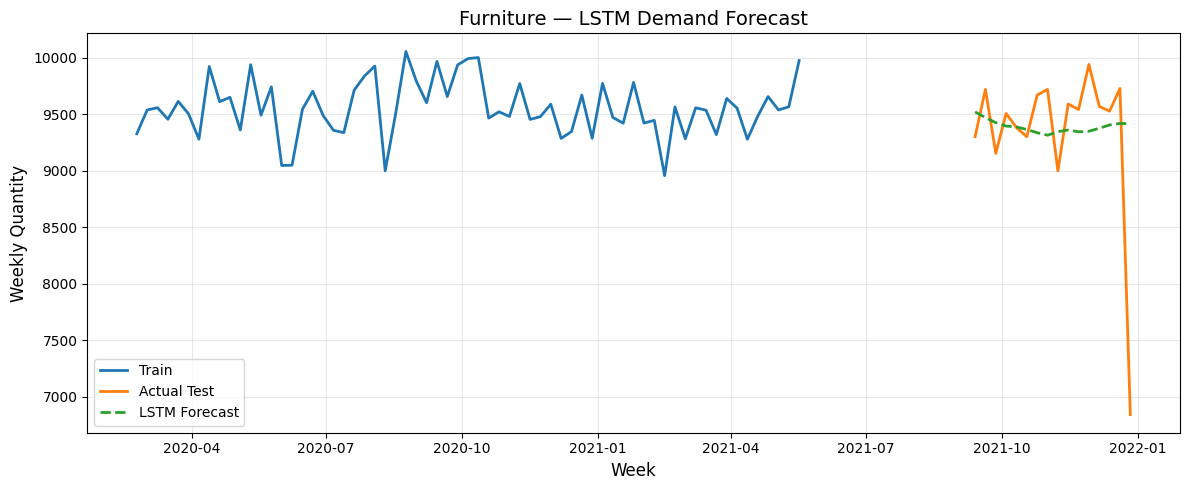


===== Groceries =====
LSTM → RMSE: 617.10 | MAE: 326.68 | sMAPE: 3.62%


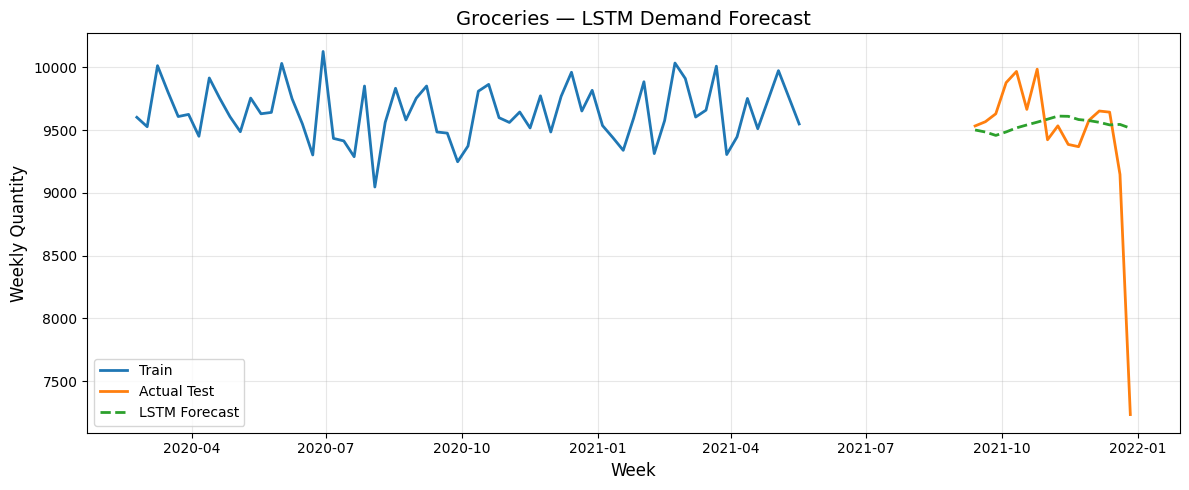


===== Toys =====
LSTM → RMSE: 654.83 | MAE: 364.26 | sMAPE: 4.03%


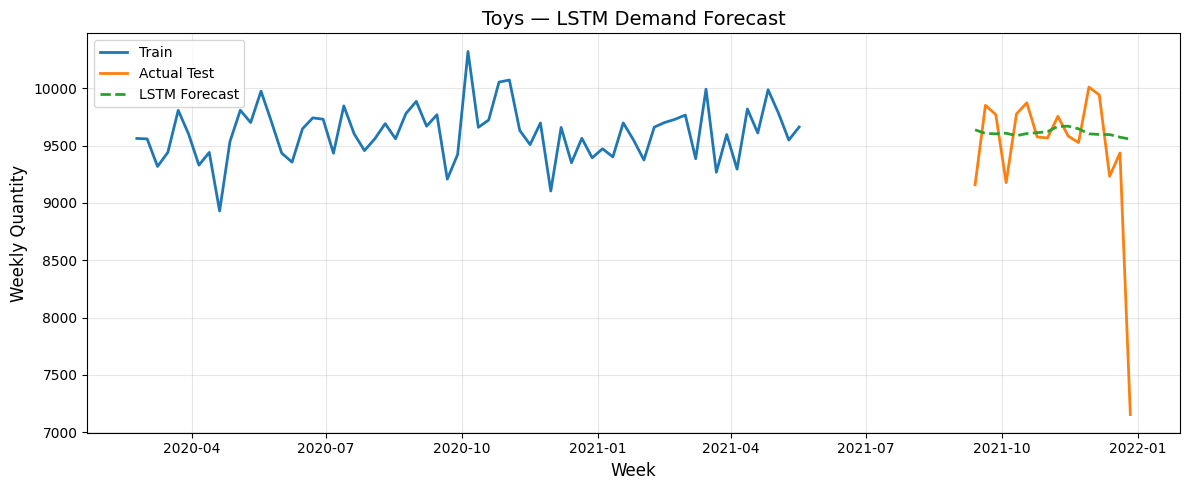


  LSTM — FINAL RESULTS
   Category  LSTM_RMSE  LSTM_MAE  LSTM_sMAPE
   Clothing     806.05    361.03        4.14
Electronics     617.86    334.20        3.73
  Furniture     699.47    389.57        4.39
  Groceries     617.10    326.68        3.62
       Toys     654.83    364.26        4.03

  NEXT 4-WEEK DEMAND FORECAST (LSTM)

Clothing:
      Week  Predicted_Demand
2022-01-03           9381.72
2022-01-10           9275.55
2022-01-17           9172.75
2022-01-24           9062.22

Electronics:
      Week  Predicted_Demand
2022-01-03           9254.44
2022-01-10           9223.43
2022-01-17           9187.64
2022-01-24           9131.16

Furniture:
      Week  Predicted_Demand
2022-01-03           9273.57
2022-01-10           9178.23
2022-01-17           9057.40
2022-01-24           8937.99

Groceries:
      Week  Predicted_Demand
2022-01-03           9284.56
2022-01-10           9214.42
2022-01-17           9147.42
2022-01-24           9078.69

Toys:
      Week  Predicted_Demand
202

In [ ]:
# =========================================
# INDEPENDENT DEEP LEARNING MODEL: LSTM
# REPORT-SAFE VERSION
# Fixes:
# - train/validation/test split is chronological
# - test set is NOT used for validation or early stopping
# - scaler is fitted on train data only
# - adds sMAPE
# =========================================

import os
# Create or update a DataFrame column for feature engineering or modeling.
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Import pandas to read files, process tabular data, and export CSV results.
import pandas as pd
# Import NumPy for numerical operations, arrays, and metrics.
import numpy as np
# Import Matplotlib to create charts for EDA and reporting.
import matplotlib.pyplot as plt
# Import TensorFlow/Keras to build and train the LSTM model.
import tensorflow as tf
# Import TensorFlow/Keras to build and train the LSTM model.
from tensorflow.keras.models import Sequential
# Import TensorFlow/Keras to build and train the LSTM model.
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
# Import TensorFlow/Keras to build and train the LSTM model.
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# Import TensorFlow/Keras to build and train the LSTM model.
from tensorflow.keras.optimizers import Adam
# Import scikit-learn tools for splitting, scaling, evaluation, or modeling.
from sklearn.preprocessing import MinMaxScaler
# Import scikit-learn tools for splitting, scaling, evaluation, or modeling.
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Hide non-critical warnings to keep the notebook output cleaner.
import warnings

# Hide non-critical warnings to keep the notebook output cleaner.
warnings.filterwarnings("ignore")
tf.get_logger().setLevel('ERROR')

tf.random.set_seed(42)
np.random.seed(42)

# Define the `rmse` function to reuse logic and avoid duplicated code.
def rmse(y_true, y_pred):
    # Return the final result so the calling code can use it.
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Define the `smape` function to reuse logic and avoid duplicated code.
def smape(y_true, y_pred):
    # Assign the calculated result to a variable for use in later steps.
    y_true = np.asarray(y_true, dtype=float)
    # Assign the calculated result to a variable for use in later steps.
    y_pred = np.asarray(y_pred, dtype=float)
    # Return the final result so the calling code can use it.
    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    )

# =========================================
# 1. LOAD + WEEKLY AGGREGATION
# =========================================
# Read the CSV file into a DataFrame to start data processing.
df = pd.read_csv('/content/category_daily_sales_final.csv')
# Convert the date column to datetime so week, month, and year can be extracted correctly.
df['date_only'] = pd.to_datetime(df['date_only'])
# Extract time components such as week, month, year, or day from the datetime column.
df['year_week'] = df['date_only'].dt.to_period('W').dt.to_timestamp()

# Group data by category, product, or time to aggregate demand.
df_weekly = df.groupby(['year_week', 'product_category'], as_index=False).agg({
    'quantity': 'sum',
    'unit_price': 'mean',
    'discount_applied': 'mean',
    'product_rating': 'mean',
    'product_stock': 'mean',
    'is_holiday': 'mean',  # FIX: holiday rate; sum/>0 becomes almost always constant
    'is_weekend_derived': 'sum',
    'total_returned_items': 'sum'
}).sort_values('year_week')

# Define constants or configuration values used multiple times in this cell.
SEQUENCE_COLS = [
    'quantity', 'unit_price', 'discount_applied',
    'product_rating', 'product_stock',
    'is_holiday', 'is_weekend_derived', 'total_returned_items'
]

# Define the historical sequence length used as input for the LSTM.
SEQ_LEN = 8
# Define the number of future weeks to forecast for inventory optimization.
FORECAST_WEEKS = 4
# Assign the calculated result to a variable for use in later steps.
categories = ['Clothing', 'Electronics', 'Furniture', 'Groceries', 'Toys']

# =========================================
# 2. HELPERS
# =========================================
# Define the `build_sequences` function to reuse logic and avoid duplicated code.
def build_sequences(data, seq_len):
    # Assign the calculated result to a variable for use in later steps.
    X, y = [], []
    # Loop through each item, category, or week for step-by-step processing or forecasting.
    for i in range(len(data) - seq_len):
        # Append a new result to the list for aggregation after the loop.
        X.append(data[i:i + seq_len])
        # Append a new result to the list for aggregation after the loop.
        y.append(data[i + seq_len, 0])  # target = quantity, column 0
    # Return the final result so the calling code can use it.
    return np.array(X), np.array(y)

# Define the `build_lstm_model` function to reuse logic and avoid duplicated code.
def build_lstm_model(seq_len, n_features):
    # Build an LSTM or deep learning layer for time-series data.
    model = Sequential([
        # Assign the calculated result to a variable for use in later steps.
        Input(shape=(seq_len, n_features)),
        # Build an LSTM or deep learning layer for time-series data.
        LSTM(64, return_sequences=True),
        # Build an LSTM or deep learning layer for time-series data.
        Dropout(0.2),
        # Build an LSTM or deep learning layer for time-series data.
        LSTM(32),
        # Build an LSTM or deep learning layer for time-series data.
        Dropout(0.2),
        # Build an LSTM or deep learning layer for time-series data.
        Dense(16, activation='relu'),
        # Build an LSTM or deep learning layer for time-series data.
        Dense(1)
    ])

    # Compile the deep learning model with the optimizer and loss function.
    model.compile(
        # Assign the calculated result to a variable for use in later steps.
        optimizer=Adam(learning_rate=0.001),
        # Assign the calculated result to a variable for use in later steps.
        loss='mse'
    )
    # Return the final result so the calling code can use it.
    return model

# Define the `inverse_quantity` function to reuse logic and avoid duplicated code.
def inverse_quantity(scaled_qty, scaler, ref_row):
    # Assign the calculated result to a variable for use in later steps.
    dummy = np.tile(ref_row, (len(scaled_qty), 1))
    # Create or update a DataFrame column for feature engineering or modeling.
    dummy[:, 0] = scaled_qty
    # Return the final result so the calling code can use it.
    return scaler.inverse_transform(dummy)[:, 0]

# =========================================
# 3. TRAIN + EVALUATE
# =========================================
# Assign the calculated result to a variable for use in later steps.
lstm_results = []
# Assign the calculated result to a variable for use in later steps.
lstm_forecasts = {}

# Loop through each item, category, or week for step-by-step processing or forecasting.
for cat in categories:
    # Print information to monitor progress and verify the result.
    print(f"\n===== {cat} =====")

    # Create a copy of the DataFrame so modifications do not affect the original data.
    df_cat = df_weekly[df_weekly['product_category'] == cat].copy()
    # Assign the calculated result to a variable for use in later steps.
    df_cat = df_cat.set_index('year_week').sort_index()
    # Convert data types so columns have the correct format for modeling or calculations.
    data_raw = df_cat[SEQUENCE_COLS].values.astype(float)

    # Assign the calculated result to a variable for use in later steps.
    n = len(data_raw)
    # Assign the calculated result to a variable for use in later steps.
    train_end = int(n * 0.70)
    # Assign the calculated result to a variable for use in later steps.
    val_end   = int(n * 0.85)

    # Assign the calculated result to a variable for use in later steps.
    train_raw = data_raw[:train_end]
    # Assign the calculated result to a variable for use in later steps.
    val_raw   = data_raw[train_end - SEQ_LEN:val_end]   # include lookback context
    # Assign the calculated result to a variable for use in later steps.
    test_raw  = data_raw[val_end - SEQ_LEN:]

    # Initialize a scaler to normalize features and make model training more stable.
    scaler = MinMaxScaler()
    # Fit the scaler on the training data and then transform the training data.
    train_sc = scaler.fit_transform(train_raw)
    # Transform validation, test, or future data using the scaler fitted on the training data.
    val_sc   = scaler.transform(val_raw)
    # Transform validation, test, or future data using the scaler fitted on the training data.
    test_sc  = scaler.transform(test_raw)

    # Assign the calculated result to a variable for use in later steps.
    X_train, y_train = build_sequences(train_sc, SEQ_LEN)
    # Assign the calculated result to a variable for use in later steps.
    X_val, y_val     = build_sequences(val_sc,   SEQ_LEN)
    # Assign the calculated result to a variable for use in later steps.
    X_test, y_test   = build_sequences(test_sc,  SEQ_LEN)

    # Check a condition to choose the appropriate processing branch.
    if len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0:
        # Print information to monitor progress and verify the result.
        print(f"Skipped {cat}: not enough data for LSTM split.")
        continue

    # Assign the calculated result to a variable for use in later steps.
    model = build_lstm_model(SEQ_LEN, len(SEQUENCE_COLS))

    # Assign the calculated result to a variable for use in later steps.
    callbacks = [
        # Assign the calculated result to a variable for use in later steps.
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
        # Assign the calculated result to a variable for use in later steps.
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-5)
    ]

    # Train the model or scaler on the prepared dataset.
    model.fit(
        X_train, y_train,
        # Assign the calculated result to a variable for use in later steps.
        validation_data=(X_val, y_val),
        # Assign the calculated result to a variable for use in later steps.
        epochs=150,
        # Assign the calculated result to a variable for use in later steps.
        batch_size=8,
        # Assign the calculated result to a variable for use in later steps.
        callbacks=callbacks,
        # Assign the calculated result to a variable for use in later steps.
        verbose=0
    )

    # Use the trained model to generate forecasts or estimates.
    y_pred_sc = model.predict(X_test, verbose=0).flatten()

    # Assign the calculated result to a variable for use in later steps.
    ref_row = train_sc[-1]
    # Assign the calculated result to a variable for use in later steps.
    y_pred = np.maximum(inverse_quantity(y_pred_sc, scaler, ref_row), 0)
    # Assign the calculated result to a variable for use in later steps.
    y_actual = inverse_quantity(y_test, scaler, ref_row)

    # Assign the calculated result to a variable for use in later steps.
    dates_test = df_cat.index[val_end:]

    # Calculate an evaluation metric for forecast error or model quality.
    model_rmse = rmse(y_actual, y_pred)
    # Calculate an evaluation metric for forecast error or model quality.
    model_mae = mean_absolute_error(y_actual, y_pred)
    # Calculate an evaluation metric for forecast error or model quality.
    model_smape = smape(y_actual, y_pred)

    # Calculate an evaluation metric for forecast error or model quality.
    print(f"LSTM → RMSE: {model_rmse:.2f} | MAE: {model_mae:.2f} | sMAPE: {model_smape:.2f}%")

    # Append a new result to the list for aggregation after the loop.
    lstm_results.append({
        'Category': cat,
        # Calculate an evaluation metric for forecast error or model quality.
        'LSTM_RMSE': round(model_rmse, 2),
        'LSTM_MAE': round(model_mae, 2),
        # Calculate an evaluation metric for forecast error or model quality.
        'LSTM_sMAPE': round(model_smape, 2)
    })

    # Create or update a DataFrame column for feature engineering or modeling.
    lstm_forecasts[cat] = {
        'dates': dates_test,
        'actual': y_actual,
        'forecast': y_pred
    }

    # Assign the calculated result to a variable for use in later steps.
    train_dates = df_cat.index[SEQ_LEN:train_end]
    # Assign the calculated result to a variable for use in later steps.
    y_train_orig = inverse_quantity(y_train, scaler, ref_row)

    # Configure or draw a chart to visualize the data or model results.
    plt.figure(figsize=(12, 5))
    # Configure or draw a chart to visualize the data or model results.
    plt.plot(train_dates, y_train_orig, label='Train')
    # Configure or draw a chart to visualize the data or model results.
    plt.plot(dates_test, y_actual, label='Actual Test')
    # Configure or draw a chart to visualize the data or model results.
    plt.plot(dates_test, y_pred, linestyle='--', label='LSTM Forecast')
    # Configure or draw a chart to visualize the data or model results.
    plt.title(f"{cat} — LSTM Demand Forecast")
    # Configure or draw a chart to visualize the data or model results.
    plt.xlabel("Week")
    # Configure or draw a chart to visualize the data or model results.
    plt.ylabel("Weekly Quantity")
    # Configure or draw a chart to visualize the data or model results.
    plt.legend()
    # Configure or draw a chart to visualize the data or model results.
    plt.grid(alpha=0.3)
    # Configure or draw a chart to visualize the data or model results.
    plt.tight_layout()
    # Save the chart as an image for the report or presentation slides.
    plt.savefig(f"{cat}_lstm_forecast.png", dpi=300, bbox_inches='tight')
    # Display the chart in the notebook for visual inspection.
    plt.show()

# =========================================
# 4. SUMMARY TABLE
# =========================================
# Create a new DataFrame to store intermediate results or output tables.
df_lstm_results = pd.DataFrame(lstm_results)
# Export the result table to a CSV file for the report, inventory, or recommendation module.
df_lstm_results.to_csv('lstm_results.csv', index=False)

# Print information to monitor progress and verify the result.
print("\n" + "=" * 60)
# Print information to monitor progress and verify the result.
print("  LSTM — FINAL RESULTS")
# Print information to monitor progress and verify the result.
print("=" * 60)
# Print information to monitor progress and verify the result.
print(df_lstm_results.to_string(index=False))

# =========================================
# 5. NEXT-4-WEEK FORECAST
# =========================================
# Print information to monitor progress and verify the result.
print("\n" + "=" * 60)
# Print information to monitor progress and verify the result.
print("  NEXT 4-WEEK DEMAND FORECAST (LSTM)")
# Print information to monitor progress and verify the result.
print("=" * 60)

# Assign the calculated result to a variable for use in later steps.
lstm_future_preds = {}

# Loop through each item, category, or week for step-by-step processing or forecasting.
for cat in categories:
    # Create a copy of the DataFrame so modifications do not affect the original data.
    df_cat = df_weekly[df_weekly['product_category'] == cat].copy()
    # Assign the calculated result to a variable for use in later steps.
    df_cat = df_cat.set_index('year_week').sort_index()
    # Convert data types so columns have the correct format for modeling or calculations.
    data_raw = df_cat[SEQUENCE_COLS].values.astype(float)

    # Initialize a scaler to normalize features and make model training more stable.
    scaler = MinMaxScaler()
    # Fit the scaler on the training data and then transform the training data.
    data_sc = scaler.fit_transform(data_raw)
    # Assign the calculated result to a variable for use in later steps.
    X, y = build_sequences(data_sc, SEQ_LEN)

    # Assign the calculated result to a variable for use in later steps.
    model = build_lstm_model(SEQ_LEN, len(SEQUENCE_COLS))
    # Train the model or scaler on the prepared dataset.
    model.fit(
        X, y,
        # Assign the calculated result to a variable for use in later steps.
        epochs=150,
        # Assign the calculated result to a variable for use in later steps.
        batch_size=8,
        # Assign the calculated result to a variable for use in later steps.
        callbacks=[EarlyStopping(monitor='loss', patience=15, restore_best_weights=True)],
        # Assign the calculated result to a variable for use in later steps.
        verbose=0
    )

    # Create a copy of the DataFrame so modifications do not affect the original data.
    window = data_sc[-SEQ_LEN:].copy()
    # Assign the calculated result to a variable for use in later steps.
    future_preds = []
    # Keep LSTM future week labels aligned with the historical weekly anchor.
    # pd.date_range(freq='W') defaults to Sunday, while dt.to_period('W').dt.to_timestamp()
    # uses the start of the weekly period. Adding exact 7-day steps avoids inconsistent labels.
    # Assign the calculated result to a variable for use in later steps.
    last_week = pd.Timestamp(df_cat.index[-1])
    # Assign the calculated result to a variable for use in later steps.
    future_dates = [
        # Assign the calculated result to a variable for use in later steps.
        last_week + pd.Timedelta(weeks=i)
        # Loop through each item, category, or week for step-by-step processing or forecasting.
        for i in range(1, FORECAST_WEEKS + 1)
    ]

    # Assign the calculated result to a variable for use in later steps.
    ref_row = data_sc[-1]

    # Loop through each item, category, or week for step-by-step processing or forecasting.
    for _ in range(FORECAST_WEEKS):
        # Use the trained model to generate forecasts or estimates.
        pred_sc = model.predict(window[np.newaxis, :, :], verbose=0)[0, 0]

        # Create a copy of the DataFrame so modifications do not affect the original data.
        dummy = ref_row.copy()
        # Create or update a DataFrame column for feature engineering or modeling.
        dummy[0] = pred_sc
        # Convert scaled values back to the original demand unit for metrics and reporting.
        pred_val = float(np.maximum(scaler.inverse_transform([dummy])[0, 0], 0))
        # Append a new result to the list for aggregation after the loop.
        future_preds.append(round(pred_val, 2))

        # Create a copy of the DataFrame so modifications do not affect the original data.
        new_step = ref_row.copy()
        # Create or update a DataFrame column for feature engineering or modeling.
        new_step[0] = pred_sc
        # Assign the calculated result to a variable for use in later steps.
        window = np.vstack([window[1:], new_step])

    # Create a new DataFrame to store intermediate results or output tables.
    df_future = pd.DataFrame({
        # Convert the date column to datetime so week, month, and year can be extracted correctly.
        'Week': pd.to_datetime(future_dates).strftime('%Y-%m-%d'),
        'Predicted_Demand': future_preds
    })

    # Create or update a DataFrame column for feature engineering or modeling.
    lstm_future_preds[cat] = df_future

    # Print information to monitor progress and verify the result.
    print(f"\n{cat}:")
    # Print information to monitor progress and verify the result.
    print(df_future.to_string(index=False))


CATEGORY: Clothing
SARIMAX RMSE: 739.816 | MAE: 357.487 | sMAPE: 4.014
HYBRID  RMSE: 756.208 | MAE: 378.835 | sMAPE: 4.226


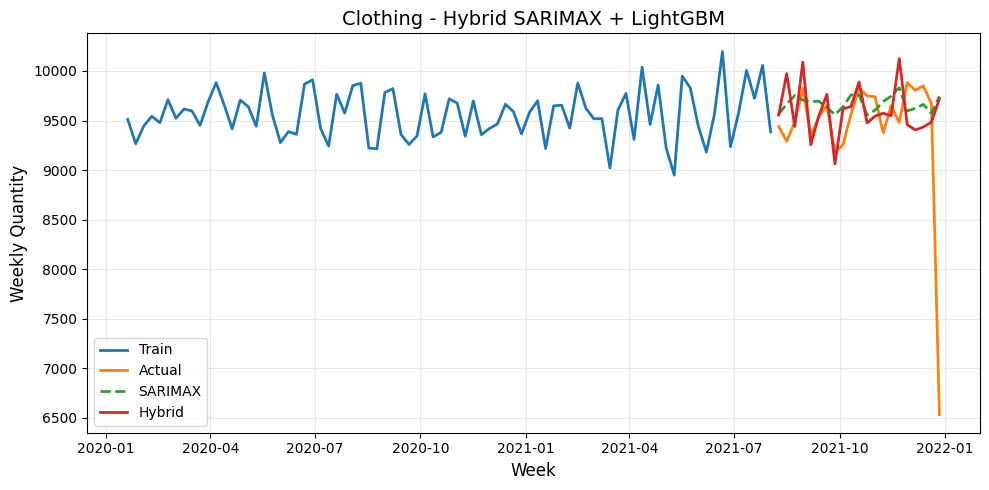


CATEGORY: Electronics
SARIMAX RMSE: 591.93 | MAE: 392.961 | sMAPE: 4.247
HYBRID  RMSE: 884.029 | MAE: 635.892 | sMAPE: 6.731


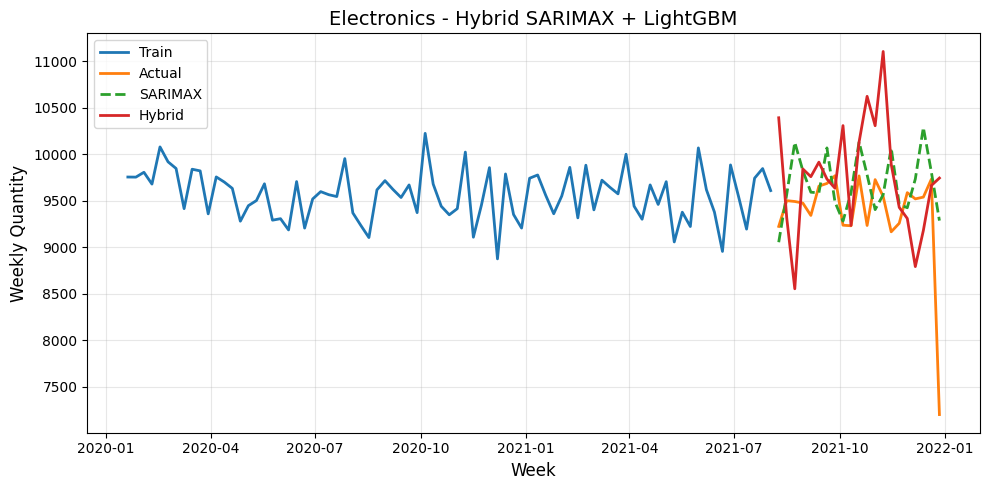


CATEGORY: Furniture
SARIMAX RMSE: 622.552 | MAE: 293.773 | sMAPE: 3.31
HYBRID  RMSE: 628.756 | MAE: 269.52 | sMAPE: 3.049


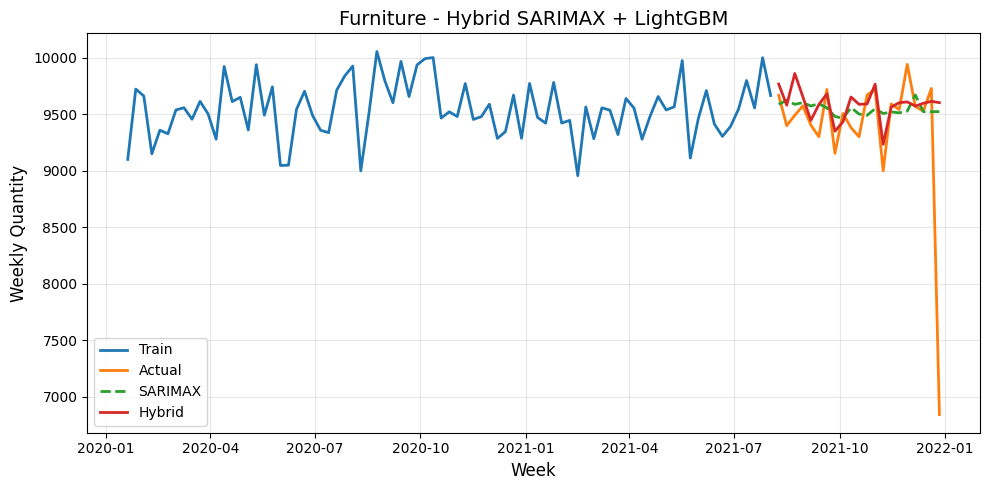


CATEGORY: Groceries
SARIMAX RMSE: 560.327 | MAE: 275.137 | sMAPE: 3.029
HYBRID  RMSE: 555.957 | MAE: 303.485 | sMAPE: 3.323


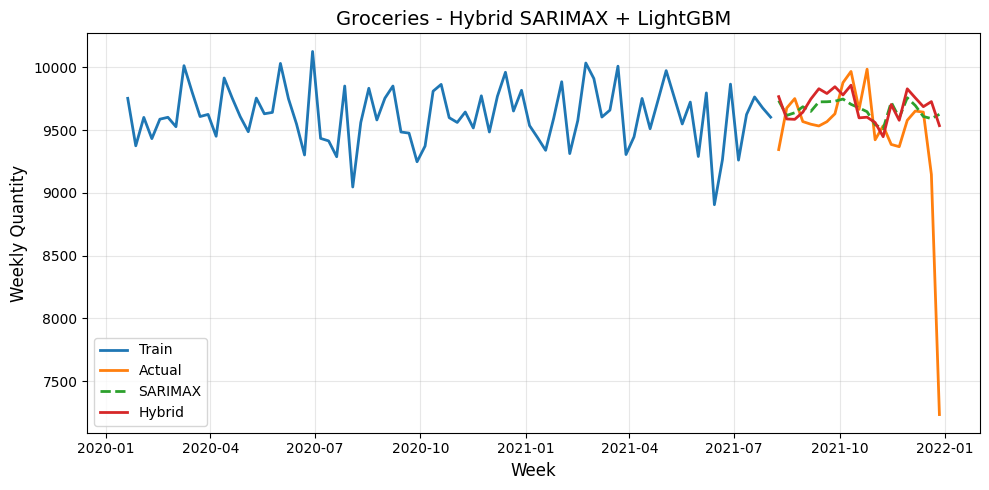


CATEGORY: Toys
SARIMAX RMSE: 589.873 | MAE: 331.55 | sMAPE: 3.63
HYBRID  RMSE: 621.492 | MAE: 330.613 | sMAPE: 3.621


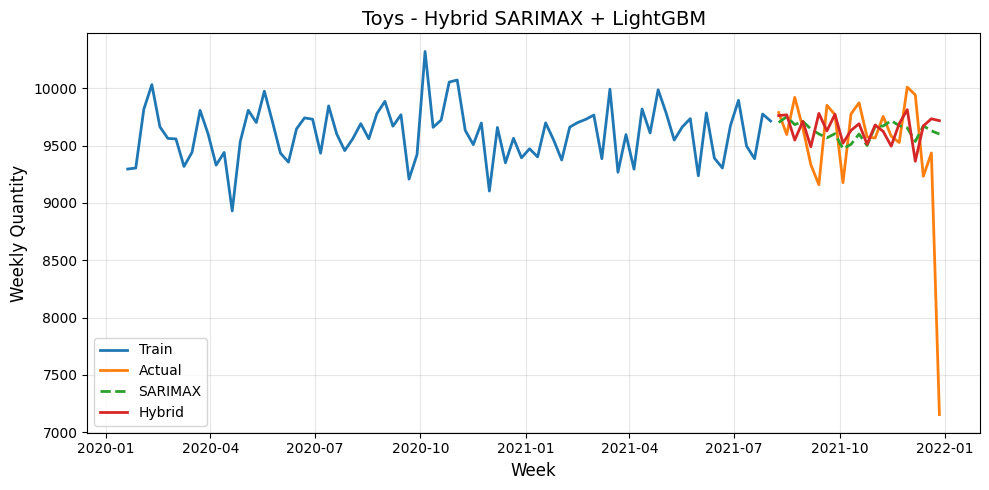


===== FINAL RMSE + MAE + sMAPE (Hybrid) =====
   Category  SARIMAX_RMSE  SARIMAX_MAE  SARIMAX_sMAPE  HYBRID_RMSE  HYBRID_MAE  HYBRID_sMAPE
   Clothing       739.816      357.487          4.014      756.208     378.835         4.226
Electronics       591.930      392.961          4.247      884.029     635.892         6.731
  Furniture       622.552      293.773          3.310      628.756     269.520         3.049
  Groceries       560.327      275.137          3.029      555.957     303.485         3.323
       Toys       589.873      331.550          3.630      621.492     330.613         3.621


In [ ]:
# =========================================
# HYBRID MODEL
# SARIMAX + LightGBM Residual Learning
# REPORT-SAFE VERSION
# Fixes:
# - rolling features use shift(1) to avoid leakage
# - exogenous scaler is fitted on train only
# - adds sMAPE
# =========================================

# Import pandas to read files, process tabular data, and export CSV results.
import pandas as pd
# Import NumPy for numerical operations, arrays, and metrics.
import numpy as np
# Import Matplotlib to create charts for EDA and reporting.
import matplotlib.pyplot as plt
# Import LightGBM to train a gradient-boosted decision-tree machine learning model.
import lightgbm as lgb
# Import statistical functions or models from statsmodels for tests and SARIMAX.
from statsmodels.tsa.statespace.sarimax import SARIMAX
# Import scikit-learn tools for splitting, scaling, evaluation, or modeling.
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Import scikit-learn tools for splitting, scaling, evaluation, or modeling.
from sklearn.preprocessing import StandardScaler
# Hide non-critical warnings to keep the notebook output cleaner.
import warnings

# Hide non-critical warnings to keep the notebook output cleaner.
warnings.filterwarnings("ignore")

# Define the `rmse` function to reuse logic and avoid duplicated code.
def rmse(y_true, y_pred):
    # Return the final result so the calling code can use it.
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Define the `smape` function to reuse logic and avoid duplicated code.
def smape(y_true, y_pred):
    # Assign the calculated result to a variable for use in later steps.
    y_true = np.asarray(y_true, dtype=float)
    # Assign the calculated result to a variable for use in later steps.
    y_pred = np.asarray(y_pred, dtype=float)
    # Return the final result so the calling code can use it.
    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    )

# Read the CSV file into a DataFrame to start data processing.
df = pd.read_csv('/content/category_daily_sales_final.csv')
# Convert the date column to datetime so week, month, and year can be extracted correctly.
df['date_only'] = pd.to_datetime(df['date_only'])
# Extract time components such as week, month, year, or day from the datetime column.
df['year_week'] = df['date_only'].dt.to_period('W').dt.to_timestamp()

# Group data by category, product, or time to aggregate demand.
df_weekly = df.groupby(
    ['year_week', 'product_category'],
    # Assign the calculated result to a variable for use in later steps.
    as_index=False
).agg({
    'quantity': 'sum',
    'unit_price': 'mean',
    'discount_applied': 'mean',
    'is_holiday': 'mean',  # FIX: holiday rate; sum/>0 becomes almost always constant
}).sort_values('year_week')

# =========================================
# FEATURE FUNCTIONS
# =========================================
# Define the `create_sarimax_features` function to reuse logic and avoid duplicated code.
def create_sarimax_features(df):
    # Create a copy of the DataFrame so modifications do not affect the original data.
    df = df.copy()

    # Loop through each item, category, or week for step-by-step processing or forecasting.
    for lag in [1, 2, 3]:
        # Shift historical data to create lag features and avoid target leakage.
        df[f'price_lag{lag}'] = df['unit_price'].shift(lag)
        # Shift historical data to create lag features and avoid target leakage.
        df[f'discount_lag{lag}'] = df['discount_applied'].shift(lag)

    # CRITICAL FIX: shift(1) prevents leakage
    # Shift historical data to create lag features and avoid target leakage.
    df['rolling_mean_3'] = df['quantity'].shift(1).rolling(3).mean()
    # Shift historical data to create lag features and avoid target leakage.
    df['rolling_std_3']  = df['quantity'].shift(1).rolling(3).std()

    # Convert data types so columns have the correct format for modeling or calculations.
    df['holiday_flag'] = df['is_holiday'].astype(float)  # FIX: keep holiday rate, avoid constant binary flag
    # Return the final result so the calling code can use it.
    return df

# Define the `create_lgb_features_hybrid` function to reuse logic and avoid duplicated code.
def create_lgb_features_hybrid(df):
    # Create a copy of the DataFrame so modifications do not affect the original data.
    df = df.copy()
    # Assign the calculated result to a variable for use in later steps.
    date_col = df['year_week']

    # Loop through each item, category, or week for step-by-step processing or forecasting.
    for lag in [1, 2, 3, 4]:
        # Shift historical data to create lag features and avoid target leakage.
        df[f'qty_lag{lag}'] = df['quantity'].shift(lag)

    # CRITICAL FIX: shift(1) prevents leakage
    # Shift historical data to create lag features and avoid target leakage.
    df['rolling_mean_4'] = df['quantity'].shift(1).rolling(4).mean()
    # Shift historical data to create lag features and avoid target leakage.
    df['rolling_std_4']  = df['quantity'].shift(1).rolling(4).std()

    # Convert data types so columns have the correct format for modeling or calculations.
    df['holiday_flag'] = df['is_holiday'].astype(float)  # FIX: keep holiday rate, avoid constant binary flag
    # Extract time components such as week, month, year, or day from the datetime column.
    df['week_of_year'] = date_col.dt.isocalendar().week.astype(int)
    # Extract time components such as week, month, year, or day from the datetime column.
    df['month'] = date_col.dt.month
    # Return the final result so the calling code can use it.
    return df

# Define constants or configuration values used multiple times in this cell.
EXOG_COLS = [
    'price_lag1', 'price_lag2', 'price_lag3',
    'discount_lag1', 'discount_lag2', 'discount_lag3',
    'holiday_flag',
    'rolling_mean_3', 'rolling_std_3'
]

# Define constants or configuration values used multiple times in this cell.
LGB_COLS = [
    'qty_lag1', 'qty_lag2', 'qty_lag3', 'qty_lag4',
    'rolling_mean_4', 'rolling_std_4',
    'holiday_flag',
    'week_of_year', 'month'
]

# =========================================
# BEST SARIMAX MODELS
# =========================================
# Assign the calculated result to a variable for use in later steps.
best_models = {
    'Clothing':    {'order': (2, 0, 3), 'seasonal': (0, 0, 0, 0), 'use_exog': True},
    'Electronics': {'order': (2, 0, 1), 'seasonal': (1, 1, 1, 4), 'use_exog': True},
    'Furniture':  {'order': (2, 0, 3), 'seasonal': (0, 0, 0, 0), 'use_exog': True},
    'Groceries':  {'order': (1, 0, 1), 'seasonal': (0, 0, 0, 0), 'use_exog': True},
    'Toys':       {'order': (1, 0, 3), 'seasonal': (0, 0, 0, 0), 'use_exog': True}
}

# =========================================
# LIGHTGBM PARAMS
# =========================================
# Assign the calculated result to a variable for use in later steps.
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'verbose': -1
}

# =========================================
# TRAIN LOOP - HYBRID
# =========================================
# Assign the calculated result to a variable for use in later steps.
results_hybrid = []
# Assign the calculated result to a variable for use in later steps.
hybrid_test_data = {}

# Loop through each item, category, or week for step-by-step processing or forecasting.
for cat in best_models:
    # Print information to monitor progress and verify the result.
    print("\n========================")
    # Print information to monitor progress and verify the result.
    print("CATEGORY:", cat)
    # Print information to monitor progress and verify the result.
    print("========================")

    # Assign the calculated result to a variable for use in later steps.
    cfg = best_models[cat]

    # Create a copy of the DataFrame so modifications do not affect the original data.
    df_cat = df_weekly[df_weekly['product_category'] == cat].copy()
    # Drop missing rows created by lag or rolling features so the model receives valid inputs.
    df_cat = create_sarimax_features(df_cat).dropna()
    # Assign the calculated result to a variable for use in later steps.
    df_cat = df_cat.set_index('year_week').sort_index()

    # Assign the calculated result to a variable for use in later steps.
    y = df_cat['quantity']
    # Assign the calculated result to a variable for use in later steps.
    exog = df_cat[EXOG_COLS]

    # Assign the calculated result to a variable for use in later steps.
    split = int(len(y) * 0.8)

    # Assign the calculated result to a variable for use in later steps.
    y_train = y.iloc[:split]
    # Assign the calculated result to a variable for use in later steps.
    y_test  = y.iloc[split:]

    # Assign the calculated result to a variable for use in later steps.
    exog_train_raw = exog.iloc[:split]
    # Assign the calculated result to a variable for use in later steps.
    exog_test_raw  = exog.iloc[split:]

    # CRITICAL FIX: fit scaler on train only
    # Initialize a scaler to normalize features and make model training more stable.
    scaler = StandardScaler()
    # Create a new DataFrame to store intermediate results or output tables.
    exog_train = pd.DataFrame(
        # Fit the scaler on the training data and then transform the training data.
        scaler.fit_transform(exog_train_raw),
        # Assign the calculated result to a variable for use in later steps.
        index=exog_train_raw.index,
        # Assign the calculated result to a variable for use in later steps.
        columns=exog_train_raw.columns
    )
    # Create a new DataFrame to store intermediate results or output tables.
    exog_test = pd.DataFrame(
        # Transform validation, test, or future data using the scaler fitted on the training data.
        scaler.transform(exog_test_raw),
        # Assign the calculated result to a variable for use in later steps.
        index=exog_test_raw.index,
        # Assign the calculated result to a variable for use in later steps.
        columns=exog_test_raw.columns
    )

    # Initialize the SARIMAX model to learn trend, autocorrelation, and exogenous effects.
    sarimax = SARIMAX(
        y_train,
        # Assign the calculated result to a variable for use in later steps.
        exog=exog_train if cfg['use_exog'] else None,
        # Assign the calculated result to a variable for use in later steps.
        order=cfg['order'],
        # Assign the calculated result to a variable for use in later steps.
        seasonal_order=cfg['seasonal'],
        # Assign the calculated result to a variable for use in later steps.
        enforce_stationarity=False,
        # Assign the calculated result to a variable for use in later steps.
        enforce_invertibility=False
    ).fit(disp=False)

    # Use the trained model to generate forecasts or estimates.
    sarimax_fc = sarimax.forecast(
        # Assign the calculated result to a variable for use in later steps.
        steps=len(y_test),
        # Assign the calculated result to a variable for use in later steps.
        exog=exog_test if cfg['use_exog'] else None
    )

    # Calculate an evaluation metric for forecast error or model quality.
    rmse_sarimax = rmse(y_test, sarimax_fc)
    # Calculate an evaluation metric for forecast error or model quality.
    mae_sarimax = mean_absolute_error(y_test, sarimax_fc)
    # Calculate an evaluation metric for forecast error or model quality.
    smape_sarimax = smape(y_test, sarimax_fc)

    # Assign the calculated result to a variable for use in later steps.
    residual_train = y_train - sarimax.fittedvalues

    # Prepare LightGBM data for residual learning
    # Create a copy of the DataFrame so modifications do not affect the original data.
    df_lgb = df_weekly[df_weekly['product_category'] == cat].copy()
    # Drop missing rows created by lag or rolling features so the model receives valid inputs.
    df_lgb = create_lgb_features_hybrid(df_lgb).dropna()
    # Assign the calculated result to a variable for use in later steps.
    df_lgb = df_lgb.set_index('year_week').sort_index()

    # Define constants or configuration values used multiple times in this cell.
    X = df_lgb[LGB_COLS]

    # Assign the calculated result to a variable for use in later steps.
    common_index = X.index.intersection(residual_train.index)
    # Assign the calculated result to a variable for use in later steps.
    X_train = X.loc[common_index]
    # Assign the calculated result to a variable for use in later steps.
    y_res_train = residual_train.loc[common_index]
    # Assign the calculated result to a variable for use in later steps.
    X_test = X.loc[y_test.index]

    # Train the LightGBM model using the defined parameters and validation set.
    lgb_model = lgb.train(
        lgb_params,
        # Convert the data into the Dataset format optimized for LightGBM.
        lgb.Dataset(X_train, label=y_res_train),
        # Assign the calculated result to a variable for use in later steps.
        num_boost_round=300
    )

    # Use the trained model to generate forecasts or estimates.
    residual_pred = lgb_model.predict(X_test)

    # Assign the calculated result to a variable for use in later steps.
    min_len = min(len(sarimax_fc), len(residual_pred))
    # Assign the calculated result to a variable for use in later steps.
    sarimax_fc = sarimax_fc.iloc[:min_len]
    # Assign the calculated result to a variable for use in later steps.
    residual_pred = residual_pred[:min_len]
    # Assign the calculated result to a variable for use in later steps.
    y_test_aligned = y_test.iloc[:min_len]

    # Assign the calculated result to a variable for use in later steps.
    hybrid_fc = np.maximum(sarimax_fc.values + residual_pred, 0)

    # Calculate an evaluation metric for forecast error or model quality.
    rmse_hybrid = rmse(y_test_aligned, hybrid_fc)
    # Calculate an evaluation metric for forecast error or model quality.
    mae_hybrid = mean_absolute_error(y_test_aligned, hybrid_fc)
    # Calculate an evaluation metric for forecast error or model quality.
    smape_hybrid = smape(y_test_aligned, hybrid_fc)

    # Calculate an evaluation metric for forecast error or model quality.
    print("SARIMAX RMSE:", round(rmse_sarimax, 3),
          "| MAE:", round(mae_sarimax, 3),
          # Calculate an evaluation metric for forecast error or model quality.
          "| sMAPE:", round(smape_sarimax, 3))
    # Calculate an evaluation metric for forecast error or model quality.
    print("HYBRID  RMSE:", round(rmse_hybrid, 3),
          "| MAE:", round(mae_hybrid, 3),
          # Calculate an evaluation metric for forecast error or model quality.
          "| sMAPE:", round(smape_hybrid, 3))

    # Append a new result to the list for aggregation after the loop.
    results_hybrid.append({
        'Category': cat,
        # Calculate an evaluation metric for forecast error or model quality.
        'SARIMAX_RMSE': round(rmse_sarimax, 3),
        'SARIMAX_MAE': round(mae_sarimax, 3),
        # Calculate an evaluation metric for forecast error or model quality.
        'SARIMAX_sMAPE': round(smape_sarimax, 3),
        # Calculate an evaluation metric for forecast error or model quality.
        'HYBRID_RMSE': round(rmse_hybrid, 3),
        'HYBRID_MAE': round(mae_hybrid, 3),
        # Calculate an evaluation metric for forecast error or model quality.
        'HYBRID_sMAPE': round(smape_hybrid, 3)
    })

    # Create or update a DataFrame column for feature engineering or modeling.
    hybrid_test_data[cat] = {
        'dates': y_test_aligned.index,
        'actual': y_test_aligned.values,
        'forecast': hybrid_fc
    }

    # Configure or draw a chart to visualize the data or model results.
    plt.figure(figsize=(10, 5))
    # Configure or draw a chart to visualize the data or model results.
    plt.plot(y_train.index, y_train, label='Train')
    # Configure or draw a chart to visualize the data or model results.
    plt.plot(y_test_aligned.index, y_test_aligned, label='Actual')
    # Configure or draw a chart to visualize the data or model results.
    plt.plot(y_test_aligned.index, sarimax_fc, '--', label='SARIMAX')
    # Configure or draw a chart to visualize the data or model results.
    plt.plot(y_test_aligned.index, hybrid_fc, label='Hybrid')
    # Configure or draw a chart to visualize the data or model results.
    plt.title(f"{cat} - Hybrid SARIMAX + LightGBM")
    # Configure or draw a chart to visualize the data or model results.
    plt.xlabel("Week")
    # Configure or draw a chart to visualize the data or model results.
    plt.ylabel("Weekly Quantity")
    # Configure or draw a chart to visualize the data or model results.
    plt.legend()
    # Configure or draw a chart to visualize the data or model results.
    plt.grid()
    # Configure or draw a chart to visualize the data or model results.
    plt.tight_layout()
    # Save the chart as an image for the report or presentation slides.
    plt.savefig(f"{cat}_hybrid_forecast.png", dpi=300, bbox_inches='tight')
    # Display the chart in the notebook for visual inspection.
    plt.show()

# =========================================
# FINAL RESULT - HYBRID
# =========================================
# Create a new DataFrame to store intermediate results or output tables.
df_hybrid = pd.DataFrame(results_hybrid)
# Export the result table to a CSV file for the report, inventory, or recommendation module.
df_hybrid.to_csv('hybrid_results.csv', index=False)

# Calculate an evaluation metric for forecast error or model quality.
print("\n===== FINAL RMSE + MAE + sMAPE (Hybrid) =====")
# Print information to monitor progress and verify the result.
print(df_hybrid.to_string(index=False))


  MODEL COMPARISON: SARIMA-family vs LightGBM vs LSTM vs Hybrid

[FULL COMPARISON TABLE]
   Category  SARIMA_family_RMSE  SARIMA_family_MAE  SARIMA_family_sMAPE  LGB_RMSE  LGB_MAE  LGB_sMAPE  Naive_RMSE  MA4_RMSE  LSTM_RMSE  LSTM_MAE  LSTM_sMAPE  HYBRID_RMSE  HYBRID_MAE  HYBRID_sMAPE
   Clothing              700.83             356.67                 4.01    784.40   364.52       4.18      820.08    849.14     806.05    361.03        4.14      756.208     378.835         4.226
Electronics              529.60             339.00                 3.72    626.84   319.25       3.57      704.73    648.88     617.86    334.20        3.73      884.029     635.892         6.731
  Furniture              622.20             293.80                 3.31    715.09   342.31       3.89      804.40    755.21     699.47    389.57        4.39      628.756     269.520         3.049
  Groceries              527.01             286.87                 3.15    637.42   308.19       3.43      534.45    614.11   

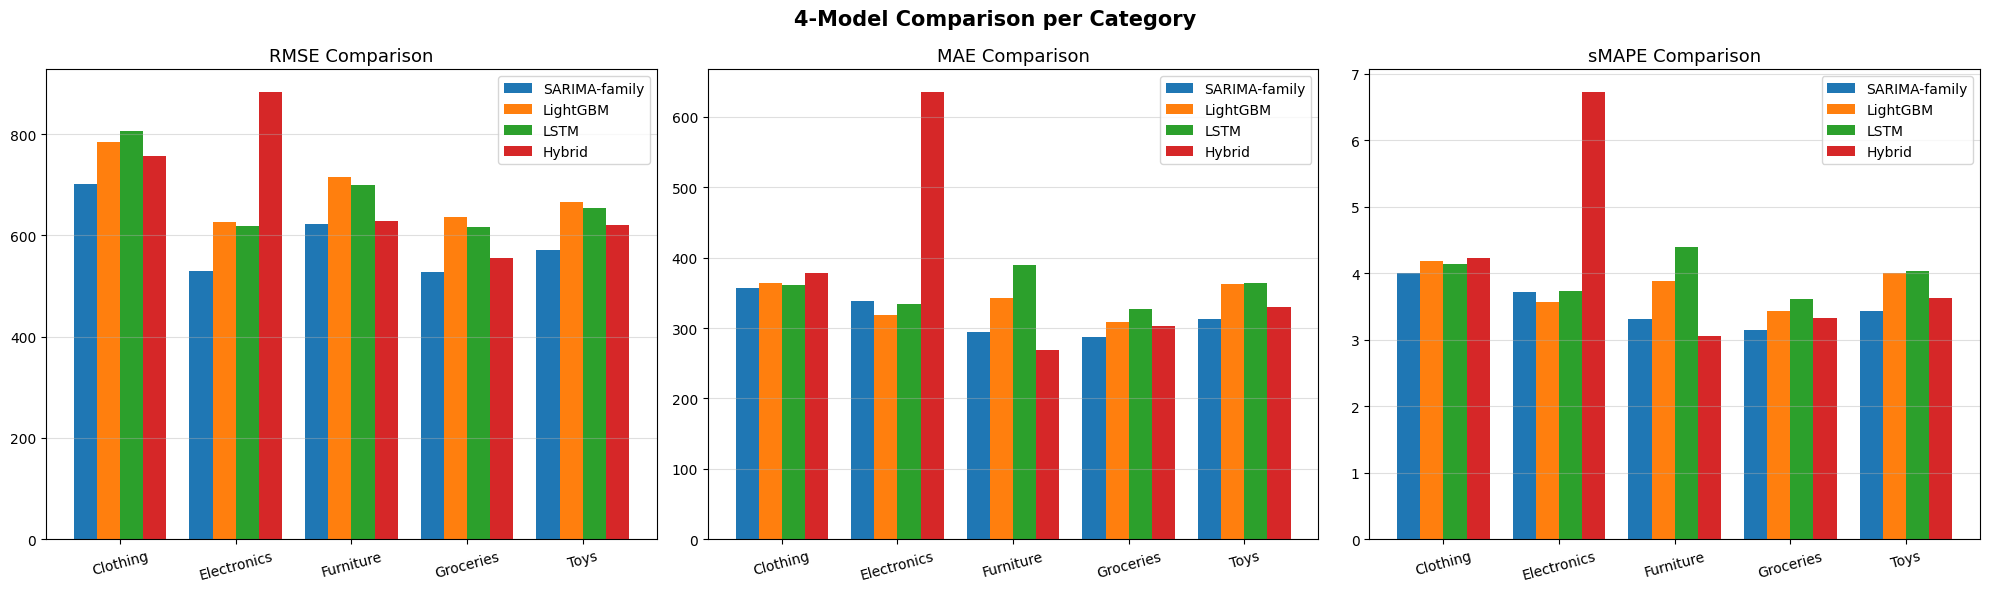


Done. Model comparison, backtest export, and true future forecast export completed.


In [ ]:
# =========================================
# COMPARE 4 MODELS & EXPORT TRUE FUTURE FORECAST
# REPORT-SAFE VERSION
# Fixes:
# - adds sMAPE to comparison
# - keeps a separate backtest forecast file
# - exports TRUE next-4-week forecast for inventory optimization
# - adds Beat_Naive, metric-agreement notes, and report-ready interpretation
# =========================================

# Import pandas to read files, process tabular data, and export CSV results.
import pandas as pd
# Import NumPy for numerical operations, arrays, and metrics.
import numpy as np
# Import Matplotlib to create charts for EDA and reporting.
import matplotlib.pyplot as plt
# Import scikit-learn tools for splitting, scaling, evaluation, or modeling.
from sklearn.preprocessing import StandardScaler
# Import scikit-learn tools for splitting, scaling, evaluation, or modeling.
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Import statistical functions or models from statsmodels for tests and SARIMAX.
from statsmodels.tsa.statespace.sarimax import SARIMAX
# Import LightGBM to train a gradient-boosted decision-tree machine learning model.
import lightgbm as lgb
# Hide non-critical warnings to keep the notebook output cleaner.
import warnings

# Hide non-critical warnings to keep the notebook output cleaner.
warnings.filterwarnings("ignore")

# Define the number of future weeks to forecast for inventory optimization.
FORECAST_HORIZON = 4

# Define the `rmse` function to reuse logic and avoid duplicated code.
def rmse(y_true, y_pred):
    # Return the final result so the calling code can use it.
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Define the `smape` function to reuse logic and avoid duplicated code.
def smape(y_true, y_pred):
    # Assign the calculated result to a variable for use in later steps.
    y_true = np.asarray(y_true, dtype=float)
    # Assign the calculated result to a variable for use in later steps.
    y_pred = np.asarray(y_pred, dtype=float)
    # Return the final result so the calling code can use it.
    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    )

# Print information to monitor progress and verify the result.
print("\n" + "=" * 70)
# Print information to monitor progress and verify the result.
print("  MODEL COMPARISON: SARIMA-family vs LightGBM vs LSTM vs Hybrid")
# Print information to monitor progress and verify the result.
print("=" * 70)

# =========================================
# 1. BUILD COMPARISON TABLE
# =========================================
# Assign the calculated result to a variable for use in later steps.
df_sarima_cmp = df_sarima_summary[
    # Calculate an evaluation metric for forecast error or model quality.
    ['Category', 'SARIMA_fam_RMSE', 'SARIMA_fam_MAE', 'SARIMA_fam_sMAPE']
].rename(columns={
    'SARIMA_fam_RMSE': 'SARIMA_family_RMSE',
    'SARIMA_fam_MAE': 'SARIMA_family_MAE',
    'SARIMA_fam_sMAPE': 'SARIMA_family_sMAPE'
})

# Assign the calculated result to a variable for use in later steps.
df_lgb_cmp = result_df_lgb[
    # Calculate an evaluation metric for forecast error or model quality.
    ['Category', 'Test_RMSE', 'Test_MAE', 'Test_sMAPE', 'Naive_RMSE', 'MA4_RMSE']
].rename(columns={
    'Test_RMSE': 'LGB_RMSE',
    'Test_MAE': 'LGB_MAE',
    'Test_sMAPE': 'LGB_sMAPE'
})

# Assign the calculated result to a variable for use in later steps.
df_lstm_cmp = df_lstm_results[
    # Calculate an evaluation metric for forecast error or model quality.
    ['Category', 'LSTM_RMSE', 'LSTM_MAE', 'LSTM_sMAPE']
]

# Assign the calculated result to a variable for use in later steps.
df_hybrid_cmp = df_hybrid[
    # Calculate an evaluation metric for forecast error or model quality.
    ['Category', 'HYBRID_RMSE', 'HYBRID_MAE', 'HYBRID_sMAPE']
]

# Assign the calculated result to a variable for use in later steps.
df_cmp = (
    df_sarima_cmp
    # Merge additional metric or model tables using a common key, usually Category.
    .merge(df_lgb_cmp, on='Category')
    # Merge additional metric or model tables using a common key, usually Category.
    .merge(df_lstm_cmp, on='Category')
    # Merge additional metric or model tables using a common key, usually Category.
    .merge(df_hybrid_cmp, on='Category')
)

# Export the result table to a CSV file for the report, inventory, or recommendation module.
df_cmp.to_csv('model_comparison_table.csv', index=False)

# Print information to monitor progress and verify the result.
print("\n[FULL COMPARISON TABLE]")
# Print information to monitor progress and verify the result.
print(df_cmp.to_string(index=False))

# =========================================
# 2. SELECT WINNER BY RMSE
# =========================================
# Calculate an evaluation metric for forecast error or model quality.
rmse_cols = {
    'SARIMA-family': 'SARIMA_family_RMSE',
    'LightGBM': 'LGB_RMSE',
    'LSTM': 'LSTM_RMSE',
    'Hybrid': 'HYBRID_RMSE'
}

# Assign the calculated result to a variable for use in later steps.
mae_cols = {
    'SARIMA-family': 'SARIMA_family_MAE',
    'LightGBM': 'LGB_MAE',
    'LSTM': 'LSTM_MAE',
    'Hybrid': 'HYBRID_MAE'
}

# Calculate an evaluation metric for forecast error or model quality.
smape_cols = {
    'SARIMA-family': 'SARIMA_family_sMAPE',
    'LightGBM': 'LGB_sMAPE',
    'LSTM': 'LSTM_sMAPE',
    'Hybrid': 'HYBRID_sMAPE'
}

# Assign the calculated result to a variable for use in later steps.
winner_rows = []

# Loop through each item, category, or week for step-by-step processing or forecasting.
for _, row in df_cmp.iterrows():
    # Assign the calculated result to a variable for use in later steps.
    cat = row['Category']

    # Calculate an evaluation metric for forecast error or model quality.
    rmse_vals = {m: row[c] for m, c in rmse_cols.items()}
    # Assign the calculated result to a variable for use in later steps.
    mae_vals = {m: row[c] for m, c in mae_cols.items()}
    # Calculate an evaluation metric for forecast error or model quality.
    smape_vals = {m: row[c] for m, c in smape_cols.items()}

    # Calculate an evaluation metric for forecast error or model quality.
    best_model_rmse = min(rmse_vals, key=rmse_vals.get)
    # Assign the calculated result to a variable for use in later steps.
    best_model_mae = min(mae_vals, key=mae_vals.get)
    # Calculate an evaluation metric for forecast error or model quality.
    best_model_smape = min(smape_vals, key=smape_vals.get)

    # Calculate an evaluation metric for forecast error or model quality.
    naive_rmse = float(row['Naive_RMSE']) if 'Naive_RMSE' in row.index and pd.notna(row['Naive_RMSE']) else np.nan
    # Calculate an evaluation metric for forecast error or model quality.
    best_rmse = float(rmse_vals[best_model_rmse])
    # Calculate an evaluation metric for forecast error or model quality.
    beat_naive = bool(best_rmse < naive_rmse) if np.isfinite(naive_rmse) else None
    # Calculate an evaluation metric for forecast error or model quality.
    rmse_improvement_vs_naive_pct = (
        # Calculate an evaluation metric for forecast error or model quality.
        100 * (naive_rmse - best_rmse) / naive_rmse
        # Check a condition to choose the appropriate processing branch.
        if np.isfinite(naive_rmse) and naive_rmse != 0
        else np.nan
    )

    # Check a condition to choose the appropriate processing branch.
    if best_model_rmse == best_model_mae == best_model_smape:
        # Calculate an evaluation metric for forecast error or model quality.
        metric_agreement = 'RMSE, MAE, and sMAPE select the same model.'
    # Handle the remaining case when the previous conditions are not satisfied.
    else:
        # Assign the calculated result to a variable for use in later steps.
        metric_agreement = (
            # Calculate an evaluation metric for forecast error or model quality.
            f'Metric disagreement: RMSE={best_model_rmse}, '
            # Calculate an evaluation metric for forecast error or model quality.
            f'MAE={best_model_mae}, sMAPE={best_model_smape}. '
            'RMSE is kept as the primary metric because large demand errors are more costly for inventory planning.'
        )

    # Assign the calculated result to a variable for use in later steps.
    baseline_note = (
        # Calculate an evaluation metric for forecast error or model quality.
        f'Best model beats Naive baseline by {rmse_improvement_vs_naive_pct:.2f}% RMSE.'
        # Check a condition to choose the appropriate processing branch.
        if beat_naive
        # Calculate an evaluation metric for forecast error or model quality.
        else 'Naive baseline has lower RMSE than all four main models; discuss this category as a limitation.'
    )

    # Append a new result to the list for aggregation after the loop.
    winner_rows.append({
        'Category': cat,
        # Calculate an evaluation metric for forecast error or model quality.
        'Best_by_RMSE': best_model_rmse,
        # Calculate an evaluation metric for forecast error or model quality.
        'Best_RMSE': best_rmse,
        'Best_by_MAE': best_model_mae,
        'Best_MAE': mae_vals[best_model_mae],
        # Calculate an evaluation metric for forecast error or model quality.
        'Best_by_sMAPE': best_model_smape,
        # Calculate an evaluation metric for forecast error or model quality.
        'Best_sMAPE': smape_vals[best_model_smape],
        # Calculate an evaluation metric for forecast error or model quality.
        'Winner': best_model_rmse,
        # Calculate an evaluation metric for forecast error or model quality.
        'Naive_RMSE': naive_rmse,
        'Beat_Naive': beat_naive,
        # Calculate an evaluation metric for forecast error or model quality.
        'RMSE_Improvement_vs_Naive_%': rmse_improvement_vs_naive_pct,
        'Metric_Agreement_Note': metric_agreement,
        'Baseline_Note': baseline_note
    })

# Create a new DataFrame to store intermediate results or output tables.
df_winners = pd.DataFrame(winner_rows)
# Export the result table to a CSV file for the report, inventory, or recommendation module.
df_winners.to_csv('winner_per_category.csv', index=False)

# Print information to monitor progress and verify the result.
print("\n[WINNER PER CATEGORY]")
# Print information to monitor progress and verify the result.
print(df_winners.to_string(index=False))

# =========================================
# 2B. REPORT-READY MODEL INTERPRETATION NOTES
# =========================================
# These notes are added for the written report and viva defense. They do not
# change training, testing, model selection, or future prediction values.
# Assign the calculated result to a variable for use in later steps.
report_note_rows = []

# Loop through each item, category, or week for step-by-step processing or forecasting.
for _, r in df_winners.iterrows():
    # Assign the calculated result to a variable for use in later steps.
    category_notes = []

    # Append a new result to the list for aggregation after the loop.
    category_notes.append(
        # Calculate an evaluation metric for forecast error or model quality.
        f"Final selected model by RMSE: {r['Winner']} (RMSE={r['Best_RMSE']:.2f})."
    )
    # Append a new result to the list for aggregation after the loop.
    category_notes.append(r['Metric_Agreement_Note'])
    # Append a new result to the list for aggregation after the loop.
    category_notes.append(r['Baseline_Note'])

    # Check a condition to choose the appropriate processing branch.
    if r['Winner'] == 'LightGBM':
        # Append a new result to the list for aggregation after the loop.
        category_notes.append(
            'LightGBM is the selected winner, but overfitting diagnostics should still be checked.'
        )

    # Append a new result to the list for aggregation after the loop.
    report_note_rows.append({
        'Category': r['Category'],
        'Selected_Model_for_Report': r['Winner'],
        # Calculate an evaluation metric for forecast error or model quality.
        'Best_RMSE': round(float(r['Best_RMSE']), 2),
        # Calculate an evaluation metric for forecast error or model quality.
        'Naive_RMSE': round(float(r['Naive_RMSE']), 2) if pd.notna(r['Naive_RMSE']) else np.nan,
        'Beat_Naive': r['Beat_Naive'],
        'Report_Interpretation': ' '.join(category_notes)
    })

# Create a new DataFrame to store intermediate results or output tables.
df_report_notes = pd.DataFrame(report_note_rows)
# Export the result table to a CSV file for the report, inventory, or recommendation module.
df_report_notes.to_csv('report_ready_model_interpretation_notes.csv', index=False)

# Print information to monitor progress and verify the result.
print("\n[REPORT-READY MODEL INTERPRETATION NOTES]")
# Print information to monitor progress and verify the result.
print(df_report_notes.to_string(index=False))

# Print information to monitor progress and verify the result.
print("\n[IMPORTANT REPORT LIMITATIONS]")
# Print information to monitor progress and verify the result.
print("1. SARIMA-family means the best variant among ARIMA, ARIMAX, SARIMA, and SARIMAX, not always pure SARIMA.")
# Calculate an evaluation metric for forecast error or model quality.
print("2. RMSE is used as the primary winner metric because large errors create higher inventory risk.")
# Print information to monitor progress and verify the result.
print("3. Categories where Beat_Naive=False should be discussed honestly as baseline limitations.")
# Print information to monitor progress and verify the result.
print("4. Future fallback changes only the exported future forecast, not the historical backtest winner.")

# =========================================
# 3. EXPORT BACKTEST FORECASTS
# =========================================
# Assign the calculated result to a variable for use in later steps.
backtest_rows = []

# Loop through each item, category, or week for step-by-step processing or forecasting.
for _, w_row in df_winners.iterrows():
    # Assign the calculated result to a variable for use in later steps.
    cat = w_row['Category']
    # Assign the calculated result to a variable for use in later steps.
    winner = w_row['Winner']

    # Check a condition to choose the appropriate processing branch.
    if winner == 'SARIMA-family':
        # Assign the calculated result to a variable for use in later steps.
        d = sarima_test_data[cat]
    # Check an additional condition if the previous condition is not met.
    elif winner == 'LightGBM':
        # Assign the calculated result to a variable for use in later steps.
        d = lgb_test_data[cat]
    # Check an additional condition if the previous condition is not met.
    elif winner == 'LSTM':
        # Assign the calculated result to a variable for use in later steps.
        d = lstm_forecasts[cat]
    # Handle the remaining case when the previous conditions are not satisfied.
    else:
        # Assign the calculated result to a variable for use in later steps.
        d = hybrid_test_data[cat]

    # Loop through each item, category, or week for step-by-step processing or forecasting.
    for dt, act, fc in zip(d['dates'], d['actual'], d['forecast']):
        # Append a new result to the list for aggregation after the loop.
        backtest_rows.append({
            'Category': cat,
            'Week': pd.Timestamp(dt).strftime('%Y-%m-%d'),
            'Actual_Quantity': round(float(act), 2),
            'Forecast_Quantity': round(float(fc), 2),
            'Best_Model': winner,
            'Forecast_Type': 'Backtest'
        })

# Create a new DataFrame to store intermediate results or output tables.
df_backtest_export = pd.DataFrame(backtest_rows)
# Export the result table to a CSV file for the report, inventory, or recommendation module.
df_backtest_export.to_csv('/content/best_model_backtest_forecast.csv', index=False)

# Print information to monitor progress and verify the result.
print("\nBacktest forecast saved to: /content/best_model_backtest_forecast.csv")

# =========================================
# 4. LOAD FULL WEEKLY DATA FOR FUTURE FORECAST
# =========================================
# Read the CSV file into a DataFrame to start data processing.
df_full = pd.read_csv('/content/category_daily_sales_final.csv')
# Convert the date column to datetime so week, month, and year can be extracted correctly.
df_full['date_only'] = pd.to_datetime(df_full['date_only'])
# Extract time components such as week, month, year, or day from the datetime column.
df_full['year_week'] = df_full['date_only'].dt.to_period('W').dt.to_timestamp()

# Group data by category, product, or time to aggregate demand.
df_weekly_full = df_full.groupby(
    ['year_week', 'product_category'],
    # Assign the calculated result to a variable for use in later steps.
    as_index=False
).agg({
    'quantity': 'sum',
    'unit_price': 'mean',
    'discount_applied': 'mean',
    'product_rating': 'mean',
    'product_stock': 'mean',
    'is_holiday': 'mean',  # FIX: holiday rate; sum/>0 becomes almost always constant
    'is_weekend_derived': 'sum',
    'total_returned_items': 'sum'
}).sort_values('year_week')

# =========================================
# 5. FUTURE FORECAST HELPERS
# =========================================
# Define the `future_dates_from_history` function to reuse logic and avoid duplicated code.
def future_dates_from_history(df_cat, horizon=4):
    """Return future weekly timestamps using the same week anchor as the historical data.

    # Assign the calculated result to a variable for use in later steps.
    pd.date_range(freq='W') defaults to Sunday and can shift labels away from the
    # Extract time components such as week, month, year, or day from the datetime column.
    week anchor created by dt.to_period('W').dt.to_timestamp(). This version keeps
    the historical weekly index consistent by adding exact 7-day steps.
    """
    # Assign the calculated result to a variable for use in later steps.
    last_week = pd.Timestamp(df_cat['year_week'].max())
    # Return the final result so the calling code can use it.
    return [last_week + pd.Timedelta(weeks=i) for i in range(1, horizon + 1)]

# Define the `build_future_lgb_features_from_history` function to reuse logic and avoid duplicated code.
def build_future_lgb_features_from_history(df_cat, future_date, qty_history):
    """Build one future LightGBM feature row using past observed/predicted demand."""
    # Sort the data, which is especially important for preserving chronological order.
    hist = df_cat.sort_values('year_week').copy()

    # Define the `lag_value` function to reuse logic and avoid duplicated code.
    def lag_value(values, lag):
        # Return the final result so the calling code can use it.
        return values[-lag] if len(values) >= lag else values[-1]

    # Assign the calculated result to a variable for use in later steps.
    price_hist = hist['unit_price'].tolist()
    # Assign the calculated result to a variable for use in later steps.
    discount_hist = hist['discount_applied'].tolist()

    # Assign the calculated result to a variable for use in later steps.
    row = {
        'qty_lag1': lag_value(qty_history, 1),
        'qty_lag2': lag_value(qty_history, 2),
        'qty_lag4': lag_value(qty_history, 4),
        'price_lag1': lag_value(price_hist, 1),
        'price_lag2': lag_value(price_hist, 2),
        'discount_lag1': lag_value(discount_hist, 1),
        'rolling_mean_4': np.mean(qty_history[-4:]),
        # Create or update a DataFrame column for feature engineering or modeling.
        'rolling_std_4': np.std(qty_history[-4:], ddof=1) if len(qty_history[-4:]) > 1 else 0,
        'holiday_flag': 0,
        'weekend_flag': 0,
        'week_of_year': int(pd.Timestamp(future_date).isocalendar().week),
        'month': pd.Timestamp(future_date).month,
        'quarter': pd.Timestamp(future_date).quarter,
        'product_rating': hist['product_rating'].iloc[-1] if 'product_rating' in hist.columns else 0,
        'product_stock': hist['product_stock'].iloc[-1] if 'product_stock' in hist.columns else 0,
        'total_returned_items': hist['total_returned_items'].iloc[-1] if 'total_returned_items' in hist.columns else 0
    }
    # Return the final result so the calling code can use it.
    return pd.DataFrame([row])[FEATURE_COLS]

# Define the `forecast_future_lightgbm` function to reuse logic and avoid duplicated code.
def forecast_future_lightgbm(cat, horizon=4):
    # Create a copy of the DataFrame so modifications do not affect the original data.
    df_cat = df_weekly_full[df_weekly_full['product_category'] == cat].copy()
    # Drop missing rows created by lag or rolling features so the model receives valid inputs.
    df_feat = create_features_lgb(df_cat).dropna().set_index('year_week').sort_index()

    # Define constants or configuration values used multiple times in this cell.
    X = df_feat[FEATURE_COLS]
    # Assign the calculated result to a variable for use in later steps.
    y = df_feat['quantity']

    # Initialize a scaler to normalize features and make model training more stable.
    scaler = StandardScaler()
    # Fit the scaler on the training data and then transform the training data.
    X_sc = scaler.fit_transform(X)

    # Train the LightGBM model using the defined parameters and validation set.
    model = lgb.train(
        params,
        # Convert the data into the Dataset format optimized for LightGBM.
        lgb.Dataset(X_sc, label=y),
        # Assign the calculated result to a variable for use in later steps.
        num_boost_round=300
    )

    # Sort the data, which is especially important for preserving chronological order.
    qty_history = df_cat.sort_values('year_week')['quantity'].tolist()
    # Assign the calculated result to a variable for use in later steps.
    future_dates = future_dates_from_history(df_cat, horizon)
    # Assign the calculated result to a variable for use in later steps.
    preds = []

    # Loop through each item, category, or week for step-by-step processing or forecasting.
    for dt in future_dates:
        # Assign the calculated result to a variable for use in later steps.
        X_future = build_future_lgb_features_from_history(df_cat, dt, qty_history)
        # Transform validation, test, or future data using the scaler fitted on the training data.
        X_future_sc = scaler.transform(X_future)
        # Use the trained model to generate forecasts or estimates.
        pred = max(float(model.predict(X_future_sc)[0]), 0)
        # Append a new result to the list for aggregation after the loop.
        preds.append(pred)
        # Append a new result to the list for aggregation after the loop.
        qty_history.append(pred)

    # Return the final result so the calling code can use it.
    return future_dates, preds

# Define the `build_future_sarima_exog` function to reuse logic and avoid duplicated code.
def build_future_sarima_exog(df_cat, future_dates, qty_forecast_proxy=None):
    """Approximate future exogenous variables using last known price/discount and rolling demand history."""
    # Sort the data, which is especially important for preserving chronological order.
    hist = df_cat.sort_values('year_week').copy()
    # Assign the calculated result to a variable for use in later steps.
    qty_history = hist['quantity'].tolist()

    # Check a condition to choose the appropriate processing branch.
    if qty_forecast_proxy is not None:
        # Assign the calculated result to a variable for use in later steps.
        qty_history_for_roll = qty_history + list(qty_forecast_proxy)
    # Handle the remaining case when the previous conditions are not satisfied.
    else:
        # Assign the calculated result to a variable for use in later steps.
        qty_history_for_roll = qty_history

    # Assign the calculated result to a variable for use in later steps.
    price_hist = hist['unit_price'].tolist()
    # Assign the calculated result to a variable for use in later steps.
    discount_hist = hist['discount_applied'].tolist()

    # Assign the calculated result to a variable for use in later steps.
    rows = []
    # Loop through each item, category, or week for step-by-step processing or forecasting.
    for i, dt in enumerate(future_dates):
        # use only information available before this future week
        # Assign the calculated result to a variable for use in later steps.
        qhist = qty_history_for_roll[:len(qty_history) + i]
        # Assign the calculated result to a variable for use in later steps.
        qhist = qhist if len(qhist) >= 3 else qty_history

        # Append a new result to the list for aggregation after the loop.
        rows.append({
            'price_lag1': price_hist[-1],
            # Create or update a DataFrame column for feature engineering or modeling.
            'price_lag2': price_hist[-2] if len(price_hist) >= 2 else price_hist[-1],
            # Create or update a DataFrame column for feature engineering or modeling.
            'price_lag3': price_hist[-3] if len(price_hist) >= 3 else price_hist[-1],
            'discount_lag1': discount_hist[-1],
            # Create or update a DataFrame column for feature engineering or modeling.
            'discount_lag2': discount_hist[-2] if len(discount_hist) >= 2 else discount_hist[-1],
            # Create or update a DataFrame column for feature engineering or modeling.
            'discount_lag3': discount_hist[-3] if len(discount_hist) >= 3 else discount_hist[-1],
            'holiday_flag': 0,
            'rolling_mean_3': np.mean(qhist[-3:]),
            # Create or update a DataFrame column for feature engineering or modeling.
            'rolling_std_3': np.std(qhist[-3:], ddof=1) if len(qhist[-3:]) > 1 else 0
        })

    # Return the final result so the calling code can use it.
    return pd.DataFrame(rows, index=future_dates)[EXOG_COLS]

# Define the `resolve_sarima_config` function to reuse logic and avoid duplicated code.
def resolve_sarima_config(cat):
    # Assign the calculated result to a variable for use in later steps.
    best_var = df_sarima_summary.loc[
        # Create or update a DataFrame column for feature engineering or modeling.
        df_sarima_summary['Category'] == cat,
        'Best_Variant'
    ].values[0]

    # Assign the calculated result to a variable for use in later steps.
    p_m, d_m, q_m = manual_params[cat]['order']
    # Assign the calculated result to a variable for use in later steps.
    P_m, D_m, Q_m, s_m = manual_params[cat]['seasonal']

    # For future production forecast, use stable manual structures for manual variants.
    # Auto variants are approximated by re-running parameter search on full data.
    # Return the final result so the calling code can use it.
    return best_var, (p_m, d_m, q_m), (P_m, D_m, Q_m, s_m)

# Define the `forecast_future_sarima` function to reuse logic and avoid duplicated code.
def forecast_future_sarima(cat, horizon=4):
    # Create a copy of the DataFrame so modifications do not affect the original data.
    df_cat_full = df_weekly_full[df_weekly_full['product_category'] == cat].copy()
    # Create a copy of the DataFrame so modifications do not affect the original data.
    df_cat = df_cat_full[['year_week', 'product_category', 'quantity', 'unit_price', 'discount_applied', 'is_holiday']].copy()
    # Drop missing rows created by lag or rolling features so the model receives valid inputs.
    df_feat = create_features(df_cat).dropna().set_index('year_week').sort_index()

    # Assign the calculated result to a variable for use in later steps.
    y = df_feat['quantity']
    # Assign the calculated result to a variable for use in later steps.
    exog_raw = df_feat[EXOG_COLS_SARIMA if 'EXOG_COLS_SARIMA' in globals() else EXOG_COLS]

    # Initialize a scaler to normalize features and make model training more stable.
    scaler = StandardScaler()
    # Create a new DataFrame to store intermediate results or output tables.
    exog_sc = pd.DataFrame(
        # Fit the scaler on the training data and then transform the training data.
        scaler.fit_transform(exog_raw),
        # Assign the calculated result to a variable for use in later steps.
        index=exog_raw.index,
        # Assign the calculated result to a variable for use in later steps.
        columns=exog_raw.columns
    )

    # Assign the calculated result to a variable for use in later steps.
    best_var, manual_order, manual_seasonal = resolve_sarima_config(cat)

    # Check a condition to choose the appropriate processing branch.
    if best_var.endswith('_A'):
        # Assign the calculated result to a variable for use in later steps.
        d = manual_order[1]
        # Define constants or configuration values used multiple times in this cell.
        D = manual_seasonal[1]
        # Assign the calculated result to a variable for use in later steps.
        s = manual_seasonal[3]
        # Assign the calculated result to a variable for use in later steps.
        use_exog = 'X' in best_var
        # Assign the calculated result to a variable for use in later steps.
        pq = find_best_pq(y, exog_sc if use_exog else None, d, D, s)
        # Assign the calculated result to a variable for use in later steps.
        order = (pq[0], d, pq[1])
    # Handle the remaining case when the previous conditions are not satisfied.
    else:
        # Assign the calculated result to a variable for use in later steps.
        use_exog = 'X' in best_var
        # Assign the calculated result to a variable for use in later steps.
        order = manual_order

    # Assign the calculated result to a variable for use in later steps.
    seasonal = manual_seasonal if 'SARIMA' in best_var else (0, 0, 0, 0)

    # Assign the calculated result to a variable for use in later steps.
    future_dates = future_dates_from_history(df_cat_full, horizon)
    # Assign the calculated result to a variable for use in later steps.
    future_exog_raw = build_future_sarima_exog(df_cat_full, future_dates)
    # Create a new DataFrame to store intermediate results or output tables.
    future_exog_sc = pd.DataFrame(
        # Transform validation, test, or future data using the scaler fitted on the training data.
        scaler.transform(future_exog_raw),
        # Assign the calculated result to a variable for use in later steps.
        index=future_exog_raw.index,
        # Assign the calculated result to a variable for use in later steps.
        columns=future_exog_raw.columns
    )

    # Initialize the SARIMAX model to learn trend, autocorrelation, and exogenous effects.
    model = SARIMAX(
        y,
        # Assign the calculated result to a variable for use in later steps.
        exog=exog_sc if use_exog else None,
        # Assign the calculated result to a variable for use in later steps.
        order=order,
        # Assign the calculated result to a variable for use in later steps.
        seasonal_order=seasonal,
        # Assign the calculated result to a variable for use in later steps.
        enforce_stationarity=False,
        # Assign the calculated result to a variable for use in later steps.
        enforce_invertibility=False
    ).fit(disp=False)

    # Use the trained model to generate forecasts or estimates.
    preds = model.forecast(
        # Assign the calculated result to a variable for use in later steps.
        steps=horizon,
        # Assign the calculated result to a variable for use in later steps.
        exog=future_exog_sc if use_exog else None
    )

    # Assign the calculated result to a variable for use in later steps.
    preds = np.maximum(np.asarray(preds), 0)
    # Return the final result so the calling code can use it.
    return future_dates, preds

# Define the `forecast_future_hybrid` function to reuse logic and avoid duplicated code.
def forecast_future_hybrid(cat, horizon=4):
    # Assign the calculated result to a variable for use in later steps.
    cfg = best_models[cat]

    # Create a copy of the DataFrame so modifications do not affect the original data.
    df_cat_full = df_weekly_full[df_weekly_full['product_category'] == cat].copy()
    # Create a copy of the DataFrame so modifications do not affect the original data.
    df_cat = df_cat_full[['year_week', 'product_category', 'quantity', 'unit_price', 'discount_applied', 'is_holiday']].copy()

    # Drop missing rows created by lag or rolling features so the model receives valid inputs.
    df_sar = create_sarimax_features(df_cat).dropna().set_index('year_week').sort_index()
    # Assign the calculated result to a variable for use in later steps.
    y = df_sar['quantity']
    # Assign the calculated result to a variable for use in later steps.
    exog_raw = df_sar[EXOG_COLS]

    # Initialize a scaler to normalize features and make model training more stable.
    scaler = StandardScaler()
    # Create a new DataFrame to store intermediate results or output tables.
    exog_sc = pd.DataFrame(
        # Fit the scaler on the training data and then transform the training data.
        scaler.fit_transform(exog_raw),
        # Assign the calculated result to a variable for use in later steps.
        index=exog_raw.index,
        # Assign the calculated result to a variable for use in later steps.
        columns=exog_raw.columns
    )

    # Base SARIMAX trained on full history
    # Assign the calculated result to a variable for use in later steps.
    future_dates = future_dates_from_history(df_cat_full, horizon)
    # Assign the calculated result to a variable for use in later steps.
    future_exog_raw = build_future_sarima_exog(df_cat_full, future_dates)
    # Create a new DataFrame to store intermediate results or output tables.
    future_exog_sc = pd.DataFrame(
        # Transform validation, test, or future data using the scaler fitted on the training data.
        scaler.transform(future_exog_raw),
        # Assign the calculated result to a variable for use in later steps.
        index=future_exog_raw.index,
        # Assign the calculated result to a variable for use in later steps.
        columns=future_exog_raw.columns
    )

    # Initialize the SARIMAX model to learn trend, autocorrelation, and exogenous effects.
    sarimax = SARIMAX(
        y,
        # Assign the calculated result to a variable for use in later steps.
        exog=exog_sc if cfg['use_exog'] else None,
        # Assign the calculated result to a variable for use in later steps.
        order=cfg['order'],
        # Assign the calculated result to a variable for use in later steps.
        seasonal_order=cfg['seasonal'],
        # Assign the calculated result to a variable for use in later steps.
        enforce_stationarity=False,
        # Assign the calculated result to a variable for use in later steps.
        enforce_invertibility=False
    ).fit(disp=False)

    # Use the trained model to generate forecasts or estimates.
    sarimax_future = np.asarray(sarimax.forecast(
        # Assign the calculated result to a variable for use in later steps.
        steps=horizon,
        # Assign the calculated result to a variable for use in later steps.
        exog=future_exog_sc if cfg['use_exog'] else None
    ))

    # Assign the calculated result to a variable for use in later steps.
    residual_train = y - sarimax.fittedvalues

    # Residual LightGBM
    # Drop missing rows created by lag or rolling features so the model receives valid inputs.
    df_lgb = create_lgb_features_hybrid(df_cat).dropna().set_index('year_week').sort_index()
    # Define constants or configuration values used multiple times in this cell.
    X = df_lgb[LGB_COLS]
    # Assign the calculated result to a variable for use in later steps.
    common_index = X.index.intersection(residual_train.index)

    # Train the LightGBM model using the defined parameters and validation set.
    lgb_model = lgb.train(
        lgb_params,
        # Convert the data into the Dataset format optimized for LightGBM.
        lgb.Dataset(X.loc[common_index], label=residual_train.loc[common_index]),
        # Assign the calculated result to a variable for use in later steps.
        num_boost_round=300
    )

    # Sort the data, which is especially important for preserving chronological order.
    qty_history = df_cat_full.sort_values('year_week')['quantity'].tolist()
    # Assign the calculated result to a variable for use in later steps.
    residual_preds = []

    # Loop through each item, category, or week for step-by-step processing or forecasting.
    for dt, base_pred in zip(future_dates, sarimax_future):
        # Assign the calculated result to a variable for use in later steps.
        X_future = build_future_lgb_features_from_history(
            df_cat_full.assign(
                # Assign the calculated result to a variable for use in later steps.
                product_rating=df_cat_full.get('product_rating', 0),
                # Assign the calculated result to a variable for use in later steps.
                product_stock=df_cat_full.get('product_stock', 0),
                # Assign the calculated result to a variable for use in later steps.
                total_returned_items=df_cat_full.get('total_returned_items', 0)
            ),
            dt,
            qty_history
        )

        # Hybrid residual model uses a smaller column set
        # Rename columns so variable names are clear and consistent in the report.
        X_future_h = X_future.rename(columns={
            'week_of_year': 'week_of_year',
            'month': 'month'
        })
        # Create a new DataFrame to store intermediate results or output tables.
        X_future_h = pd.DataFrame({
            'qty_lag1': X_future['qty_lag1'],
            'qty_lag2': X_future['qty_lag2'],
            # Create or update a DataFrame column for feature engineering or modeling.
            'qty_lag3': qty_history[-3] if len(qty_history) >= 3 else qty_history[-1],
            'qty_lag4': X_future['qty_lag4'],
            'rolling_mean_4': X_future['rolling_mean_4'],
            'rolling_std_4': X_future['rolling_std_4'],
            'holiday_flag': X_future['holiday_flag'],
            'week_of_year': X_future['week_of_year'],
            'month': X_future['month']
        })[LGB_COLS]

        # Use the trained model to generate forecasts or estimates.
        residual_pred = float(lgb_model.predict(X_future_h)[0])
        # Assign the calculated result to a variable for use in later steps.
        final_pred = max(float(base_pred + residual_pred), 0)

        # Append a new result to the list for aggregation after the loop.
        residual_preds.append(residual_pred)
        # Append a new result to the list for aggregation after the loop.
        qty_history.append(final_pred)

    # Assign the calculated result to a variable for use in later steps.
    final_preds = np.maximum(sarimax_future + np.asarray(residual_preds), 0)
    # Return the final result so the calling code can use it.
    return future_dates, final_preds

# =========================================
# 6. EXPORT TRUE FUTURE FORECAST USING WINNING MODEL
# =========================================
# Assign the calculated result to a variable for use in later steps.
future_rows = []

# Define the `diagnose_future_forecast_stability` function to reuse logic and avoid duplicated code.
def diagnose_future_forecast_stability(cat, preds, history_df, low_ratio_threshold=0.30, low_share_threshold=0.50, high_ratio_threshold=2.50, high_share_threshold=0.50):
    """Return whether a future forecast is statistically/plausibly unstable.

    This guardrail is used only for the exported *future inventory input*, not for
    # Calculate an evaluation metric for forecast error or model quality.
    historical backtest model selection. The winner remains selected by RMSE.

    Rules:
    # Assign the calculated result to a variable for use in later steps.
    1. zero_or_negative: at least half of future predictions are <= 0.
    2. too_low_vs_recent_history: at least half of future predictions are below
       30% of the recent 8-week average demand.
    3. too_high_vs_recent_history: at least half of future predictions are above
       250% of the recent 8-week average demand.

    These thresholds are conservative plausibility checks for short-horizon demand
    forecasting. They protect downstream inventory optimization from implausible
    stock recommendations caused by extrapolation outside the training distribution.
    """
    # Assign the calculated result to a variable for use in later steps.
    arr = np.asarray(preds, dtype=float)
    # Check a condition to choose the appropriate processing branch.
    if len(arr) == 0 or np.any(~np.isfinite(arr)):
        # Return the final result so the calling code can use it.
        return True, 'Forecast contained missing, infinite, or empty values.'

    # Sort the data, which is especially important for preserving chronological order.
    hist = history_df[history_df['product_category'] == cat].sort_values('year_week')['quantity'].astype(float)
    # Assign the calculated result to a variable for use in later steps.
    recent_mean = hist.tail(8).mean()
    # Assign the calculated result to a variable for use in later steps.
    recent_median = hist.tail(8).median()

    # Check a condition to choose the appropriate processing branch.
    if not np.isfinite(recent_mean) or recent_mean <= 0:
        # Return the final result so the calling code can use it.
        return False, 'No fallback: recent historical demand mean was not positive, so relative stability rules were skipped.'

    # Assign the calculated result to a variable for use in later steps.
    zero_ratio = np.mean(arr <= 0)
    # Assign the calculated result to a variable for use in later steps.
    too_low_ratio = np.mean(arr < low_ratio_threshold * recent_mean)
    # Assign the calculated result to a variable for use in later steps.
    too_high_ratio = np.mean(arr > high_ratio_threshold * recent_mean)

    # Assign the calculated result to a variable for use in later steps.
    reasons = []
    # Check a condition to choose the appropriate processing branch.
    if zero_ratio >= 0.5:
        # Append a new result to the list for aggregation after the loop.
        reasons.append(f'{zero_ratio:.0%} of predictions were zero/negative')
    # Check a condition to choose the appropriate processing branch.
    if too_low_ratio >= low_share_threshold:
        # Append a new result to the list for aggregation after the loop.
        reasons.append(f'{too_low_ratio:.0%} of predictions were below {low_ratio_threshold:.0%} of recent 8-week mean demand ({recent_mean:.2f})')
    # Check a condition to choose the appropriate processing branch.
    if too_high_ratio >= high_share_threshold:
        # Append a new result to the list for aggregation after the loop.
        reasons.append(f'{too_high_ratio:.0%} of predictions were above {high_ratio_threshold:.0%} of recent 8-week mean demand ({recent_mean:.2f})')

    # Check a condition to choose the appropriate processing branch.
    if reasons:
        # Return the final result so the calling code can use it.
        return True, '; '.join(reasons)

    # Return the final result so the calling code can use it.
    return False, f'No fallback: forecast stayed within plausibility band based on recent mean={recent_mean:.2f}, recent median={recent_median:.2f}.'


# Define the `get_future_forecast_by_winner` function to reuse logic and avoid duplicated code.
def get_future_forecast_by_winner(cat, winner, horizon):
    """Generate future forecast using the selected winning model."""
    # Check a condition to choose the appropriate processing branch.
    if winner == 'SARIMA-family':
        # Return the final result so the calling code can use it.
        return forecast_future_sarima(cat, horizon)
    # Check an additional condition if the previous condition is not met.
    elif winner == 'LightGBM':
        # Return the final result so the calling code can use it.
        return forecast_future_lightgbm(cat, horizon)
    # Check an additional condition if the previous condition is not met.
    elif winner == 'LSTM':
        # Assign the calculated result to a variable for use in later steps.
        df_future = lstm_future_preds[cat]
        # Convert the date column to datetime so week, month, and year can be extracted correctly.
        future_dates = pd.to_datetime(df_future['Week'])
        # Convert data types so columns have the correct format for modeling or calculations.
        preds = df_future['Predicted_Demand'].astype(float).values
        # Return the final result so the calling code can use it.
        return future_dates, preds
    # Handle the remaining case when the previous conditions are not satisfied.
    else:
        # Return the final result so the calling code can use it.
        return forecast_future_hybrid(cat, horizon)


# Assign the calculated result to a variable for use in later steps.
fallback_notes = []

# Loop through each item, category, or week for step-by-step processing or forecasting.
for _, w_row in df_winners.iterrows():
    # Assign the calculated result to a variable for use in later steps.
    cat = w_row['Category']
    # Assign the calculated result to a variable for use in later steps.
    winner = w_row['Winner']
    # Assign the calculated result to a variable for use in later steps.
    original_winner = winner

    # Assign the calculated result to a variable for use in later steps.
    future_dates, preds = get_future_forecast_by_winner(cat, winner, FORECAST_HORIZON)

    # Report-safe fallback:
    # The historical backtest winner remains unchanged. Fallback is used only for
    # the exported TRUE future forecast if the winning model extrapolates implausibly
    # for the next 4 weeks. This is a statistical plausibility guardrail for Step 2
    # inventory optimization, where extreme/near-zero demand would create unrealistic
    # reorder recommendations.
    # Assign the calculated result to a variable for use in later steps.
    is_unstable, stability_reason = diagnose_future_forecast_stability(
        # Assign the calculated result to a variable for use in later steps.
        cat=cat,
        # Assign the calculated result to a variable for use in later steps.
        preds=preds,
        # Assign the calculated result to a variable for use in later steps.
        history_df=df_weekly_full
    )

    # Check a condition to choose the appropriate processing branch.
    if winner != 'LightGBM' and is_unstable:
        # Print information to monitor progress and verify the result.
        print(f"[WARNING] {cat}: unstable future forecast from {winner}. Switching future export to LightGBM fallback. Reason: {stability_reason}")
        # Append a new result to the list for aggregation after the loop.
        fallback_notes.append({
            'Category': cat,
            'Original_Best_Model': winner,
            'Fallback_Model': 'LightGBM',
            'Reason': stability_reason,
            'Decision_Type': 'Future forecast plausibility guardrail; backtest winner unchanged'
        })
        # Assign the calculated result to a variable for use in later steps.
        future_dates, preds = forecast_future_lightgbm(cat, FORECAST_HORIZON)
        # Assign the calculated result to a variable for use in later steps.
        winner = f"{original_winner}_with_LightGBM_Fallback"
    # Handle the remaining case when the previous conditions are not satisfied.
    else:
        # Append a new result to the list for aggregation after the loop.
        fallback_notes.append({
            'Category': cat,
            'Original_Best_Model': winner,
            'Fallback_Model': 'None',
            'Reason': stability_reason,
            'Decision_Type': 'No fallback needed'
        })

    # Assign the calculated result to a variable for use in later steps.
    preds = np.maximum(np.asarray(preds, dtype=float), 0)

    # Loop through each item, category, or week for step-by-step processing or forecasting.
    for dt, pred in zip(future_dates, preds):
        # Append a new result to the list for aggregation after the loop.
        future_rows.append({
            'Category': cat,
            'Week': pd.Timestamp(dt).strftime('%Y-%m-%d'),
            'Forecast_Quantity': round(float(pred), 2),
            'Best_Model': winner,
            'Original_Best_Model': original_winner,
            'Forecast_Type': 'Future'
        })

# Create a new DataFrame to store intermediate results or output tables.
df_future_export = pd.DataFrame(future_rows)
# Create a new DataFrame to store intermediate results or output tables.
df_fallback_notes = pd.DataFrame(fallback_notes)

# This is the file Step 2 should use.
# Define constants or configuration values used multiple times in this cell.
FUTURE_EXPORT_PATH = '/content/best_model_forecast.csv'
# Export the result table to a CSV file for the report, inventory, or recommendation module.
df_future_export.to_csv(FUTURE_EXPORT_PATH, index=False)
# Export the result table to a CSV file for the report, inventory, or recommendation module.
df_future_export.to_csv('/content/future_4week_forecast.csv', index=False)
# Export the result table to a CSV file for the report, inventory, or recommendation module.
df_fallback_notes.to_csv('/content/future_forecast_fallback_notes.csv', index=False)

# Print information to monitor progress and verify the result.
print("\nTRUE future forecast saved to:")
# Print information to monitor progress and verify the result.
print(" - /content/best_model_forecast.csv")
# Print information to monitor progress and verify the result.
print(" - /content/future_4week_forecast.csv")
# Print information to monitor progress and verify the result.
print(" - /content/future_forecast_fallback_notes.csv")
# Print information to monitor progress and verify the result.
print(f"Shape: {df_future_export.shape}")

# Print information to monitor progress and verify the result.
print("\n[FUTURE FORECAST STABILITY / FALLBACK NOTES]")
# Print information to monitor progress and verify the result.
print(df_fallback_notes.to_string(index=False))

# Print information to monitor progress and verify the result.
print("\n[TRUE FUTURE FORECAST PREVIEW]")
# Print information to monitor progress and verify the result.
print(df_future_export.to_string(index=False))

# =========================================
# 7. VISUAL MODEL COMPARISON
# =========================================
# Configure or draw a chart to visualize the data or model results.
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Assign the calculated result to a variable for use in later steps.
x = np.arange(len(df_cmp))
# Assign the calculated result to a variable for use in later steps.
width = 0.2
# Assign the calculated result to a variable for use in later steps.
cats = df_cmp['Category'].tolist()

# Assign the calculated result to a variable for use in later steps.
comparison_specs = [
    # Calculate an evaluation metric for forecast error or model quality.
    (('SARIMA_family_RMSE', 'LGB_RMSE', 'LSTM_RMSE', 'HYBRID_RMSE'), 'RMSE Comparison'),
    (('SARIMA_family_MAE', 'LGB_MAE', 'LSTM_MAE', 'HYBRID_MAE'), 'MAE Comparison'),
    (('SARIMA_family_sMAPE', 'LGB_sMAPE', 'LSTM_sMAPE', 'HYBRID_sMAPE'), 'sMAPE Comparison')
]

# Loop through each item, category, or week for step-by-step processing or forecasting.
for ax, (metric_cols, title) in zip(axes, comparison_specs):
    # Loop through each item, category, or week for step-by-step processing or forecasting.
    for i, (col, label) in enumerate(zip(metric_cols, ['SARIMA-family', 'LightGBM', 'LSTM', 'Hybrid'])):
        # Create or update a DataFrame column for feature engineering or modeling.
        ax.bar(x + i * width, df_cmp[col], width, label=label)

    ax.set_xticks(x + 1.5 * width)
    # Assign the calculated result to a variable for use in later steps.
    ax.set_xticklabels(cats, rotation=15)
    # Assign the calculated result to a variable for use in later steps.
    ax.set_title(title, fontsize=13)
    ax.legend()
    # Assign the calculated result to a variable for use in later steps.
    ax.grid(axis='y', alpha=0.4)

# Configure or draw a chart to visualize the data or model results.
plt.suptitle('4-Model Comparison per Category', fontsize=15, fontweight='bold')
# Configure or draw a chart to visualize the data or model results.
plt.tight_layout()
# Save the chart as an image for the report or presentation slides.
plt.savefig('model_comparison_bar_charts.png', dpi=300, bbox_inches='tight')
# Display the chart in the notebook for visual inspection.
plt.show()

# Print information to monitor progress and verify the result.
print("\nDone. Model comparison, backtest export, and true future forecast export completed.")

In [ ]:

# ============================================================
# REPORT-READY ADDITIONAL MODEL COMPARISON METRICS
# Forecast Accuracy, p-value, R², Directional Sensitivity
# ============================================================
# This section is intentionally designed for a demand forecasting report.
#
# Included:
# - Forecast_Accuracy_% = 100 - sMAPE
# - OLS_P_Value = p-value from actual demand ~ forecast demand
# - R2_Score = standard regression R²
# - Directional_Sensitivity = ability to detect actual demand-increase weeks
# - Normalized_RMSE = RMSE divided by mean actual demand
#
# Excluded from the main table:
# - RMSEA. RMSEA is a SEM/model-fit index, not a valid forecasting metric
#   for SARIMAX, LightGBM, LSTM, or Hybrid time-series regression.
# ============================================================

# Import NumPy for numerical operations, arrays, and metrics.
import numpy as np
# Import pandas to read files, process tabular data, and export CSV results.
import pandas as pd
# Import SciPy for statistical tests or sparse matrix processing.
from scipy import stats
# Import scikit-learn tools for splitting, scaling, evaluation, or modeling.
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define the `forecast_smape` function to reuse logic and avoid duplicated code.
def forecast_smape(y_true, y_pred):
    """Symmetric mean absolute percentage error."""
    # Assign the calculated result to a variable for use in later steps.
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    # Assign the calculated result to a variable for use in later steps.
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)
    # Assign the calculated result to a variable for use in later steps.
    denom = np.abs(y_true) + np.abs(y_pred) + 1e-8
    # Return the final result so the calling code can use it.
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / denom)

# Define the `forecast_accuracy_from_smape` function to reuse logic and avoid duplicated code.
def forecast_accuracy_from_smape(y_true, y_pred):
    """
    Forecasting accuracy adapted from sMAPE.
    A higher value is better. It is clipped at 0 to avoid negative accuracy
    when a model performs very poorly.
    """
    # Calculate an evaluation metric for forecast error or model quality.
    smape_value = forecast_smape(y_true, y_pred)
    # Return the final result so the calling code can use it.
    return max(0, 100 - smape_value), smape_value

# Define the `ols_forecast_p_value` function to reuse logic and avoid duplicated code.
def ols_forecast_p_value(y_true, y_pred):
    """
    # Assign the calculated result to a variable for use in later steps.
    OLS significance test for: actual demand = alpha + beta * forecast demand.
    A small p-value means forecast values have a statistically significant
    linear relationship with actual demand.

    This p-value is used as a supplementary diagnostic, not as the primary
    winner-selection metric.
    """
    # Assign the calculated result to a variable for use in later steps.
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    # Assign the calculated result to a variable for use in later steps.
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)

    # Assign the calculated result to a variable for use in later steps.
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    # Assign the calculated result to a variable for use in later steps.
    y_true = y_true[mask]
    # Assign the calculated result to a variable for use in later steps.
    y_pred = y_pred[mask]

    # Check a condition to choose the appropriate processing branch.
    if len(y_true) < 3 or np.std(y_pred) == 0:
        # Return the final result so the calling code can use it.
        return np.nan

    # Start a try block for code that may raise an exception.
    try:
        # Calculate the p-value for the linear relationship between forecast and actual demand.
        lr = stats.linregress(y_pred, y_true)
        # Return the final result so the calling code can use it.
        return float(lr.pvalue)
    # Handle errors when a file, variable, or model does not exist or a previous step has not run.
    except Exception:
        # Return the final result so the calling code can use it.
        return np.nan

# Define the `normalized_rmse` function to reuse logic and avoid duplicated code.
def normalized_rmse(y_true, y_pred):
    """RMSE divided by mean absolute actual demand. Lower is better."""
    # Assign the calculated result to a variable for use in later steps.
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    # Assign the calculated result to a variable for use in later steps.
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)

    # Assign the calculated result to a variable for use in later steps.
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    # Assign the calculated result to a variable for use in later steps.
    y_true = y_true[mask]
    # Assign the calculated result to a variable for use in later steps.
    y_pred = y_pred[mask]

    # Check a condition to choose the appropriate processing branch.
    if len(y_true) == 0 or np.mean(np.abs(y_true)) == 0:
        # Return the final result so the calling code can use it.
        return np.nan

    # Calculate an evaluation metric for forecast error or model quality.
    rmse_value = np.sqrt(mean_squared_error(y_true, y_pred))
    # Return the final result so the calling code can use it.
    return float(rmse_value / np.mean(np.abs(y_true)))

# Define the `directional_sensitivity` function to reuse logic and avoid duplicated code.
def directional_sensitivity(y_true, y_pred):
    """
    Directional sensitivity for demand forecasting.

    Positive class:
    - actual demand increases compared with the previous actual week.

    Predicted positive:
    - predicted demand is higher than the previous actual week.

    This adapts classification sensitivity to forecasting direction.
    It is useful for inventory planning because detecting demand increases
    helps reduce stockout risk.
    """
    # Assign the calculated result to a variable for use in later steps.
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    # Assign the calculated result to a variable for use in later steps.
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)

    # Assign the calculated result to a variable for use in later steps.
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    # Assign the calculated result to a variable for use in later steps.
    y_true = y_true[mask]
    # Assign the calculated result to a variable for use in later steps.
    y_pred = y_pred[mask]

    # Check a condition to choose the appropriate processing branch.
    if len(y_true) < 2:
        # Return the final result so the calling code can use it.
        return np.nan

    # Assign the calculated result to a variable for use in later steps.
    actual_up = y_true[1:] > y_true[:-1]
    # Assign the calculated result to a variable for use in later steps.
    predicted_up = y_pred[1:] > y_true[:-1]

    # Assign the calculated result to a variable for use in later steps.
    true_positive = np.sum(actual_up & predicted_up)
    # Assign the calculated result to a variable for use in later steps.
    false_negative = np.sum(actual_up & (~predicted_up))

    # Check a condition to choose the appropriate processing branch.
    if (true_positive + false_negative) == 0:
        # Return the final result so the calling code can use it.
        return np.nan

    # Return the final result so the calling code can use it.
    return float(true_positive / (true_positive + false_negative))

# Define the `build_report_metric_rows` function to reuse logic and avoid duplicated code.
def build_report_metric_rows(model_name, test_data_dict):
    # Assign the calculated result to a variable for use in later steps.
    rows = []

    # Loop through each item, category, or week for step-by-step processing or forecasting.
    for cat, data in test_data_dict.items():
        # Assign the calculated result to a variable for use in later steps.
        y_true = np.asarray(data['actual'], dtype=float).reshape(-1)
        # Assign the calculated result to a variable for use in later steps.
        y_pred = np.asarray(data['forecast'], dtype=float).reshape(-1)

        # Align length in case one model returns a slightly different vector size.
        # Assign the calculated result to a variable for use in later steps.
        n = min(len(y_true), len(y_pred))
        # Assign the calculated result to a variable for use in later steps.
        y_true = y_true[:n]
        # Assign the calculated result to a variable for use in later steps.
        y_pred = y_pred[:n]

        # Assign the calculated result to a variable for use in later steps.
        mask = np.isfinite(y_true) & np.isfinite(y_pred)
        # Assign the calculated result to a variable for use in later steps.
        y_true = y_true[mask]
        # Assign the calculated result to a variable for use in later steps.
        y_pred = y_pred[mask]

        # Check a condition to choose the appropriate processing branch.
        if len(y_true) == 0:
            continue

        # Calculate an evaluation metric for forecast error or model quality.
        rmse_value = np.sqrt(mean_squared_error(y_true, y_pred))
        # Calculate an evaluation metric for forecast error or model quality.
        mae_value = mean_absolute_error(y_true, y_pred)
        # Calculate an evaluation metric for forecast error or model quality.
        accuracy_value, smape_value = forecast_accuracy_from_smape(y_true, y_pred)

        # Start a try block for code that may raise an exception.
        try:
            # Calculate an evaluation metric for forecast error or model quality.
            r2_value = r2_score(y_true, y_pred)
        # Handle errors when a file, variable, or model does not exist or a previous step has not run.
        except Exception:
            # Assign the calculated result to a variable for use in later steps.
            r2_value = np.nan

        # Assign the calculated result to a variable for use in later steps.
        p_value = ols_forecast_p_value(y_true, y_pred)
        # Assign the calculated result to a variable for use in later steps.
        sensitivity_value = directional_sensitivity(y_true, y_pred)
        # Calculate an evaluation metric for forecast error or model quality.
        nrmse_value = normalized_rmse(y_true, y_pred)

        # Append a new result to the list for aggregation after the loop.
        rows.append({
            'Category': cat,
            'Model': model_name,
            # Calculate an evaluation metric for forecast error or model quality.
            'RMSE': round(float(rmse_value), 4),
            'MAE': round(float(mae_value), 4),
            # Calculate an evaluation metric for forecast error or model quality.
            'sMAPE_%': round(float(smape_value), 4),
            'Forecast_Accuracy_%': round(float(accuracy_value), 4),
            'R2_Score': round(float(r2_value), 6) if pd.notna(r2_value) else np.nan,
            'OLS_P_Value': round(float(p_value), 6) if pd.notna(p_value) else np.nan,
            'Directional_Sensitivity': round(float(sensitivity_value), 6) if pd.notna(sensitivity_value) else np.nan,
            # Calculate an evaluation metric for forecast error or model quality.
            'Normalized_RMSE': round(float(nrmse_value), 6) if pd.notna(nrmse_value) else np.nan
        })

    # Return the final result so the calling code can use it.
    return rows

# ------------------------------------------------------------
# Collect model test predictions created by previous cells
# ------------------------------------------------------------
# Assign the calculated result to a variable for use in later steps.
report_metric_rows = []

# Assign the calculated result to a variable for use in later steps.
model_sources = {
    'SARIMA-family': 'sarima_test_data',
    'LightGBM': 'lgb_test_data',
    'LSTM': 'lstm_forecasts',
    'Hybrid': 'hybrid_test_data'
}

# Loop through each item, category, or week for step-by-step processing or forecasting.
for model_name, var_name in model_sources.items():
    # Check a condition to choose the appropriate processing branch.
    if var_name in globals():
        report_metric_rows.extend(
            # Call the function to perform the predefined processing or calculation step.
            build_report_metric_rows(model_name, globals()[var_name])
        )
    # Handle the remaining case when the previous conditions are not satisfied.
    else:
        # Print information to monitor progress and verify the result.
        print(f"[WARNING] {var_name} not found. Run the {model_name} model cell first.")

# Create a new DataFrame to store intermediate results or output tables.
df_report_model_metrics = pd.DataFrame(report_metric_rows)

# Check a condition to choose the appropriate processing branch.
if df_report_model_metrics.empty:
    # Stop execution and raise a clear error to avoid using incorrect results.
    raise ValueError(
        "No model prediction data found. Run SARIMA-family, LightGBM, LSTM, and Hybrid cells before this section."
    )

# ------------------------------------------------------------
# Add SARIMA-family residual diagnostic p-value where available
# ------------------------------------------------------------
# Check a condition to choose the appropriate processing branch.
if 'df_sarima_diagnostics' in globals() and not df_sarima_diagnostics.empty:
    # Calculate the p-value for the linear relationship between forecast and actual demand.
    diag_cols = ['Category', 'Ljung_Box_pvalue_lag10']
    # Merge two data tables using common keys to add more information.
    df_report_model_metrics = df_report_model_metrics.merge(
        df_sarima_diagnostics[diag_cols],
        # Assign the calculated result to a variable for use in later steps.
        on='Category',
        # Assign the calculated result to a variable for use in later steps.
        how='left'
    )
    df_report_model_metrics.loc[
        # Create or update a DataFrame column for feature engineering or modeling.
        df_report_model_metrics['Model'] != 'SARIMA-family',
        'Ljung_Box_pvalue_lag10'
    ] = np.nan
# Handle the remaining case when the previous conditions are not satisfied.
else:
    # Calculate the p-value for the linear relationship between forecast and actual demand.
    df_report_model_metrics['Ljung_Box_pvalue_lag10'] = np.nan

# ------------------------------------------------------------
# Report-friendly interpretation columns
# ------------------------------------------------------------
# Create or update a DataFrame column for feature engineering or modeling.
df_report_model_metrics['OLS_P_Value_Interpretation'] = np.where(
    df_report_model_metrics['OLS_P_Value'] < 0.05,
    'Statistically significant forecast-actual relationship at 5% level',
    'Not statistically significant at 5% level'
)

# Create or update a DataFrame column for feature engineering or modeling.
df_report_model_metrics['R2_Interpretation'] = pd.cut(
    df_report_model_metrics['R2_Score'],
    # Assign the calculated result to a variable for use in later steps.
    bins=[-np.inf, 0, 0.3, 0.6, 0.8, np.inf],
    # Assign the calculated result to a variable for use in later steps.
    labels=[
        'Poor / worse than mean baseline',
        'Weak explanatory fit',
        'Moderate explanatory fit',
        'Good explanatory fit',
        'Strong explanatory fit'
    ]
)

# Create or update a DataFrame column for feature engineering or modeling.
df_report_model_metrics['Sensitivity_Interpretation'] = pd.cut(
    df_report_model_metrics['Directional_Sensitivity'],
    # Assign the calculated result to a variable for use in later steps.
    bins=[-np.inf, 0.4, 0.6, 0.8, np.inf],
    # Assign the calculated result to a variable for use in later steps.
    labels=[
        'Weak demand-increase detection',
        'Moderate demand-increase detection',
        'Good demand-increase detection',
        'Strong demand-increase detection'
    ]
)

# Create or update a DataFrame column for feature engineering or modeling.
df_report_model_metrics['Metric_Validity_Note'] = (
    'Forecasting problem: use RMSE, MAE, sMAPE, Forecast Accuracy, R², and directional sensitivity. '
    'RMSEA is excluded because it is a SEM/model-fit metric, not a forecasting metric.'
)

# Column order for clean report export.
# Assign the calculated result to a variable for use in later steps.
ordered_cols = [
    'Category', 'Model',
    'RMSE', 'MAE', 'sMAPE_%', 'Forecast_Accuracy_%',
    'R2_Score', 'OLS_P_Value', 'Directional_Sensitivity',
    'Normalized_RMSE', 'Ljung_Box_pvalue_lag10',
    'OLS_P_Value_Interpretation', 'R2_Interpretation',
    'Sensitivity_Interpretation', 'Metric_Validity_Note'
]
# Assign the calculated result to a variable for use in later steps.
df_report_model_metrics = df_report_model_metrics[ordered_cols]

# ------------------------------------------------------------
# Export report-ready table
# ------------------------------------------------------------
# Export the result table to a CSV file for the report, inventory, or recommendation module.
df_report_model_metrics.to_csv('report_ready_model_comparison_metrics.csv', index=False)

# ------------------------------------------------------------
# Winner summary for report
# The final model selection remains RMSE-based in the main comparison section.
# Extra metrics are supplementary diagnostics.
# ------------------------------------------------------------
# Assign the calculated result to a variable for use in later steps.
summary_rows = []

# Loop through each item, category, or week for step-by-step processing or forecasting.
for cat, group in df_report_model_metrics.groupby('Category'):
    # Assign the calculated result to a variable for use in later steps.
    best_accuracy_row = group.loc[group['Forecast_Accuracy_%'].idxmax()]
    # Assign the calculated result to a variable for use in later steps.
    best_r2_row = group.loc[group['R2_Score'].idxmax()]
    # Calculate an evaluation metric for forecast error or model quality.
    best_nrmse_row = group.loc[group['Normalized_RMSE'].idxmin()]

    # Check a condition to choose the appropriate processing branch.
    if group['Directional_Sensitivity'].notna().any():
        # Assign the calculated result to a variable for use in later steps.
        best_sensitivity_row = group.loc[group['Directional_Sensitivity'].idxmax()]
        # Assign the calculated result to a variable for use in later steps.
        best_sensitivity_model = best_sensitivity_row['Model']
        # Assign the calculated result to a variable for use in later steps.
        best_sensitivity_value = best_sensitivity_row['Directional_Sensitivity']
    # Handle the remaining case when the previous conditions are not satisfied.
    else:
        # Assign the calculated result to a variable for use in later steps.
        best_sensitivity_model = np.nan
        # Assign the calculated result to a variable for use in later steps.
        best_sensitivity_value = np.nan

    # Append a new result to the list for aggregation after the loop.
    summary_rows.append({
        'Category': cat,
        'Best_by_Forecast_Accuracy': best_accuracy_row['Model'],
        'Best_Forecast_Accuracy_%': best_accuracy_row['Forecast_Accuracy_%'],
        'Best_by_R2': best_r2_row['Model'],
        'Best_R2_Score': best_r2_row['R2_Score'],
        # Calculate an evaluation metric for forecast error or model quality.
        'Best_by_Normalized_RMSE': best_nrmse_row['Model'],
        # Calculate an evaluation metric for forecast error or model quality.
        'Best_Normalized_RMSE': best_nrmse_row['Normalized_RMSE'],
        'Best_by_Directional_Sensitivity': best_sensitivity_model,
        'Best_Directional_Sensitivity': best_sensitivity_value,
        'Report_Use_Note': (
            'Use RMSE as the primary winner-selection metric for inventory planning. '
            'Use these extra metrics as supporting evidence and robustness checks.'
        )
    })

# Create a new DataFrame to store intermediate results or output tables.
df_report_metric_summary = pd.DataFrame(summary_rows)
# Export the result table to a CSV file for the report, inventory, or recommendation module.
df_report_metric_summary.to_csv('report_ready_additional_metric_summary.csv', index=False)

# ------------------------------------------------------------
# RMSEA exclusion note for report/viva
# ------------------------------------------------------------
# Create a new DataFrame to store intermediate results or output tables.
df_excluded_metrics_note = pd.DataFrame([{
    'Excluded_Metric': 'RMSEA',
    'Reason': (
        'RMSEA is designed for structural equation modeling and covariance/model-fit analysis. '
        'This project is a demand forecasting regression/time-series problem using SARIMAX, LightGBM, LSTM, and Hybrid models.'
    ),
    'Forecasting_Alternative': (
        'Use RMSE, MAE, sMAPE, Forecast Accuracy, R², Normalized RMSE, and Directional Sensitivity instead.'
    ),
    'Suggested_Report_Sentence': (
        'RMSEA was not used because it is not applicable to forecasting models; therefore, the study evaluates model performance using RMSE, MAE, sMAPE, Forecast Accuracy, R², Normalized RMSE, and Directional Sensitivity.'
    )
}])
# Export the result table to a CSV file for the report, inventory, or recommendation module.
df_excluded_metrics_note.to_csv('excluded_metric_rmsea_note.csv', index=False)

# Print information to monitor progress and verify the result.
print("\n" + "="*110)
# Print information to monitor progress and verify the result.
print("REPORT-READY MODEL COMPARISON METRICS")
# Calculate an evaluation metric for forecast error or model quality.
print("Forecast Accuracy, R², OLS p-value, Directional Sensitivity, Normalized RMSE")
# Print information to monitor progress and verify the result.
print("="*110)
# Print information to monitor progress and verify the result.
print(df_report_model_metrics.to_string(index=False))

# Print information to monitor progress and verify the result.
print("\n" + "="*110)
# Print information to monitor progress and verify the result.
print("REPORT-READY ADDITIONAL METRIC SUMMARY")
# Print information to monitor progress and verify the result.
print("="*110)
# Print information to monitor progress and verify the result.
print(df_report_metric_summary.to_string(index=False))

# Print information to monitor progress and verify the result.
print("\n" + "="*110)
# Print information to monitor progress and verify the result.
print("EXCLUDED METRIC NOTE")
# Print information to monitor progress and verify the result.
print("="*110)
# Print information to monitor progress and verify the result.
print(df_excluded_metrics_note.to_string(index=False))

# Print information to monitor progress and verify the result.
print("\nFiles exported:")
# Print information to monitor progress and verify the result.
print(" - report_ready_model_comparison_metrics.csv")
# Print information to monitor progress and verify the result.
print(" - report_ready_additional_metric_summary.csv")
# Calculate an evaluation metric for forecast error or model quality.
print(" - excluded_metric_rmsea_note.csv")

# Print information to monitor progress and verify the result.
print("\nReport note:")
# Calculate an evaluation metric for forecast error or model quality.
print("RMSEA is intentionally excluded from the main comparison table because it is not valid for this forecasting problem.")
# Calculate an evaluation metric for forecast error or model quality.
print("Use RMSE as the primary winner-selection metric; use the added metrics as supporting diagnostics.")


REPORT-READY MODEL COMPARISON METRICS
Forecast Accuracy, R², OLS p-value, Directional Sensitivity, Normalized RMSE
   Category         Model     RMSE      MAE  sMAPE_%  Forecast_Accuracy_%  R2_Score  OLS_P_Value  Directional_Sensitivity  Normalized_RMSE  Ljung_Box_pvalue_lag10                                         OLS_P_Value_Interpretation               R2_Interpretation         Sensitivity_Interpretation                                                                                                                                                             Metric_Validity_Note
   Clothing SARIMA-family 700.8255 356.6734   4.0053              95.9947 -0.056986     0.444111                 0.900000         0.074279                     0.0                          Not statistically significant at 5% level Poor / worse than mean baseline   Strong demand-increase detection Forecasting problem: use RMSE, MAE, sMAPE, Forecast Accuracy, R², and directional sensitivity. RMSEA is excluded 

In [ ]:
# Import pandas to read files, process tabular data, and export CSV results.
import pandas as pd
# Import NumPy for numerical operations, arrays, and metrics.
import numpy as np
# Hide non-critical warnings to keep the notebook output cleaner.
import warnings
# Hide non-critical warnings to keep the notebook output cleaner.
warnings.filterwarnings('ignore')

# Print information to monitor progress and verify the result.
print("="*90)
# Print information to monitor progress and verify the result.
print(" STEP 2 (ATTRIBUTE CLUSTERING): INVENTORY OPTIMIZATION FOR SPARSE DATA")
# Print information to monitor progress and verify the result.
print("="*90)

# =================================================================
# 1. LOAD DATA
# =================================================================

# Prefer the cleaned raw-level file created in Cell 0.
try:
    df = pd.read_csv('/content/cleaned_retail_data.csv')
except FileNotFoundError:
    df = pd.read_csv('/content/data_pttk.csv')

# Start a try block for code that may raise an exception.
try:
    # Read the CSV file into a DataFrame to start data processing.
    forecast_raw = pd.read_csv('best_model_forecast.csv')
# Handle errors when a file, variable, or model does not exist or a previous step has not run.
except FileNotFoundError:
    # Print information to monitor progress and verify the result.
    print("[ERROR] 'best_model_forecast.csv' not found. Please run Step 1 first!")
    # Stop execution and raise a clear error to avoid using incorrect results.
    raise

# Convert the date column to datetime so week, month, and year can be extracted correctly.
df['transaction_date'] = pd.to_datetime(df['transaction_date'], format='mixed', dayfirst=False)
# Extract time components such as week, month, year, or day from the datetime column.
df['date_only'] = df['transaction_date'].dt.date

# =================================================================
# 2. BUILD forecast_df (Category → 4-week total forecast)
# =================================================================

# Convert the date column to datetime so week, month, and year can be extracted correctly.
forecast_raw['Week'] = pd.to_datetime(forecast_raw['Week'])
# Sort the data, which is especially important for preserving chronological order.
forecast_raw = forecast_raw.sort_values(['Category', 'Week'])

# Assign the calculated result to a variable for use in later steps.
forecast_df = (
    forecast_raw
    # Group the data by selected columns for aggregation.
    .groupby('Category')
    # Select the final rows, usually representing the most recent forecast period.
    .tail(4)
    # Group the data by selected columns for aggregation.
    .groupby('Category', as_index=False)['Forecast_Quantity']
    # Sum values after grouping the data.
    .sum()
    # Rename columns so the result table is clear and easy to use in the report.
    .rename(columns={
        'Category': 'product_category',
        'Forecast_Quantity': 'forecast_4_weeks_total'
    })
)

# Assign the calculated result to a variable for use in later steps.
best_model_info = (
    forecast_raw
    # Remove duplicate rows to keep one representative record.
    .drop_duplicates('Category')[['Category', 'Best_Model']]
    # Rename columns so the result table is clear and easy to use in the report.
    .rename(columns={'Category': 'product_category'})
)

# Print information to monitor progress and verify the result.
print("\n[STEP 1 → STEP 2] Forecast loaded successfully.")
# Print information to monitor progress and verify the result.
print(f"  Categories: {forecast_df['product_category'].tolist()}")
# Print information to monitor progress and verify the result.
print(f"  Forecast period: 4 weeks = 28 days (aggregated from best model per category)")
# Print information to monitor progress and verify the result.
print("\n[FORECAST SUMMARY FROM STEP 1]")

# Merge two data tables using common keys to add more information.
merged_info = forecast_df.merge(best_model_info, on='product_category')
# Print information to monitor progress and verify the result.
print(merged_info.to_string(index=False))
# Print information to monitor progress and verify the result.
print()

# =================================================================
# 3. CREATE ATTRIBUTE CLUSTERS
# =================================================================

# Create or update a DataFrame column for feature engineering or modeling.
df['attribute_cluster'] = (
    # Convert data types so columns have the correct format for modeling or calculations.
    df['product_category'].astype(str) + " | " +
    # Convert data types so columns have the correct format for modeling or calculations.
    df['product_brand'].astype(str) + " | " +
    # Convert data types so columns have the correct format for modeling or calculations.
    df['product_size'].astype(str) + " | " +
    # Convert data types so columns have the correct format for modeling or calculations.
    df['product_color'].astype(str) + " | " +
    # Convert data types so columns have the correct format for modeling or calculations.
    df['product_material'].astype(str)
)

# Define lead time used to calculate the reorder point.
LEAD_TIME_DAYS = 7
# Define the safety factor used to calculate safety stock for the desired service level.
Z_SCORE = 1.65
# Define the number of days corresponding to the forecast horizon used for inventory conversion.
FORECAST_DAYS = 28

# =================================================================
# 4. COMPUTE DEMAND VOLATILITY (STD DEV) BY CLUSTER
# =================================================================

# Group data by category, product, or time to aggregate demand.
daily_sales = df.groupby(
    ['product_category', 'attribute_cluster', 'date_only']
)['quantity'].sum().reset_index()

# Assign the calculated result to a variable for use in later steps.
std_dev_df = (
    # Group data by category, product, or time to aggregate demand.
    daily_sales.groupby('attribute_cluster')['quantity']
    .std()
    .fillna(0)
    # Reset the index after groupby so it becomes a regular column again.
    .reset_index()
)

# Rename columns so variable names are clear and consistent in the report.
std_dev_df.rename(columns={'quantity': 'std_dev_demand'}, inplace=True)

# =================================================================
# 5. TOP-DOWN ALLOCATION (CATEGORY → CLUSTER)
# =================================================================

# Group data by category, product, or time to aggregate demand.
cluster_sales = df.groupby(
    ['product_category', 'attribute_cluster']
)['quantity'].sum().reset_index()

# Group data by category, product, or time to aggregate demand.
category_sales = df.groupby('product_category')['quantity'].sum().reset_index()
# Rename columns so variable names are clear and consistent in the report.
category_sales.rename(columns={'quantity': 'total_cat_quantity'}, inplace=True)

# Merge two data tables using common keys to add more information.
cluster_weights = pd.merge(cluster_sales, category_sales, on='product_category')
# Create or update a DataFrame column for feature engineering or modeling.
cluster_weights['weight'] = (
    cluster_weights['quantity'] / cluster_weights['total_cat_quantity']
)

# Merge two data tables using common keys to add more information.
allocated_df = pd.merge(cluster_weights, forecast_df, on='product_category')
# Create or update a DataFrame column for feature engineering or modeling.
allocated_df['forecast_4_week_cluster'] = np.round(
    allocated_df['weight'] * allocated_df['forecast_4_weeks_total']
)

# Create or update a DataFrame column for feature engineering or modeling.
allocated_df['avg_daily_demand'] = (
    allocated_df['forecast_4_week_cluster'] / FORECAST_DAYS
)

# =================================================================
# 6. STOCK & SHELF LIFE AGGREGATION BY CLUSTER
# =================================================================

# Assign the calculated result to a variable for use in later steps.
latest_stock_per_sku = (
    # Sort the data, which is especially important for preserving chronological order.
    df.sort_values('transaction_date')
    # Remove duplicate rows to keep one representative record.
    .drop_duplicates('product_id', keep='last')
)

# Assign the calculated result to a variable for use in later steps.
cluster_stock = (
    # Group data by category, product, or time to aggregate demand.
    latest_stock_per_sku.groupby('attribute_cluster')['product_stock']
    # Sum values after grouping the data.
    .sum()
    # Reset the index after groupby so it becomes a regular column again.
    .reset_index()
)

# Assign the calculated result to a variable for use in later steps.
cluster_shelf_life = (
    # Group data by category, product, or time to aggregate demand.
    latest_stock_per_sku.groupby('attribute_cluster')['product_shelf_life']
    .mean()
    # Reset the index after groupby so it becomes a regular column again.
    .reset_index()
)

# Merge two data tables using common keys to add more information.
inv_df = pd.merge(
    allocated_df[[
        'attribute_cluster', 'product_category',
        'forecast_4_week_cluster', 'avg_daily_demand'
    ]],
    cluster_stock,
    # Assign the calculated result to a variable for use in later steps.
    on='attribute_cluster'
)

# Merge two data tables using common keys to add more information.
inv_df = pd.merge(inv_df, cluster_shelf_life, on='attribute_cluster')
# Merge two data tables using common keys to add more information.
inv_df = pd.merge(inv_df, std_dev_df, on='attribute_cluster')

# =================================================================
# 7. CALCULATE ROP, SAFETY STOCK & ORDER QUANTITY
# =================================================================

# Create or update a DataFrame column for feature engineering or modeling.
inv_df['safety_stock'] = np.ceil(
    Z_SCORE * inv_df['std_dev_demand'] * np.sqrt(LEAD_TIME_DAYS)
)

# Create or update a DataFrame column for feature engineering or modeling.
inv_df['reorder_point'] = np.ceil(
    (inv_df['avg_daily_demand'] * LEAD_TIME_DAYS) + inv_df['safety_stock']
)

# Define the `calculate_cluster_order` function to reuse logic and avoid duplicated code.
def calculate_cluster_order(row):
    # Check a condition to choose the appropriate processing branch.
    if row['product_stock'] <= row['reorder_point']:
        # Assign the calculated result to a variable for use in later steps.
        base_order = (
            row['forecast_4_week_cluster'] +
            row['safety_stock'] -
            row['product_stock']
        )
        # Assign the calculated result to a variable for use in later steps.
        max_allowed_by_expiry = (
            row['avg_daily_demand'] * row['product_shelf_life']
        )
        # Assign the calculated result to a variable for use in later steps.
        final_order = min(base_order, max_allowed_by_expiry)
        # Return the final result so the calling code can use it.
        return int(final_order) if final_order > 0 else 0
    # Return the final result so the calling code can use it.
    return 0

# Create or update a DataFrame column for feature engineering or modeling.
inv_df['suggested_order'] = inv_df.apply(calculate_cluster_order, axis=1)

# Create or update a DataFrame column for feature engineering or modeling.
inv_df['expiry_warning'] = np.where(
    (inv_df['suggested_order'] > 0) &
    (inv_df['suggested_order'] <
     ((inv_df['forecast_4_week_cluster'] + inv_df['safety_stock']) -
      inv_df['product_stock'])),
    '⚠️ Short Shelf Life',
    'OK'
)

# =================================================================
# 8. EXPORT RESULTS
# =================================================================

# Assign the calculated result to a variable for use in later steps.
full_report = inv_df[[
    'attribute_cluster', 'product_category',
    'product_stock', 'reorder_point', 'safety_stock',
    'forecast_4_week_cluster', 'suggested_order', 'expiry_warning'
]].copy()

# Sort the data, which is especially important for preserving chronological order.
full_report = full_report.sort_values(
    # Assign the calculated result to a variable for use in later steps.
    by=['suggested_order', 'product_stock'],
    # Assign the calculated result to a variable for use in later steps.
    ascending=[False, True]
)

# Assign the calculated result to a variable for use in later steps.
full_report.columns = [
    'Attribute_Cluster', 'Category',
    'Cluster_Stock', 'ROP', 'Safety_Stock',
    '4_Week_Forecast', 'SUGGESTED_ORDER', 'Expiry_Warning'
]

# Assign the calculated result to a variable for use in later steps.
file_name = "Step2_Cluster_Inventory_Optimization.csv"
# Export the result table to a CSV file for the report, inventory, or recommendation module.
full_report.to_csv(file_name, index=False)

# Assign the calculated result to a variable for use in later steps.
restock_list = full_report[full_report['SUGGESTED_ORDER'] > 0]

# Check a condition to choose the appropriate processing branch.
if restock_list.empty:
    # Print information to monitor progress and verify the result.
    print("\n[INVENTORY] All clusters are at safe stock levels. No restocking needed.")
# Handle the remaining case when the previous conditions are not satisfied.
else:
    # Print information to monitor progress and verify the result.
    print(f"\n[INVENTORY] Alert: {len(restock_list)} clusters require restocking.")
    # Print information to monitor progress and verify the result.
    print("Top 5 priority clusters:")
    # Print information to monitor progress and verify the result.
    print("-" * 90)
    # Print information to monitor progress and verify the result.
    print(restock_list.head(5).to_string(index=False))

# Print information to monitor progress and verify the result.
print("-" * 90)
# Print information to monitor progress and verify the result.
print(f"\n[SUCCESS] Cluster inventory report saved to: '{file_name}'")

 STEP 2 (ATTRIBUTE CLUSTERING): INVENTORY OPTIMIZATION FOR SPARSE DATA

[STEP 1 → STEP 2] Forecast loaded successfully.
  Categories: ['Clothing', 'Electronics', 'Furniture', 'Groceries', 'Toys']
  Forecast period: 4 weeks = 28 days (aggregated from best model per category)

[FORECAST SUMMARY FROM STEP 1]
product_category  forecast_4_weeks_total                           Best_Model
        Clothing                38199.04                        SARIMA-family
     Electronics                36000.00                        SARIMA-family
       Furniture                36677.02 SARIMA-family_with_LightGBM_Fallback
       Groceries                20406.28                        SARIMA-family
            Toys                32257.21                        SARIMA-family


[INVENTORY] All clusters are at safe stock levels. No restocking needed.
------------------------------------------------------------------------------------------

[SUCCESS] Cluster inventory report saved to: 'Step2_Cluste

In [ ]:
# Import pandas to read files, process tabular data, and export CSV results.
import pandas as pd
# Import NumPy for numerical operations, arrays, and metrics.
import numpy as np
# Import scikit-learn tools for splitting, scaling, evaluation, or modeling.
from sklearn.feature_extraction.text import TfidfVectorizer
# Import scikit-learn tools for splitting, scaling, evaluation, or modeling.
from sklearn.neighbors import NearestNeighbors
# Import SciPy for statistical tests or sparse matrix processing.
from scipy.sparse import csr_matrix
# Hide non-critical warnings to keep the notebook output cleaner.
import warnings
# Hide non-critical warnings to keep the notebook output cleaner.
warnings.filterwarnings('ignore')

# Print information to monitor progress and verify the result.
print("="*90)
# Print information to monitor progress and verify the result.
print(" STEP 3: CONTENT-BASED AI PRODUCT RECOMMENDATION SYSTEM")
# Print information to monitor progress and verify the result.
print(" (Inventory-Aware: connected with Step 2 Cluster Optimization)")
# Print information to monitor progress and verify the result.
print("="*90)

# =================================================================
# 1. LOAD DATA
# =================================================================
# Prefer the cleaned raw-level file created in Cell 0.
try:
    df = pd.read_csv('/content/cleaned_retail_data.csv')
except FileNotFoundError:
    df = pd.read_csv('/content/data_pttk.csv')

# Start a try block for code that may raise an exception.
try:
    # Read the CSV file into a DataFrame to start data processing.
    inventory_df = pd.read_csv('Step2_Cluster_Inventory_Optimization.csv')
# Handle errors when a file, variable, or model does not exist or a previous step has not run.
except FileNotFoundError:
    # Print information to monitor progress and verify the result.
    print("[ERROR] 'Step2_Cluster_Inventory_Optimization.csv' not found. Please run Step 2 first!")
    # Stop execution and raise a clear error to avoid using incorrect results.
    raise

# =================================================================
# 2. BUILD INVENTORY AWARENESS MAPS FROM STEP 2
# =================================================================
# Map: attribute_cluster → Cluster_Stock & SUGGESTED_ORDER
# Used later to:
#   - Filter OUT products from clusters with zero stock
#   - DE-PRIORITIZE products from clusters that need restocking (SUGGESTED_ORDER > 0)

# Assign the calculated result to a variable for use in later steps.
out_of_stock_clusters = set(
    # Create or update a DataFrame column for feature engineering or modeling.
    inventory_df[inventory_df['Cluster_Stock'] == 0]['Attribute_Cluster'].tolist()
)

# Assign the calculated result to a variable for use in later steps.
restock_needed_clusters = set(
    inventory_df[inventory_df['SUGGESTED_ORDER'] > 0]['Attribute_Cluster'].tolist()
)

# Print information to monitor progress and verify the result.
print(f"\n[STEP 2 → STEP 3] Inventory signal loaded:")
# Print information to monitor progress and verify the result.
print(f"  Out-of-stock clusters (will be excluded from recs) : {len(out_of_stock_clusters)}")
# Print information to monitor progress and verify the result.
print(f"  Restock-needed clusters will (be de-prioritized)  : {len(restock_needed_clusters)}")

# =================================================================
# 3. BUILD PRODUCT PROFILES (ITEM CATALOG)
# =================================================================
# Print information to monitor progress and verify the result.
print("\n[INFO] Building product catalog and extracting textual features...")

# Assign the calculated result to a variable for use in later steps.
product_catalog = df[['product_id', 'product_name', 'product_category',
                       'product_brand', 'product_size', 'product_color',
                       # Remove duplicate data so each product or key appears only once.
                       'product_material']].drop_duplicates('product_id').reset_index(drop=True)

# Fill missing values to avoid errors during training or feature creation.
product_catalog = product_catalog.fillna('')

# Create or update a DataFrame column for feature engineering or modeling.
product_catalog['content_features'] = (
    product_catalog['product_category'] + " " +
    product_catalog['product_brand'] + " " +
    product_catalog['product_size'] + " " +
    product_catalog['product_color'] + " " +
    product_catalog['product_material']
)

# Build the same attribute_cluster key as Step 2 to enable joining
# Create or update a DataFrame column for feature engineering or modeling.
product_catalog['attribute_cluster'] = (
    product_catalog['product_category'] + " | " +
    product_catalog['product_brand'] + " | " +
    product_catalog['product_size'] + " | " +
    product_catalog['product_color'] + " | " +
    product_catalog['product_material']
)

# Tag each product with inventory status from Step 2
# Create or update a DataFrame column for feature engineering or modeling.
product_catalog['in_stock'] = ~product_catalog['attribute_cluster'].isin(out_of_stock_clusters)
# Create or update a DataFrame column for feature engineering or modeling.
product_catalog['needs_restock'] = product_catalog['attribute_cluster'].isin(restock_needed_clusters)

# =================================================================
# 4. TF-IDF VECTORIZATION & NEAREST NEIGHBORS MODEL
# =================================================================
# Print information to monitor progress and verify the result.
print("[INFO] Training TF-IDF Vectorizer and Nearest Neighbors Model...")

# Assign the calculated result to a variable for use in later steps.
tfidf = TfidfVectorizer(stop_words='english')
# Fit the scaler on the training data and then transform the training data.
tfidf_matrix = tfidf.fit_transform(product_catalog['content_features'])

# Assign the calculated result to a variable for use in later steps.
model_knn = NearestNeighbors(metric='cosine', algorithm='brute')
# Train the model or scaler on the prepared dataset.
model_knn.fit(tfidf_matrix)

# Assign the calculated result to a variable for use in later steps.
product_idx_map = pd.Series(
    product_catalog.index,
    # Assign the calculated result to a variable for use in later steps.
    index=product_catalog['product_id']
).to_dict()

# =================================================================
# 5. RECOMMENDATION FUNCTION (INVENTORY-AWARE)
# =================================================================
# Define the `get_recommendations` function to reuse logic and avoid duplicated code.
def get_recommendations(customer_id, df, catalog, model, tfidf_mat,
                         # Assign the calculated result to a variable for use in later steps.
                         top_n=5, boost_restock=True):
    """
    Returns top_n product recommendations for a customer.

    Inventory rules (from Step 2):
      # Assign the calculated result to a variable for use in later steps.
      - EXCLUDE  products whose cluster has Cluster_Stock == 0
      - DE-PRIORITIZE products whose cluster has SUGGESTED_ORDER > 0
                 (to avoid pushing demand toward near-stockout clusters)
    """
    # Assign the calculated result to a variable for use in later steps.
    customer_history = df[df['customer_id'] == customer_id]['product_id'].unique()

    # Check a condition to choose the appropriate processing branch.
    if len(customer_history) == 0:
        # Return the final result so the calling code can use it.
        return ["Cold Start: Recommend Top Trending Items (Not personalized)"]

    # Assign the calculated result to a variable for use in later steps.
    purchased_indices = [
        product_idx_map[pid]
        # Loop through each item, category, or week for step-by-step processing or forecasting.
        for pid in customer_history
        # Check a condition to choose the appropriate processing branch.
        if pid in product_idx_map
    ]

    # Check a condition to choose the appropriate processing branch.
    if not purchased_indices:
        # Return the final result so the calling code can use it.
        return ["No valid product history found."]

    # Build unified customer profile vector
    # Assign the calculated result to a variable for use in later steps.
    customer_profile_vector = csr_matrix(tfidf_mat[purchased_indices].mean(axis=0))

    # Query more neighbors than needed so we have room to filter & boost
    # Assign the calculated result to a variable for use in later steps.
    n_query = min(top_n * 5 + len(purchased_indices), len(catalog))
    # Assign the calculated result to a variable for use in later steps.
    distances, indices = model.kneighbors(customer_profile_vector, n_neighbors=n_query)

    # Build candidate list with metadata
    # Assign the calculated result to a variable for use in later steps.
    candidates = []
    # Loop through each item, category, or week for step-by-step processing or forecasting.
    for dist, idx in zip(distances.flatten(), indices.flatten()):
        # Assign the calculated result to a variable for use in later steps.
        row = catalog.iloc[idx]
        # Assign the calculated result to a variable for use in later steps.
        pid = row['product_id']

        # Skip already-purchased products
        # Check a condition to choose the appropriate processing branch.
        if pid in customer_history:
            continue

        # EXCLUDE out-of-stock clusters
        # Check a condition to choose the appropriate processing branch.
        if not row['in_stock']:
            continue

        # Append a new result to the list for aggregation after the loop.
        candidates.append({
            'product_id':    pid,
            # Assign the calculated result to a variable for use in later steps.
            'similarity':    1 - dist,           # cosine similarity (higher = better)
            'needs_restock': row['needs_restock'] # True → de-prioritize
        })

    # Check a condition to choose the appropriate processing branch.
    if not candidates:
        # Return the final result so the calling code can use it.
        return ["No available recommendations after inventory filtering."]

    # Create a new DataFrame to store intermediate results or output tables.
    cand_df = pd.DataFrame(candidates)

    # Check a condition to choose the appropriate processing branch.
    if boost_restock:
        # Sort: safe-stock products first, then by similarity descending
        # Sort the data, which is especially important for preserving chronological order.
        cand_df = cand_df.sort_values(
            ['needs_restock', 'similarity'],
            # Assign the calculated result to a variable for use in later steps.
            ascending=[True, False]
        )
    # Handle the remaining case when the previous conditions are not satisfied.
    else:
        # Sort the data, which is especially important for preserving chronological order.
        cand_df = cand_df.sort_values('similarity', ascending=False)

    # Return the final result so the calling code can use it.
    return cand_df.head(top_n)['product_id'].tolist()

# =================================================================
# 6. TEST RECOMMENDATIONS FOR A SAMPLE CUSTOMER
# =================================================================
# Drop missing rows created by lag or rolling features so the model receives valid inputs.
sample_customer = df['customer_id'].dropna().iloc[0]

# Print information to monitor progress and verify the result.
print(f"\n[AI ENGINE] Generating personalized recommendations for Customer ID: {sample_customer}")

# Assign the calculated result to a variable for use in later steps.
past_items = df[df['customer_id'] == sample_customer]['product_id'].unique()
# Print information to monitor progress and verify the result.
print(f"[-] Customer's Purchase History (Product IDs): {past_items}")
# Loop through each item, category, or week for step-by-step processing or forecasting.
for pid in past_items[:3]:
    # Assign the calculated result to a variable for use in later steps.
    desc = product_catalog[product_catalog['product_id'] == pid]['content_features'].values[0]
    # Print information to monitor progress and verify the result.
    print(f"    -> ID {pid}: {desc}")

# Assign the calculated result to a variable for use in later steps.
recs = get_recommendations(
    sample_customer, df, product_catalog,
    # Assign the calculated result to a variable for use in later steps.
    model_knn, tfidf_matrix, top_n=5
)

# Print information to monitor progress and verify the result.
print(f"\n[+] AI Suggested Products (Top 5) — Inventory-Aware:")
# Assign the calculated result to a variable for use in later steps.
suggested_df = product_catalog[product_catalog['product_id'].isin(recs)][
    ['product_id', 'product_name', 'product_category',
     'product_brand', 'needs_restock']
].copy()
# Create or update a DataFrame column for feature engineering or modeling.
suggested_df['Inventory_Flag'] = suggested_df['needs_restock'].map(
    {True: '⚠️ Near ROP / De-prioritized', False: '✅ Safe Stock'}
)
# Assign the calculated result to a variable for use in later steps.
suggested_df = suggested_df.drop(columns='needs_restock')
# Print information to monitor progress and verify the result.
print("-" * 90)
# Print information to monitor progress and verify the result.
print(suggested_df.to_string(index=False))
# Print information to monitor progress and verify the result.
print("-" * 90)

# =================================================================
# 7. BATCH GENERATION FOR CRM / EMAIL MARKETING
# =================================================================
# Print information to monitor progress and verify the result.
print("\n[INFO] Exporting batch recommendations for Top 100 Active Customers...")
# Assign the calculated result to a variable for use in later steps.
top_customers = df['customer_id'].value_counts().head(100).index

# Assign the calculated result to a variable for use in later steps.
batch_recs = []
# Loop through each item, category, or week for step-by-step processing or forecasting.
for cid in top_customers:
    # Assign the calculated result to a variable for use in later steps.
    suggested_ids = get_recommendations(
        cid, df, product_catalog,
        # Assign the calculated result to a variable for use in later steps.
        model_knn, tfidf_matrix, top_n=3
    )
    # Append a new result to the list for aggregation after the loop.
    batch_recs.append({
        'Customer_ID': cid,
        'Rec_1': suggested_ids[0] if len(suggested_ids) > 0 else None,
        'Rec_2': suggested_ids[1] if len(suggested_ids) > 1 else None,
        'Rec_3': suggested_ids[2] if len(suggested_ids) > 2 else None
    })

# Create a new DataFrame to store intermediate results or output tables.
crm_export = pd.DataFrame(batch_recs)
# Assign the calculated result to a variable for use in later steps.
file_name = "Step3_CRM_Recommendations.csv"
# Export the result table to a CSV file for the report, inventory, or recommendation module.
crm_export.to_csv(file_name, index=False)
# Print information to monitor progress and verify the result.
print(f"[SUCCESS] Recommendation list ready for Email Marketing: '{file_name}'")

 STEP 3: CONTENT-BASED AI PRODUCT RECOMMENDATION SYSTEM
 (Inventory-Aware: connected with Step 2 Cluster Optimization)

[STEP 2 → STEP 3] Inventory signal loaded:
  Out-of-stock clusters (will be excluded from recs) : 0
  Restock-needed clusters (will be boosted in recs)  : 0

[INFO] Building product catalog and extracting textual features...
[INFO] Training TF-IDF Vectorizer and Nearest Neighbors Model...

[AI ENGINE] Generating personalized recommendations for Customer ID: 1
[-] Customer's Purchase History (Product IDs): [1480]
    -> ID 1480: Electronics Brand Y Small Red Metal

[+] AI Suggested Products (Top 5) — Inventory-Aware:
------------------------------------------------------------------------------------------
 product_id product_name product_category product_brand Inventory_Flag
       4281    Product C      Electronics       Brand Z   ✅ Safe Stock
       2091    Product B      Electronics       Brand Y   ✅ Safe Stock
       1159    Product D      Electronics       Brand 